## 1. Regression

**Cho dữ liệu black_friday.csv**, tham khảo tại: https://www.kaggle.com/datasets/rishikeshkonapure/black-friday-sales-eda

**Đọc dữ liệu gồm các cột sau:**
- User_ID: User ID
- Product_ID: Product ID
- Gender: Sex of User
- Age: Age in bins
- Occupation: Occupation (Masked)
- City_Category: Category of the City (A,B,C)
- StayInCurrentCityYears: Number of years stay in current city
- Marital_Status: Marital Status
- ProductCategory1: Product Category (Masked)
- ProductCategory2: Product may belongs to other category also (Masked)
- ProductCategory3: Product may belongs to other category also (Masked)
- Purchase: Purchase Amount (Target Variable)


In [509]:
# Câu 1: Regression - Dự báo Purchase Amount

# TODO: Thực hiện các bước sau:
# 1. Đọc dữ liệu
# 2. Khám phá dữ liệu (EDA)
# 3. Tiền xử lý dữ liệu
# 4. Lựa chọn và huấn luyện mô hình
# 5. Đánh giá mô hình
# 6. Trực quan hóa kết quả

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import time


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, root_mean_squared_error,
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix
)

from feature_engine.wrappers import SklearnTransformerWrapper


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, InputLayer, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy
from tensorflow.keras.regularizers import L2, L1
from tensorflow.keras.losses import categorical_crossentropy

from analysis.analyzer import TTTH_Analyzer
from processor.feature import FeatureProcessor

warnings.filterwarnings('ignore')

### Utils

In [511]:
from scipy import stats
def plot_data_distribution(df, target_col=None, figsize=(15, 10)):
    """
    Plot distribution of all numerical features in the dataset.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame
    target_col : str, optional
        Name of target column
    figsize : tuple
        Figure size
    """
    # Select numerical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if target_col and target_col in numeric_cols:
        numeric_cols = [col for col in numeric_cols if col != target_col]

    n_cols = len(numeric_cols)
    n_rows = (n_cols + 2) // 3

    fig, axes = plt.subplots(n_rows, 3, figsize=figsize)
    fig.suptitle('Data Distribution Analysis', fontsize=16, fontweight='bold')

    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

    for i, col in enumerate(numeric_cols):
        ax = axes[i]

        # Histogram with KDE
        ax.hist(df[col].dropna(), bins=30, alpha=0.7, density=True, color='skyblue')

        # Add KDE curve
        data_clean = df[col].dropna()
        if len(data_clean) > 1:
            kde_x = np.linspace(data_clean.min(), data_clean.max(), 100)
            kde = stats.gaussian_kde(data_clean)
            ax.plot(kde_x, kde(kde_x), color='red', linewidth=2, label='KDE')

        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)

        # Add statistics
        mean_val = df[col].mean()
        std_val = df[col].std()
        ax.axvline(mean_val, color='green', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')
        ax.legend(fontsize=8)

    # Hide unused subplots
    for i in range(len(numeric_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

### Read and overview

In [512]:
data1 = pd.read_csv('Data/black_friday_resampled.csv')
data1.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1001062,P00351342,M,51-55,19,C,3,0,1,2.0,16.0,19142
1,1005172,P00237542,F,36-45,11,B,1,0,1,15.0,16.0,15513
2,1000415,P00116242,F,36-45,0,A,2,1,8,15.0,NaN,7802
3,1000496,P00016742,M,18-25,4,A,3,0,1,15.0,16.0,15455
4,1002010,P00002242,M,18-25,4,B,0,0,6,8.0,16.0,4492


User_ID, Martial_Status, Stay_In_Current_City_Years(check), Gender(check), Age(check), Product_ID maybe dropped

In [513]:
data1.shape

(55007, 12)

In [514]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55007 entries, 0 to 55006
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     55007 non-null  int64  
 1   Product_ID                  55007 non-null  object 
 2   Gender                      55007 non-null  object 
 3   Age                         55007 non-null  object 
 4   Occupation                  55007 non-null  int64  
 5   City_Category               55007 non-null  object 
 6   Stay_In_Current_City_Years  55007 non-null  object 
 7   Marital_Status              55007 non-null  int64  
 8   Product_Category_1          55007 non-null  int64  
 9   Product_Category_2          37785 non-null  float64
 10  Product_Category_3          16898 non-null  float64
 11  Purchase                    55007 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 5.0+ MB


Dữ liệu bị null trên 2 cột Product_Category_2 và Product_Category_3

In [515]:
data1.isnull().sum()

User_ID                           0
Product_ID                        0
Gender                            0
Age                               0
Occupation                        0
City_Category                     0
Stay_In_Current_City_Years        0
Marital_Status                    0
Product_Category_1                0
Product_Category_2            17222
Product_Category_3            38109
Purchase                          0
dtype: int64

Kiểm tra trùng, không có trùng dữ liệu

In [516]:
data1.duplicated().any()

np.False_

In [517]:
print("skewness of Product_Category_2: ", data1.Product_Category_2.skew())
print("skewness of Product_Category_3: ", data1.Product_Category_3.skew())


skewness of Product_Category_2:  -0.16928781643258778
skewness of Product_Category_3:  -0.7589655270630576


Dữ liệu 2 cột bị missing value không có phân phối chuẩn, không bị outlier hay skew nặng, nên không fill với mean, median

Thay thế bằng mean hoặc median làm giảm variance dữ liệu, thay đổi phân phối gốc

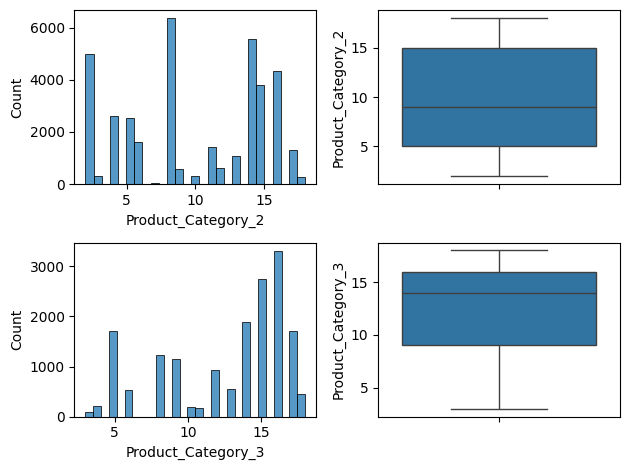

In [518]:
plt.subplot(2,2,1)
sns.histplot(data1.Product_Category_2)
plt.subplot(2,2,2)
sns.boxplot(data1.Product_Category_2)
plt.subplot(2,2,3)
sns.histplot(data1.Product_Category_3)
plt.subplot(2,2,4)
sns.boxplot(data1.Product_Category_3)
plt.tight_layout()
plt.show()

Cột Product_category_3 chứa missing values bao hàm trên Product_category_2

In [519]:
index_duplicated_category_2 = data1[data1.Product_Category_2.isnull()].index
len(index_duplicated_category_2)
index_duplicated_category_3 = data1[data1.Product_Category_3.isnull()].index
len(index_duplicated_category_3)
len(set(index_duplicated_category_2).intersection(set(index_duplicated_category_3)))


17222

In [520]:
data1 = data1.drop(index=index_duplicated_category_3).reset_index(drop=True)

In [521]:
data1.shape

(16898, 12)

In [522]:
data1.drop(columns = ['User_ID', 'Product_ID'], inplace=True)
data1.describe()

,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,16898.000000,16898.000000,16898.000000,16898.000000,16898.000000,16898.000000
mean,8.182921,0.403006,2.764824,6.914487,12.627175,11616.221920
std,6.536895,0.490517,2.591058,4.529032,4.164127,5110.560439
min,0.000000,0.000000,1.000000,2.000000,3.000000,185.000000
25%,2.000000,0.000000,1.000000,2.000000,9.000000,7822.500000
50%,7.000000,0.000000,1.000000,6.000000,14.000000,11724.000000
75%,14.000000,1.000000,5.000000,10.000000,16.000000,15616.000000
max,20.000000,1.000000,15.000000,16.000000,18.000000,23947.000000


### EDA

#### Preprocessing

In [523]:
_analyzer = TTTH_Analyzer()
_processor = FeatureProcessor

Xử lý age bằng cách tính trung bình trên đoạn bin đó

In [524]:
# def process_age(age):
#     if '-' in age:
#         return (int(age.split('-')[0]) + int(age.split('-')[1]))/2 
#     return int(age.split('+')[0])

# def process_age(age):
#     if '-' in age:
#         return (int(age.split('-')[0]) + int(age.split('-')[1]))/2 
#     return int(age.split('+')[0])
# data1.Age = data1.Age.apply(process_age) 
# data1.Stay_In_Current_City_Years.apply(lambda x: float(x))
# data1.Gender.apply(lambda x: 1 if x=='M' else 0)

Visualization for each numerical column distribution

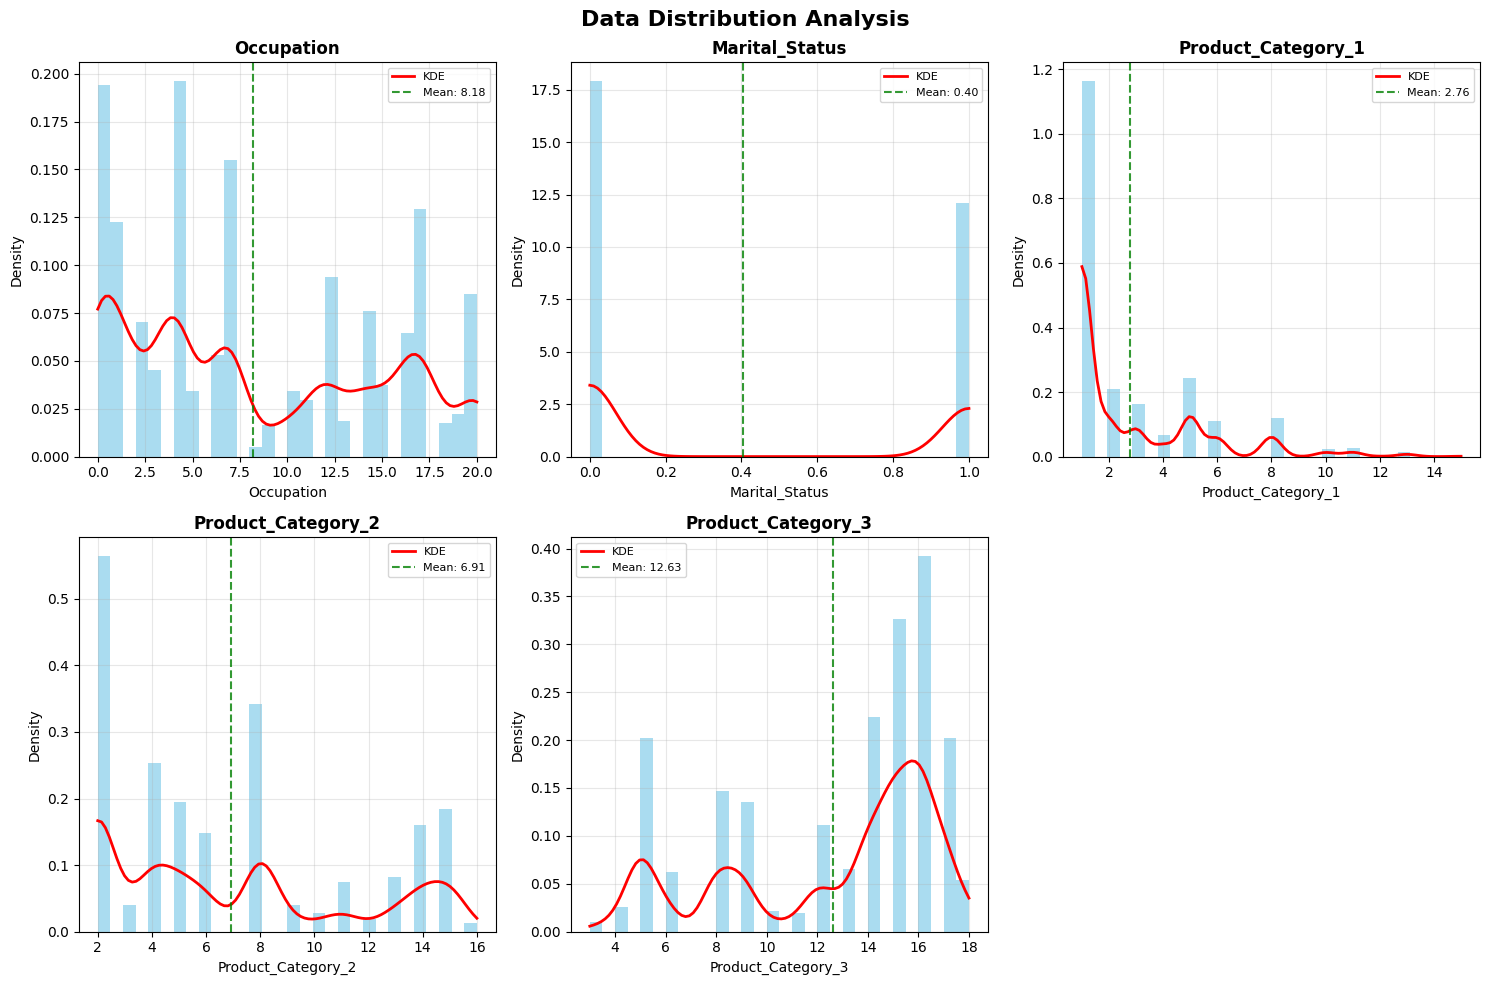

In [525]:
plot_data_distribution(data1, target_col="Purchase")


 Feature Correlation Analysis:
Correlation with Purchase:
Purchase              1.000000
Occupation            0.014824
Product_Category_3   -0.020675
Product_Category_2   -0.152445
Product_Category_1   -0.385600
Name: Purchase, dtype: float64


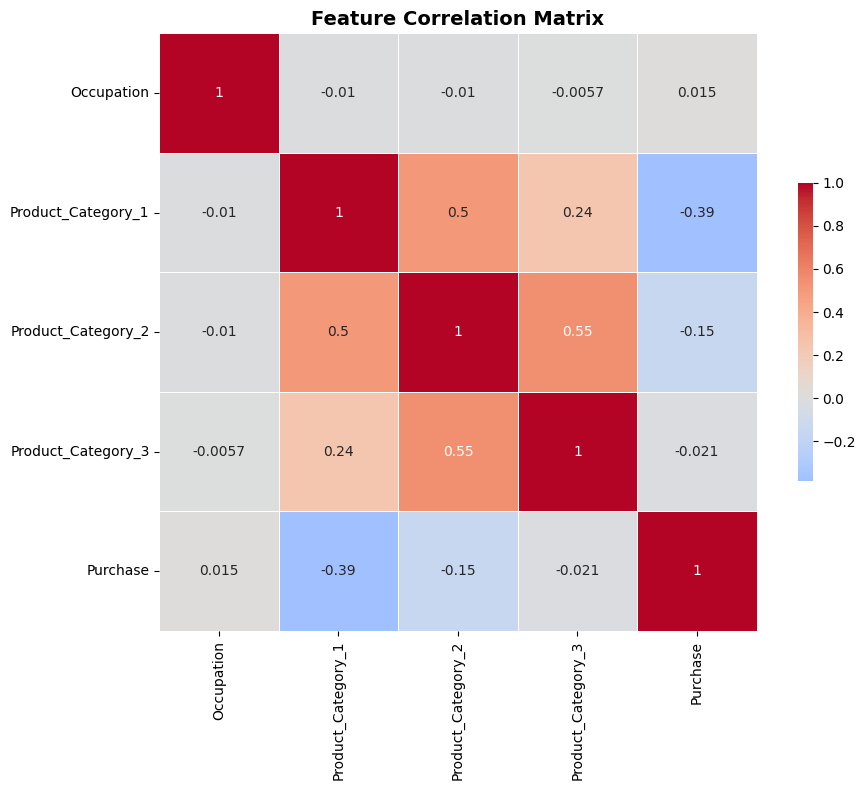

In [ ]:
# Feature correlation analysis
print("\n Feature Correlation Analysis:")
# Calculate correlation matrix
correlation_matrix = data1.loc[:numerical_columns].corr()
print("Correlation with Purchase:")
purchased_corr = correlation_matrix["Purchase"].sort_values(ascending=False)
print(purchased_corr)

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
)
plt.title("Feature Correlation Matrix", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

In [527]:
data1.drop(columns = 'Marital_Status', inplace=True)

In [528]:
numerical_columns = data1.select_dtypes('number').columns
category_columns = data1.select_dtypes('O').columns

In [529]:
numerical_df = data1.loc[:, numerical_columns]
category_df = data1.loc[:, category_columns]

#### Univariate analysis

##### numerical columns

=====
central tendency of Occupation: {'mean': np.float64(8.182921055746242), 'median': 7.0, 'mode': np.int64(4), 'min': 0, 'max': 20, 'range': 20}
=====
Dispersion of Occupation: 
 {'range': 20, 'q1': np.float64(2.0), 'q3': np.float64(14.0), 'iqr': np.float64(12.0), 'var': 42.7309931358653, 'skew': np.float64(0.35497456220252804), 'kurtosis': np.float64(-1.2672770478479065)}
=====


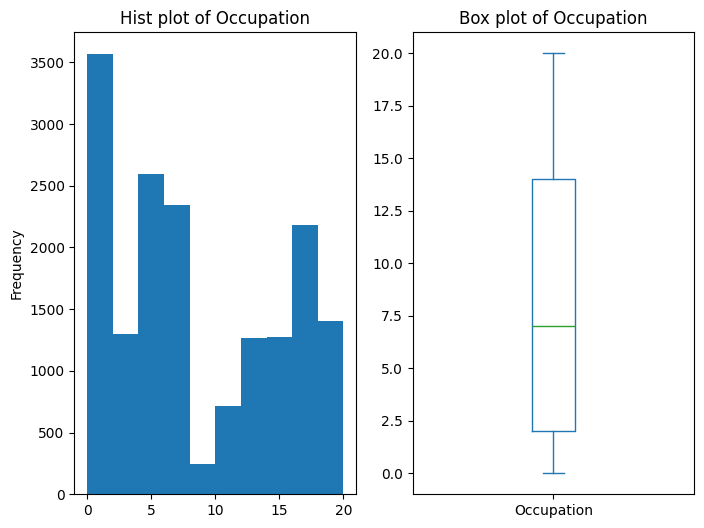

=====
central tendency of Product_Category_1: {'mean': np.float64(2.764824239554977), 'median': 1.0, 'mode': np.int64(1), 'min': 1, 'max': 15, 'range': 14}
=====
Dispersion of Product_Category_1: 
 {'range': 14, 'q1': np.float64(1.0), 'q3': np.float64(5.0), 'iqr': np.float64(4.0), 'var': 6.713582974964382, 'skew': np.float64(1.6196365547049298), 'kurtosis': np.float64(2.2824940034771855)}
=====


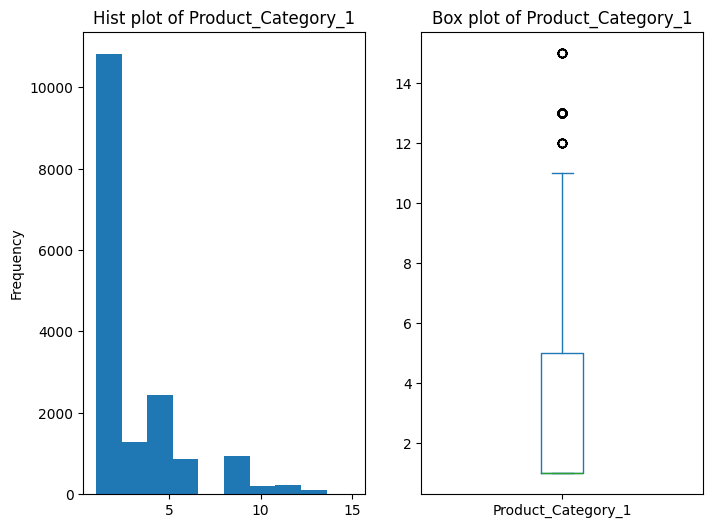

=====
central tendency of Product_Category_2: {'mean': np.float64(6.914486921529175), 'median': 6.0, 'mode': np.float64(2.0), 'min': 2.0, 'max': 16.0, 'range': 14.0}
=====
Dispersion of Product_Category_2: 
 {'range': 14.0, 'q1': np.float64(2.0), 'q3': np.float64(10.0), 'iqr': np.float64(8.0), 'var': 20.512128401586477, 'skew': np.float64(0.5733491614499016), 'kurtosis': np.float64(-1.0203800981179922)}
=====


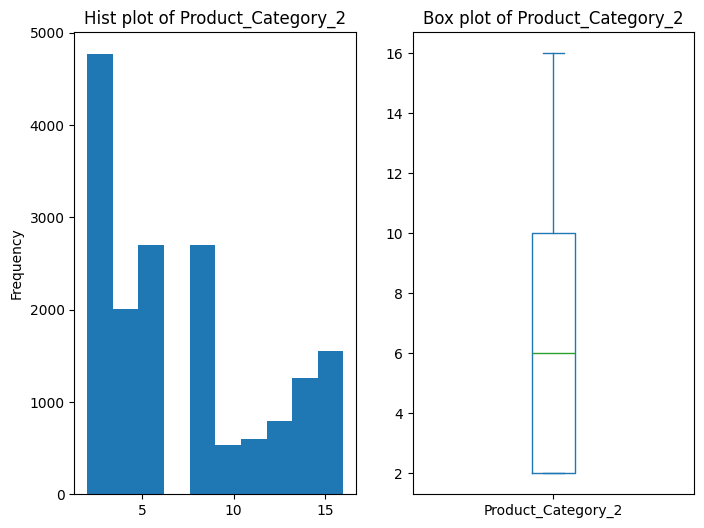

=====
central tendency of Product_Category_3: {'mean': np.float64(12.627174813587407), 'median': 14.0, 'mode': np.float64(16.0), 'min': 3.0, 'max': 18.0, 'range': 15.0}
=====
Dispersion of Product_Category_3: 
 {'range': 15.0, 'q1': np.float64(9.0), 'q3': np.float64(16.0), 'iqr': np.float64(7.0), 'var': 17.33995391641177, 'skew': np.float64(-0.7589655270630576), 'kurtosis': np.float64(-0.828346718661308)}
=====


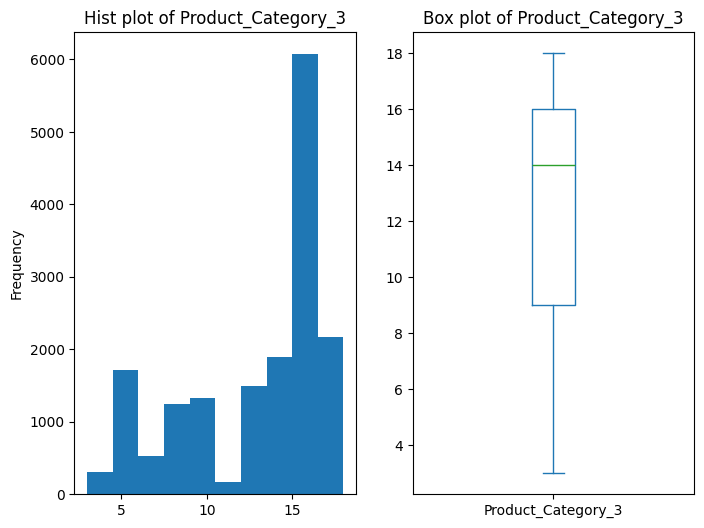

=====
central tendency of Purchase: {'mean': np.float64(11616.221919753818), 'median': 11724.0, 'mode': np.int64(15874), 'min': 185, 'max': 23947, 'range': 23762}
=====
Dispersion of Purchase: 
 {'range': 23762, 'q1': np.float64(7822.5), 'q3': np.float64(15616.0), 'iqr': np.float64(7793.5), 'var': 26117828.003420662, 'skew': np.float64(-0.06310394898820892), 'kurtosis': np.float64(-0.8885186108906864)}
=====


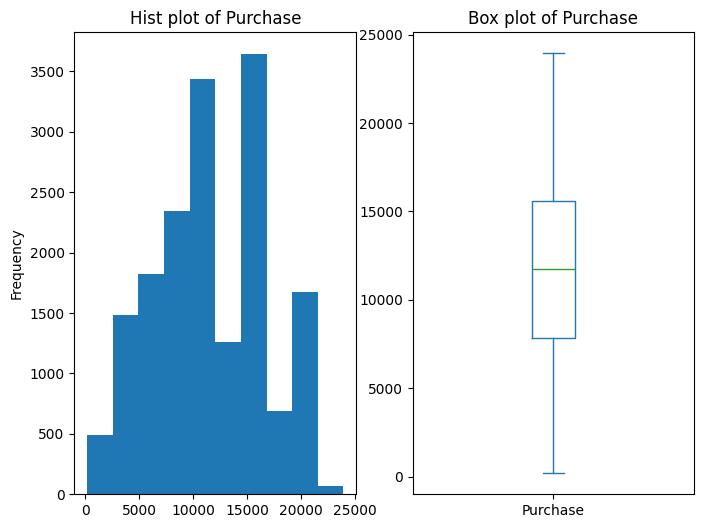

In [530]:
for col in numerical_columns:
    _analyzer.analyze_numeric_variable(col, numerical_df)

Chỉ có Product_category_1 có một vài outlier không đáng kể

##### Category columns

Class count of Gender:

Gender
M    13009
F     3889
Name: count, dtype: int64


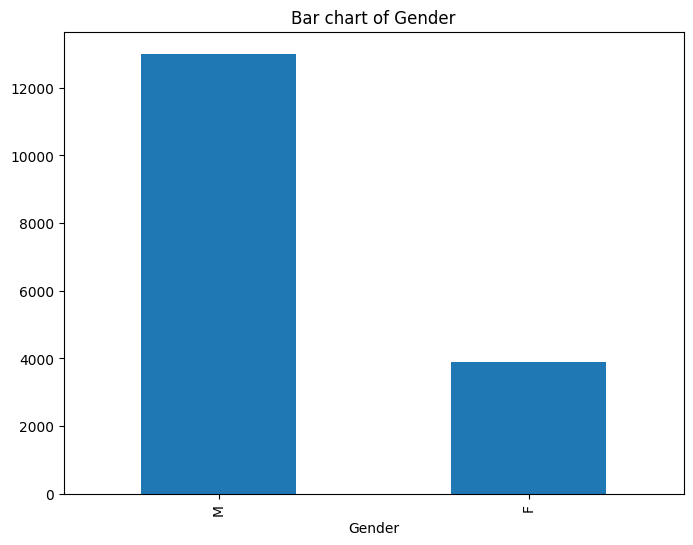

Class count of Age:

Age
26-35    6807
36-45    3368
18-25    3202
46-50    1385
51-55    1131
55+       560
0-17      445
Name: count, dtype: int64


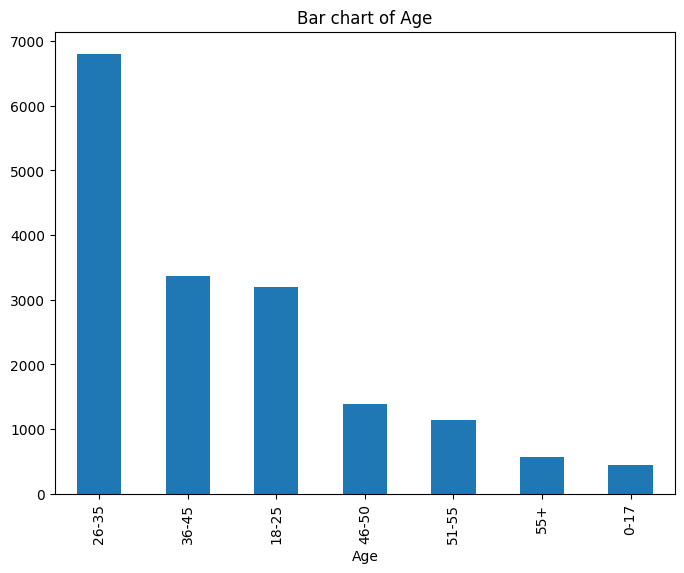

Class count of City_Category:

City_Category
B    7043
C    5703
A    4152
Name: count, dtype: int64


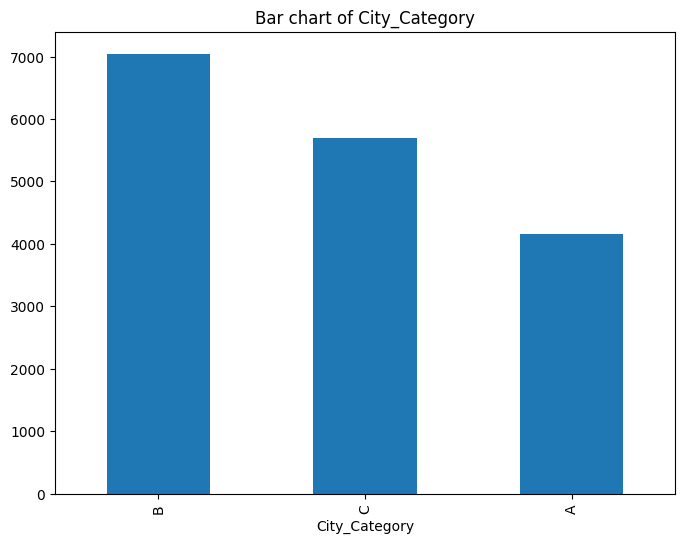

Class count of Stay_In_Current_City_Years:

Stay_In_Current_City_Years
1     5899
2     3194
3     2964
4+    2574
0     2267
Name: count, dtype: int64


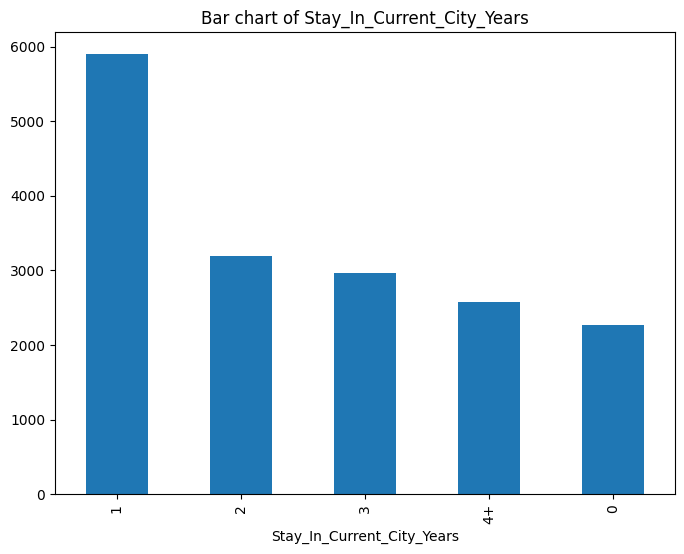

In [531]:
for col in category_columns:
    _analyzer.analyze_category_variable(col, category_df)

#### Bivariate analysis

##### Category vs category

In [532]:
for col in category_columns:
    print("Value counts of {} ".format(col))
    print(category_df[[col]].value_counts())
    print('\n')

Value counts of Gender 
Gender
M         13009
F          3889
Name: count, dtype: int64


Value counts of Age 
Age  
26-35    6807
36-45    3368
18-25    3202
46-50    1385
51-55    1131
55+       560
0-17      445
Name: count, dtype: int64


Value counts of City_Category 
City_Category
B                7043
C                5703
A                4152
Name: count, dtype: int64


Value counts of Stay_In_Current_City_Years 
Stay_In_Current_City_Years
1                             5899
2                             3194
3                             2964
4+                            2574
0                             2267
Name: count, dtype: int64




phân tích đôi một hai biến phân loại xem có độc lập không

In [533]:
category_columns

Index(['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years'], dtype='object')

=====Analyze of Gender and Age=====


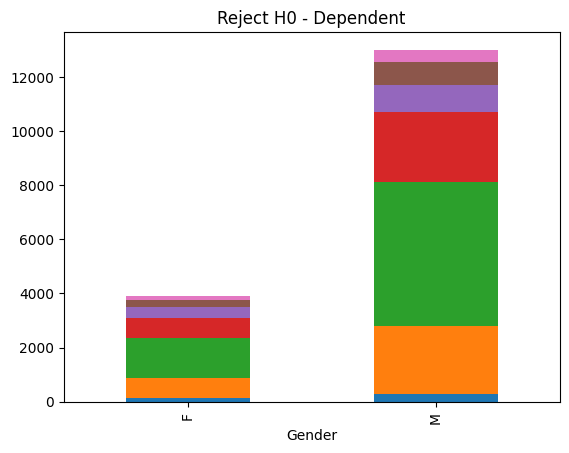

=====Analyze of City_Category and Gender=====


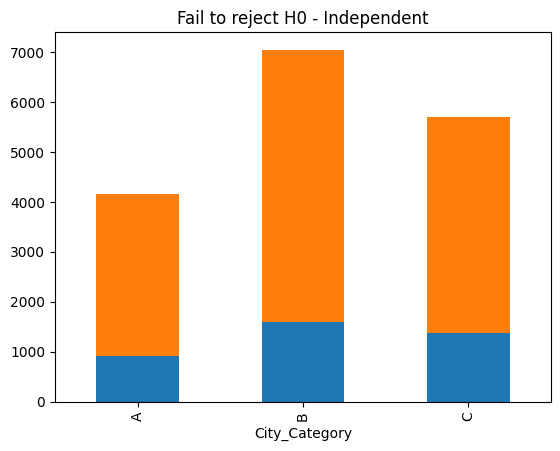

=====Analyze of Gender and Stay_In_Current_City_Years=====


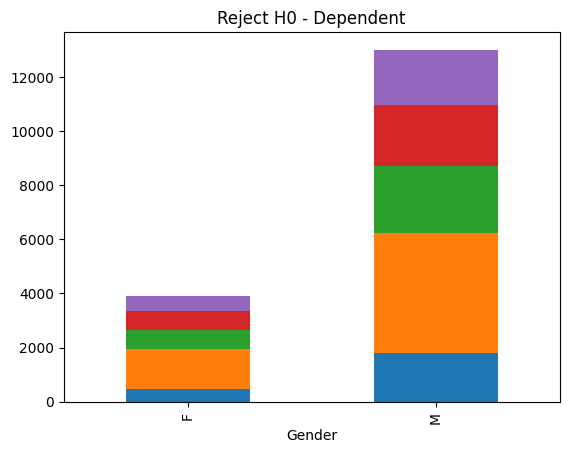

=====Analyze of City_Category and Age=====


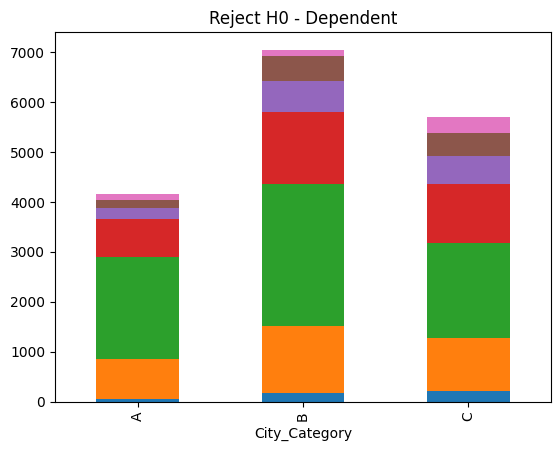

=====Analyze of Stay_In_Current_City_Years and Age=====


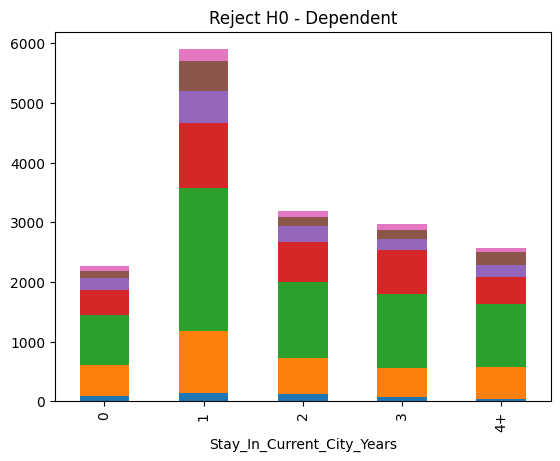

=====Analyze of City_Category and Stay_In_Current_City_Years=====


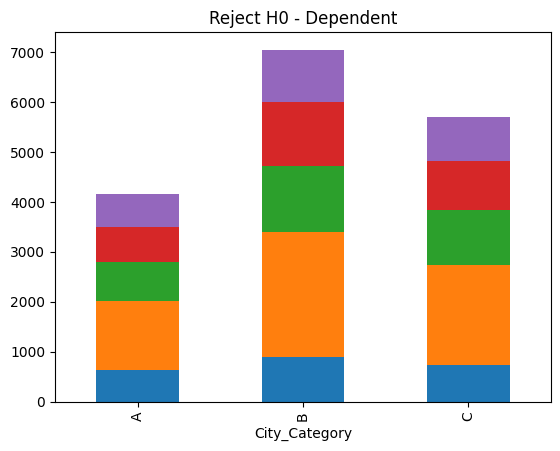

In [534]:
pairs = _analyzer.create_unique_pair_variable(category_columns)
results = []
for pair in pairs:
    pair = list(pair)
    results.append(_analyzer.analyze_category_vs_category(pair[1], pair[0], category_df))

##### Output continuous vs category

In [535]:
output_df = data1[['Purchase']]
temp_df = pd.concat([category_df, output_df], axis = 1)

                 sum_sq       df          F        PR(>F)
C(Gender)  1.401706e+09      1.0  53.836353  2.277900e-13
Residual   4.399112e+11  16896.0        NaN           NaN


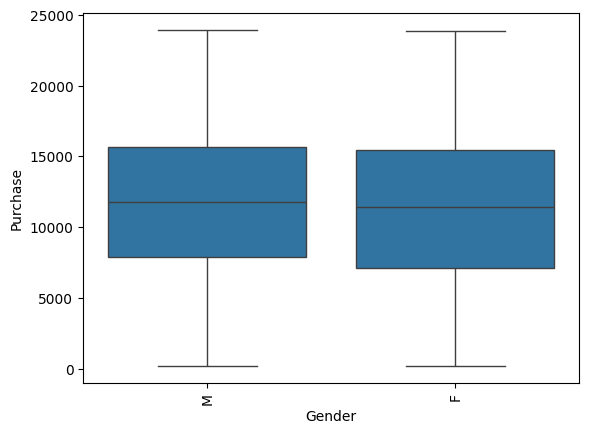

                sum_sq       df         F    PR(>F)
C(Age)    4.591429e+08      6.0  2.931956  0.007358
Residual  4.408538e+11  16891.0       NaN       NaN


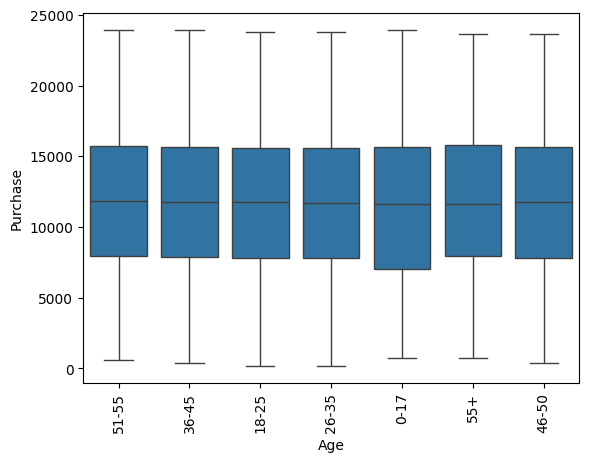

                        sum_sq       df          F        PR(>F)
C(City_Category)  2.960050e+09      2.0  57.043141  2.040552e-25
Residual          4.383529e+11  16895.0        NaN           NaN


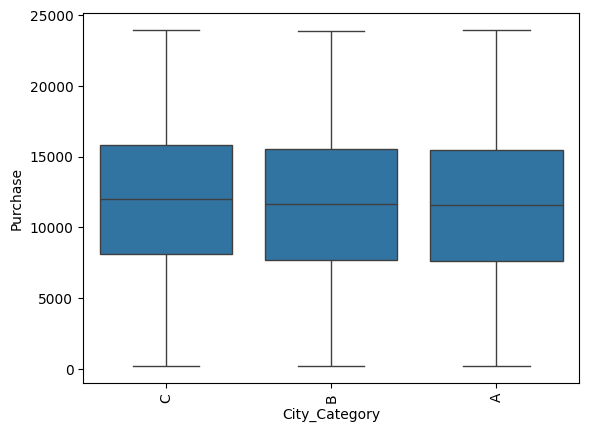

                                     sum_sq       df         F    PR(>F)
C(Stay_In_Current_City_Years)  8.089382e+07      4.0  0.774275  0.541726
Residual                       4.412320e+11  16893.0       NaN       NaN


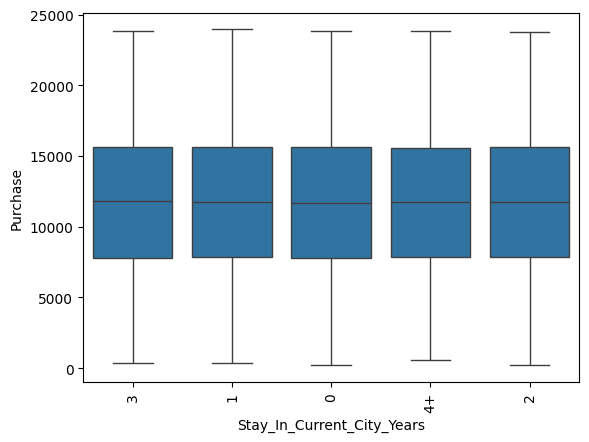

In [536]:
for col in category_columns:
    _analyzer.analyze_anova_table_for_continous_vs_categories('Purchase', col, temp_df)
    sns.boxplot(data=temp_df, x=col, y='Purchase')
    plt.xticks(rotation=90)
    plt.show()


### Data standardization

Không có sự phụ thuộc nhiều giữa các cột phân loại so với biến target Purchase

In [537]:
data1.drop(columns = category_columns, inplace = True)

In [538]:
X = data1.drop(columns='Purchase')
y = data1[['Purchase']]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


In [539]:
X_train.head()

,Occupation,Product_Category_1,Product_Category_2,Product_Category_3
4004,11,1,2.0,8.0
2769,0,5,6.0,11.0
388,16,6,10.0,16.0
1953,20,2,4.0,15.0
7475,3,1,6.0,8.0


Vì không có nhiều outlier do bước EDA nên dùng standard scaler

In [540]:

scaler = SklearnTransformerWrapper(StandardScaler(), variables=list(X.columns))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [541]:
X_train_scaled.head()

,Occupation,Product_Category_1,Product_Category_2,Product_Category_3
4004,0.431018,-0.684264,-1.087285,-1.114192
2769,-1.249234,0.843128,-0.204487,-0.393964
388,1.194769,1.224975,0.678310,0.806416
1953,1.805770,-0.302416,-0.645886,0.566340
7475,-0.790984,-0.684264,-0.204487,-1.114192


### Build model with remove category columns base on EDA step

In [542]:
regression_models = [
    ('LinearRegression', LinearRegression()),
    ('SVR', SVR()),
    ('KNeighborsRegressor', KNeighborsRegressor()),
    ('DecisionTreeRegressor', DecisionTreeRegressor()),
    ('RandomForestRegressor', RandomForestRegressor())
]

print(f"Models to compare: {[name for name, _ in regression_models]}")

Models to compare: ['LinearRegression', 'SVR', 'KNeighborsRegressor', 'DecisionTreeRegressor', 'RandomForestRegressor']


In [543]:
results = []
for name, model in regression_models:
    print(f"\n Evaluating {name}...")

    start = time.time()

    cross_score_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cross_score_mse = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_root_mean_squared_error')

    end = time.time()

    results.append({
        "model": name,
        "r2_mean": cross_score_r2.mean(),
        "r2_std": cross_score_r2.std(),
        "mse_mean" : cross_score_mse.mean(),
        "mse_std" : cross_score_mse.std(),
        "training_time": end - start
    })


    print(f"   R² Score: {cross_score_r2.mean():.4f} (±{cross_score_r2.std():.4f})")
    print(f"   negative Mse: {cross_score_mse.mean():.4f} (±{cross_score_mse.std():.4f})")
    print(f"   Training Time: {end - start:.2f} seconds")


 Evaluating LinearRegression...
   R² Score: 0.1562 (±0.0085)
   negative Mse: -4700.0376 (±52.1928)
   Training Time: 0.10 seconds

 Evaluating SVR...
   R² Score: 0.0478 (±0.0018)
   negative Mse: -4992.8260 (±43.3844)
   Training Time: 93.45 seconds

 Evaluating KNeighborsRegressor...
   R² Score: 0.4075 (±0.0159)
   negative Mse: -3938.0435 (±60.7930)
   Training Time: 0.46 seconds

 Evaluating DecisionTreeRegressor...
   R² Score: 0.4206 (±0.0156)
   negative Mse: -3894.2820 (±64.3675)
   Training Time: 0.26 seconds

 Evaluating RandomForestRegressor...
   R² Score: 0.4496 (±0.0114)
   negative Mse: -3794.3691 (±49.6124)
   Training Time: 14.89 seconds


In [544]:
results_df = pd.DataFrame(results)
print("\n Model Comparison Results:")

print(results_df.sort_values(by='r2_mean', ascending=False))


 Model Comparison Results:
                   model   r2_mean    r2_std     mse_mean    mse_std  \
4  RandomForestRegressor  0.449639  0.011426 -3794.369126  49.612392   
3  DecisionTreeRegressor  0.420636  0.015601 -3894.282021  64.367482   
2    KNeighborsRegressor  0.407532  0.015873 -3938.043499  60.792966   
0       LinearRegression  0.156229  0.008504 -4700.037632  52.192829   
1                    SVR  0.047830  0.001770 -4992.826042  43.384427   

   training_time  
4      14.890013  
3       0.262572  
2       0.458661  
0       0.104514  
1      93.451040  



Visualizing model comparison


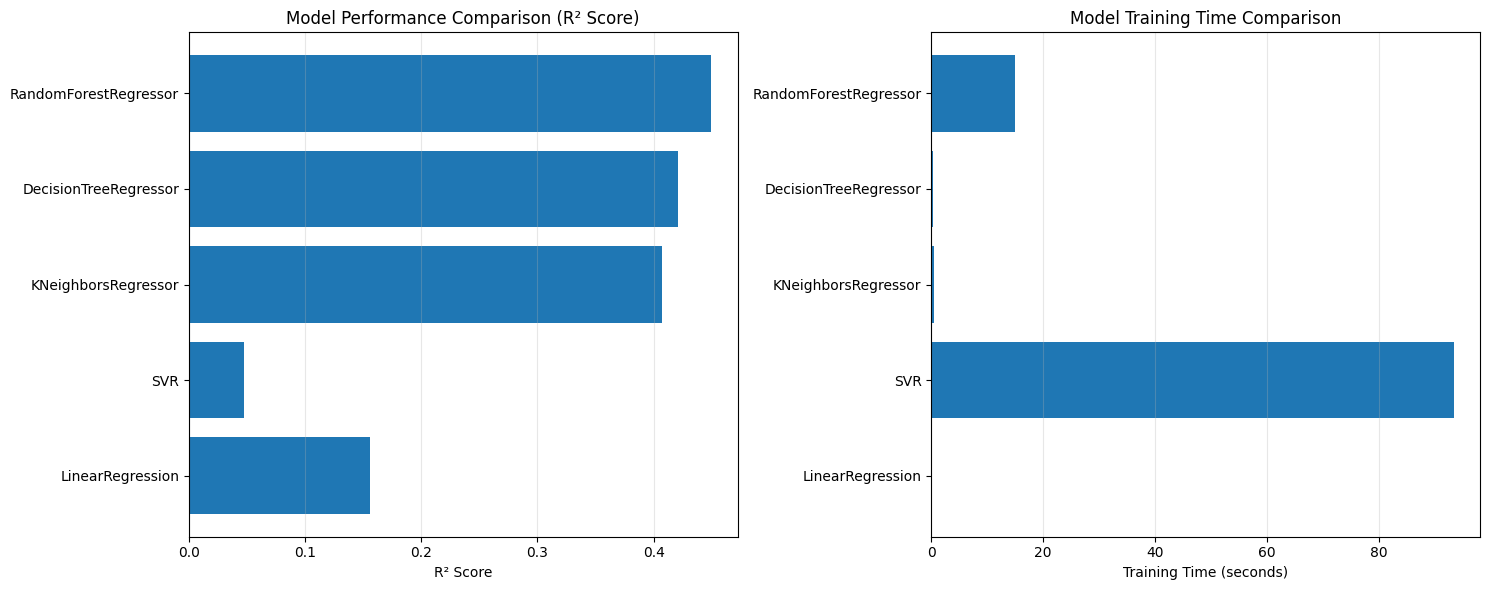

In [545]:
print("\nVisualizing model comparison")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.barh(results_df["model"], results_df["r2_mean"])
ax1.set_xlabel("R² Score")
ax1.set_title("Model Performance Comparison (R² Score)")
ax1.grid(axis="x", alpha=0.3)

ax2.barh(results_df["model"], results_df["training_time"])
ax2.set_xlabel("Training Time (seconds)")
ax2.set_title("Model Training Time Comparison")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Rebuild model base tree without remove any columns

Dựa trên model performance thì thuật toán về Tree có training time, rmse và r2 tốt nhất do đặc điểm dữ liệu các features có đặc tính là biến phân loại, phù hợp với việc xây dựng các threshold và K nearest neighbors

In [566]:
data2= pd.read_csv('Data/black_friday.csv')
data2.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [567]:
index_duplicated_category_3 = data2[data2.Product_Category_3.isnull()].index
data2 = data2.drop(index=index_duplicated_category_3).reset_index(drop=True)


Bỏ cột không liên quan

In [568]:
data2.drop(columns = ['User_ID', 'Product_ID'], inplace=True)


Xử lý dữ liệu object/category

In [569]:
def process_age(age):
    if '-' in age:
        return (int(age.split('-')[0]) + int(age.split('-')[1]))/2 
    return int(age.split('+')[0])

def process_stay_in_current_year(year):
    if '+' in year:
        return float(year.split('+')[0])
    return float(year)

data2.Age = data2.Age.apply(process_age) 
data2.Stay_In_Current_City_Years = data2.Stay_In_Current_City_Years.apply(process_stay_in_current_year)
data2.Gender = data2.Gender.apply(lambda x: 1 if x=='M' else 0)
data2.City_Category = data2.City_Category.apply(lambda x: 0 if x=='A' else 1 if x=='B' else 2)

Chia dữ liệu thành các tập

In [570]:
X = data2.drop(columns='Purchase')
y = data2[['Purchase']]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=3, test_size=0.2)


Sử dụng thêm grid cv search tìm hyperparameters

In [571]:
param_grid_decision_tree = {
    'criterion' : ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth' : np.arange(1, 10),
    'max_features' : ['sqrt', 'log2'],
    'ccp_alpha' : [0.1, 0.01, 0.001]
}


param_grid_random_forest = {
    'n_estimators' : [5, 10, 15, 20, 25, 30, 35, 40],
    'max_depth' : np.arange(1, 10),
    'min_samples_split' : [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features' : ['sqrt', 'log2']
}


best_models = [
    ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=42), param_grid_decision_tree),
    ('RandomForestRegressor', RandomForestRegressor(random_state=42), param_grid_random_forest)
]




In [572]:
results = []
for name, model, params in best_models:
    grid_cv_model = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
    grid_cv_model.fit(X_train, y_train)
    results.append({
        'model' : name,
        'best_param': grid_cv_model.best_params_,
        'r2_score_best' : grid_cv_model.best_score_
    })

Fitting 5 folds for each of 162 candidates, totalling 810 fits


Fitting 5 folds for each of 576 candidates, totalling 2880 fits


In [579]:
df_result = pd.DataFrame(results)
df_result

,model,best_param,r2_score_best
0,DecisionTreeRegressor,"{'ccp_alpha': 0.1, 'criterion': 'squared_error...",0.471835
1,RandomForestRegressor,"{'max_depth': 9, 'max_features': 'sqrt', 'min_...",0.483307


With decision tree

In [588]:
decision_tree = DecisionTreeRegressor(**df_result['best_param'][0])
decision_tree.fit(X_train, y_train)


y_pred_test = decision_tree.predict(X_test)
y_pred_train = decision_tree.predict(X_train)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f'r2_test: {r2_test}')
print(f'r2_train: {r2_train}')
print(f'mse_train: {mse_train}')
print(f'mse_test: {mse_test}')

r2_test: 0.4089196840853777
r2_train: 0.41079651842057885
mse_train: 15221190.880889324
mse_test: 15257218.579879155


Nhận xét: performance tổng thể tốt nhất so với các model, không bị overfit

In [607]:
coef = decision_tree.feature_importances_.reshape(9 ,1)
features = decision_tree.feature_names_in_.reshape(9 ,1)
temp = np.concat([features, coef], axis = 1)

In [624]:
df_tmp = pd.DataFrame(temp, columns = ['features', 'coef'])
df_tmp

,features,coef
0,Gender,0.003619
1,Age,0.005767
2,Occupation,0.004231
3,City_Category,0.015689
4,Stay_In_Current_City_Years,0.00209
5,Marital_Status,0.001196
6,Product_Category_1,0.680585
7,Product_Category_2,0.176857
8,Product_Category_3,0.109966


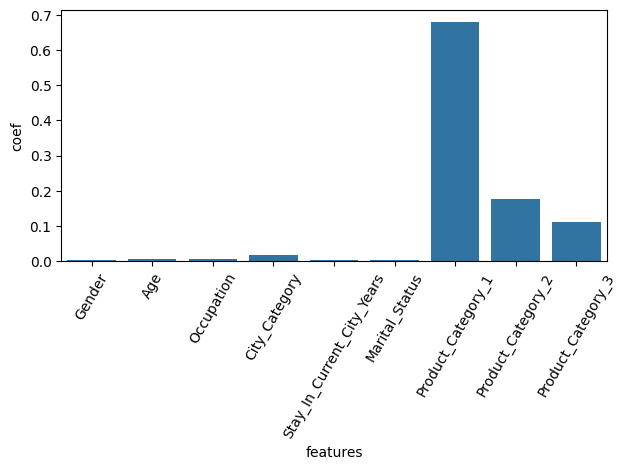

In [626]:
sns.barplot(df_tmp, x='features', y='coef')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

With randomForest

In [589]:
random_forest = RandomForestRegressor(**df_result['best_param'][1])
random_forest.fit(X_train, y_train)


y_pred_test = random_forest.predict(X_test)
y_pred_train = random_forest.predict(X_train)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f'r2_test: {r2_test}')
print(f'r2_train: {r2_train}')
print(f'mse_train: {mse_train}')
print(f'mse_test: {mse_test}')

r2_test: 0.4781148449756545
r2_train: 0.4794017815051105
mse_train: 13448876.498014234
mse_test: 13471123.414894247


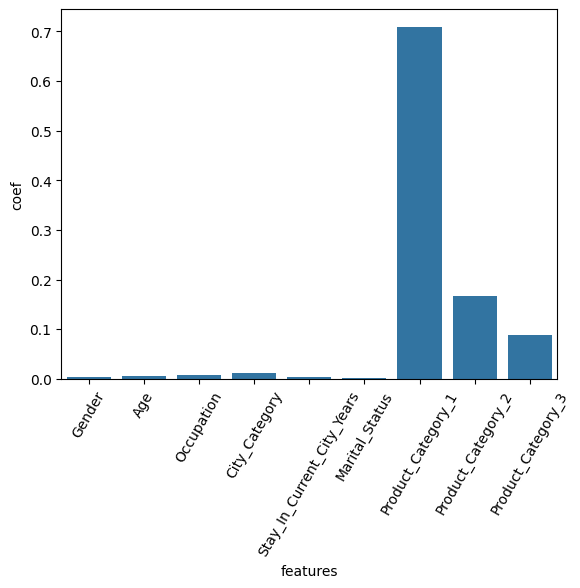

In [635]:
df_temp = pd.DataFrame({
    'features' : random_forest.feature_names_in_,
    'coef': random_forest.feature_importances_
})
sns.barplot(df_temp, x='features', y='coef')
plt.xticks(rotation=60)
plt.show()

With KNN

In [637]:
scaler = SklearnTransformerWrapper(StandardScaler(), variables=list(X_train.columns))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [638]:
KNN = KNeighborsRegressor()
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
    "p": [1, 2]  # chỉ khi metric="minkowski"
}

grid_cv_knn = GridSearchCV(KNN, param_grid, scoring = 'r2', cv=5, n_jobs=-1, verbose=1)
grid_cv_knn.fit(X_train_scaled, y_train)

print(f'best params : {grid_cv_knn.best_params_}')
print(f'best r2 score : {grid_cv_knn.best_score_}')
results.append({
    'model': 'KNeighborsRegressor',
    'best_param': grid_cv_knn.best_params_,
    'r2_score_best': grid_cv_knn.best_score_
})

Fitting 5 folds for each of 56 candidates, totalling 280 fits
best params : {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
best r2 score : 0.40364814914801156


In [640]:
best_param_knn = {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
KNN = KNeighborsRegressor(**best_param_knn)
KNN.fit(X_train_scaled, y_train)

y_pred_test = KNN.predict(X_test_scaled)
y_pred_train = KNN.predict(X_train_scaled)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f'r2_test: {r2_test}')
print(f'r2_train: {r2_train}')
print(f'mse_train: {mse_train}')
print(f'mse_test: {mse_test}')


r2_test: 0.41995913675598595
r2_train: 0.48758972294686187
mse_train: 13237353.274708835
mse_test: 14972263.493636645


In [641]:
table = pd.DataFrame(results)
print('Final of best models performance')
table.sort_values(by='r2_score_best', ascending=False)

Final of best models performance


,model,best_param,r2_score_best
1,RandomForestRegressor,"{'max_depth': 9, 'max_features': 'sqrt', 'min_...",0.483307
0,DecisionTreeRegressor,"{'ccp_alpha': 0.1, 'criterion': 'squared_error...",0.471835
2,KNeighborsRegressor,"{'metric': 'manhattan', 'n_neighbors': 15, 'p'...",0.403648


### AdaBoosting

Xây dựng ada boost dựa trên best model trên accuracy và trainning time là decision tree ở trên

In [646]:
base_estimator = DecisionTreeRegressor(max_depth=3)
ada_model = AdaBoostRegressor(estimator=base_estimator, random_state=42)
ada_model.fit(X_train, y_train)

print(f'number of estimators: {ada_model.n_estimators}')
print(f'learning rate: {ada_model.learning_rate}')
print(f'Base estimator: {ada_model.estimator}')

y_pred_test = ada_model.predict(X_test)
y_pred_train = ada_model.predict(X_train)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_test, y_pred_test) 
mape_train = mean_absolute_percentage_error(y_train, y_pred_train) 

number of estimators: 50
learning rate: 1.0
Base estimator: DecisionTreeRegressor(max_depth=3)


In [650]:
print('='*50)
print('Evaluating AdaBoost Regressor')
print('='*50)
print('Training Performance:')
print(f'R² Score: {r2_train} \n MSE: {mse_train} \n MAPE: {mape_train}%')
print('Testing Performance:')
print(f'R² Score: {r2_test} \n MSE: {mse_test} \n MAPE: {mape_test}%')
print(f'Top 3 Most Important Features: {ada_model.feature_names_in_[-3:]}')


Evaluating AdaBoost Regressor
Training Performance:
R² Score: 0.39806213159580006 
 MSE: 15550164.722135901 
 MAPE: 0.4021177970951759%
Testing Performance:
R² Score: 0.40137012584985554 
 MSE: 15452091.01443596 
 MAPE: 0.3997223172378726%
Top 3 Most Important Features: ['Product_Category_1' 'Product_Category_2' 'Product_Category_3']


### Conclusion

#### Decision tree bring the best performance with r2_score, mse and training time, which is the best case for bussiness insights 

## 2. Clustering

**Cho dữ liệu book_summary.csv**, chứa tóm tắt của nhiều quyển sách thuộc nhiều thể loại khác nhau, lấy từ: https://www.kaggle.com/datasets/athu1105/book-genre-prediction

**Đọc tất cả dữ liệu vào dataframe books theo định dạng sau:**

| index | title | genre | summary |
|-------|-------|-------|---------|
|       |       |       |         |


In [154]:
# Câu 2: Clustering - Phân cụm dữ liệu sách

# TODO: Thực hiện các bước sau:
# 1. Đọc dữ liệu
# 2. Tiền xử lý text data
# 3. Chuyển đổi text thành vector (TF-IDF)
# 4. Lựa chọn thuật toán clustering phù hợp
# 5. Áp dụng clustering
# 6. Đánh giá kết quả clustering
# 7. Tạo WordCloud cho từng cụm
# 8. So sánh với genre có sẵn

### NOTE Phần clustering có sử dụng và điều chỉnh lại một số hàm visualization từ các demo trong lớp học


### Library import

In [1]:
from utils.clustering_utils import cluster_summary_report
from utils.visualization_utils import plot_cluster_comparison
from utils.vectorization_utils import plot_dimensionality_reduction_analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Import our custom utils
from utils import (
    # Text preprocessing
    load_bbc_dataset,
    comprehensive_text_clean,
    analyze_text_statistics,
    compare_preprocessing_steps,
    plot_preprocessing_comparison,

    # Vectorization
    create_tfidf_features,
    analyze_feature_importance,
    plot_tfidf_analysis,
    apply_dimensionality_reduction,

    # Clustering
    perform_clustering_analysis,
    find_optimal_clusters,
    compare_clustering_methods,
    evaluate_clustering_performance,

    # Visualization
    plot_beautiful_clusters,
    create_cluster_dashboard,
    plot_silhouette_analysis,
    plot_silhouette_analysis_multiple_k,

    # Evaluation
    calculate_clustering_metrics,
    create_evaluation_report,
    plot_evaluation_metrics
)

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

### Read and overview

In [8]:
book_data = pd.read_csv('Data/book_summary.csv')
book_data.drop(columns='index', inplace=True)
book_data.head()

,title,genre,summary
0,Drowned Wednesday,fantasy,Drowned Wednesday is the first Trustee among ...
1,The Lost Hero,fantasy,"As the book opens, Jason awakens on a school ..."
2,The Eyes of the Overworld,fantasy,Cugel is easily persuaded by the merchant Fia...
3,Magic's Promise,fantasy,The book opens with Herald-Mage Vanyel return...
4,Taran Wanderer,fantasy,Taran and Gurgi have returned to Caer Dallben...


In [9]:
book_data.shape

(4657, 3)

In [10]:
book_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4657 entries, 0 to 4656
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    4657 non-null   object
 1   genre    4657 non-null   object
 2   summary  4657 non-null   object
dtypes: object(3)
memory usage: 109.3+ KB


In [11]:
print("\n Sample summary from each book genre:")
print("=" * 50)

for category in book_data['genre'].unique():
    category_articles = book_data[book_data['genre'] == category]
    sample_article = category_articles.iloc[0]['summary']

    print(f"\n {category.upper()} Sample:")
    print(f"   Length: {len(sample_article)} characters")
    print(f"   Preview: {sample_article[:200]}")


 Sample summary from each book genre:

 FANTASY Sample:
   Length: 4704 characters
   Preview:  Drowned Wednesday is the first Trustee among the Morrow Days who is on Arthur's side and wishes the Will to be fulfilled. She appears as a leviathan/whale and suffers from Gluttony. The book begins w

 SCIENCE Sample:
   Length: 1973 characters
   Preview:  Protagonist Arthur ("Art") Mumby and his older sister Myrtle are invited to the Starcross hotel on a small and periodically barren asteroid. There, Arthur’s mother Emily suspects that Starcross is bu

 CRIME Sample:
   Length: 483 characters
   Preview:  The novel's central character is Joe Cashin, a Melbourne homicide detective. Following serious physical injuries he is posted to his hometown where he begins the process of rebuilding the old family 

 HISTORY Sample:
   Length: 159 characters
   Preview:  Sir John and Jeremy are sent to East Anglia to investigate smuggling, but when the smugglers turn to murder, Sir John takes it as a b


Class distribution analysis:
genre
thriller      1023
fantasy        876
science        647
history        600
horror         600
crime          500
romance        111
psychology     100
sports         100
travel         100
Name: count, dtype: int64


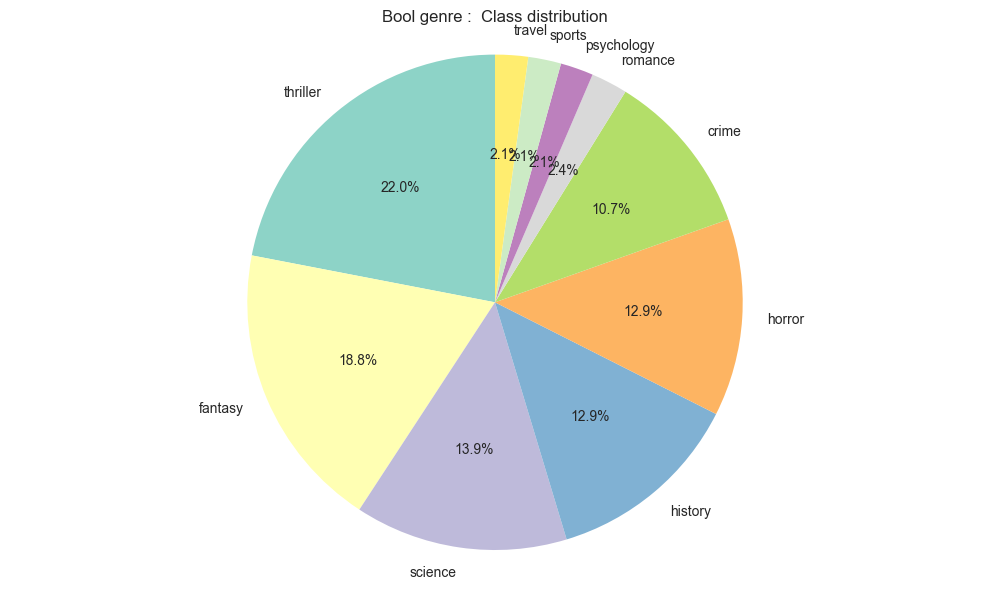

In [12]:
print("\nClass distribution analysis:")
class_counts = book_data['genre'].value_counts()
print(class_counts)

plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
wedges, texts, autotexts = plt.pie(class_counts.values, labels=class_counts.index,
                                   autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Bool genre :  Class distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Text preprocessing pipeline

In [13]:
book_data_cleaned = comprehensive_text_clean(book_data, column='summary', verbose=True)

print(f"\n Genres after cleaning: {book_data['genre'].unique()}")
print(f"Articles per category after cleaning:")
print(book_data_cleaned['genre'].value_counts())


Comprehensive Text Cleaning Pipeline
Step 1: Removing HTTP links...
Step 2: Normalizing line endings...
Step 3: Removing numbers...
Step 4: Removing punctuation...
Step 5: Normalizing whitespace...
Step 6: Converting to lowercase...
Step 7: Removing empty documents...
Step 8: Removing stopwords...
Step 9: Lemmatizing words...

Text cleaning completed!
   Documents processed: 4657
   Documents remaining: 4653
   Documents removed: 4
   Retention rate: 99.9%

 Genres after cleaning: ['fantasy' 'science' 'crime' 'history' 'horror' 'thriller' 'psychology'
 'romance' 'sports' 'travel']
Articles per category after cleaning:
genre
thriller      1023
fantasy        874
science        647
history        599
horror         599
crime          500
romance        111
psychology     100
sports         100
travel         100
Name: count, dtype: int64


In [14]:
print("\nText statistics analysis:")

print("Original text statistics:")
original_stats = analyze_text_statistics(book_data, column='summary',
                                         class_column='genre', verbose=True)

print("\n Cleaned text statistics:")
cleaned_stats = analyze_text_statistics(book_data_cleaned, column='summary',
                                        class_column='genre', verbose=True)


Text statistics analysis:
Original text statistics:

Text Statistics Analysis
Basic Statistics:
   Total documents: 4657
   Average words per document: 359.1
   Average characters per document: 2106.3
   Average sentences per document: 17.1
   Word count range: 1 - 5663

Statistics by Class:
           word_count                   char_count          sentence_count  \
                 mean     std min   max       mean      std           mean   
genre                                                                        
crime          368.18  492.81   6  5474    2148.32  2818.23          17.35   
fantasy        384.85  451.15   1  3085    2229.68  2602.20          18.91   
history        472.93  555.06   1  5088    2783.00  3197.25          21.42   
horror         429.02  489.24   1  5663    2488.36  2797.00          20.75   
psychology     175.33   87.09  33   485    1085.75   520.40           7.62   
romance        168.83   53.14  56   307     989.97   307.29          10.53   
scie

In [15]:
import re
def remove_s(text):
    text =  re.sub(r'\bs\b', ' ', text)
    text =  re.sub(r'\s+', ' ', text).strip()
    return text
book_data_cleaned.summary = book_data_cleaned.summary.apply(remove_s)


Creating Preprocessing Comparison Plots


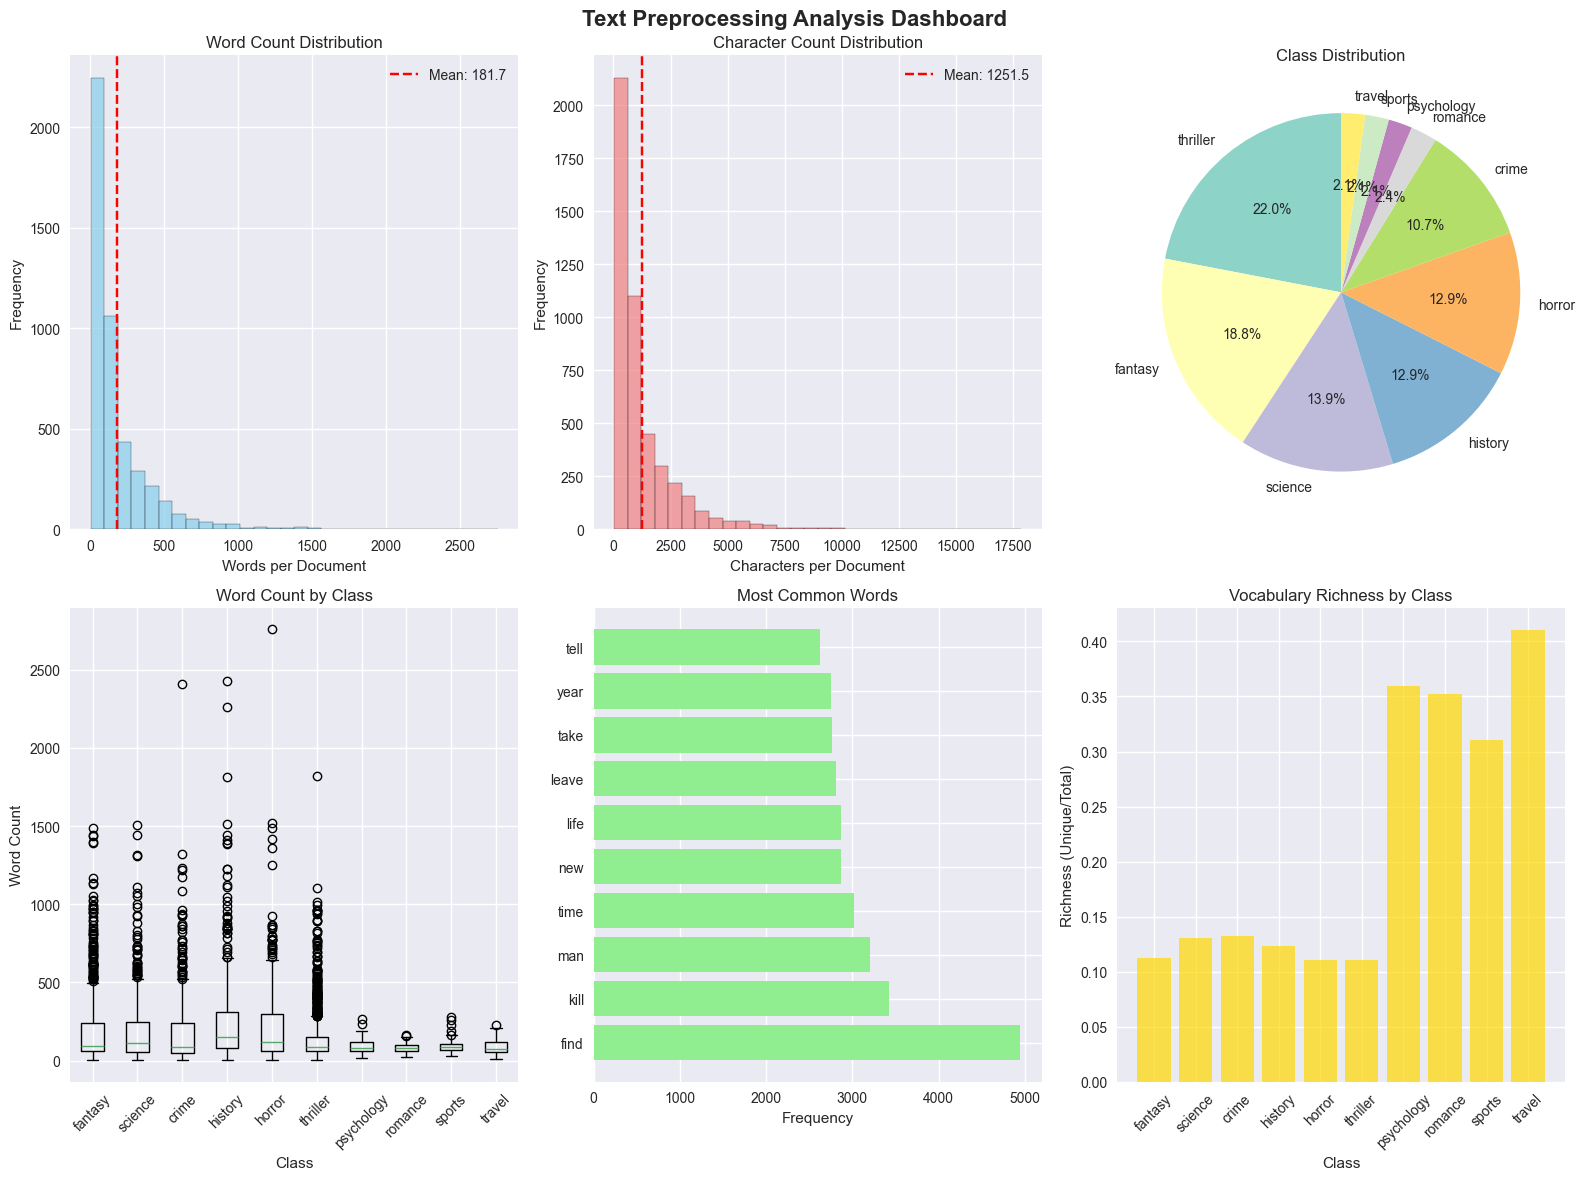


Generating Word Cloud...


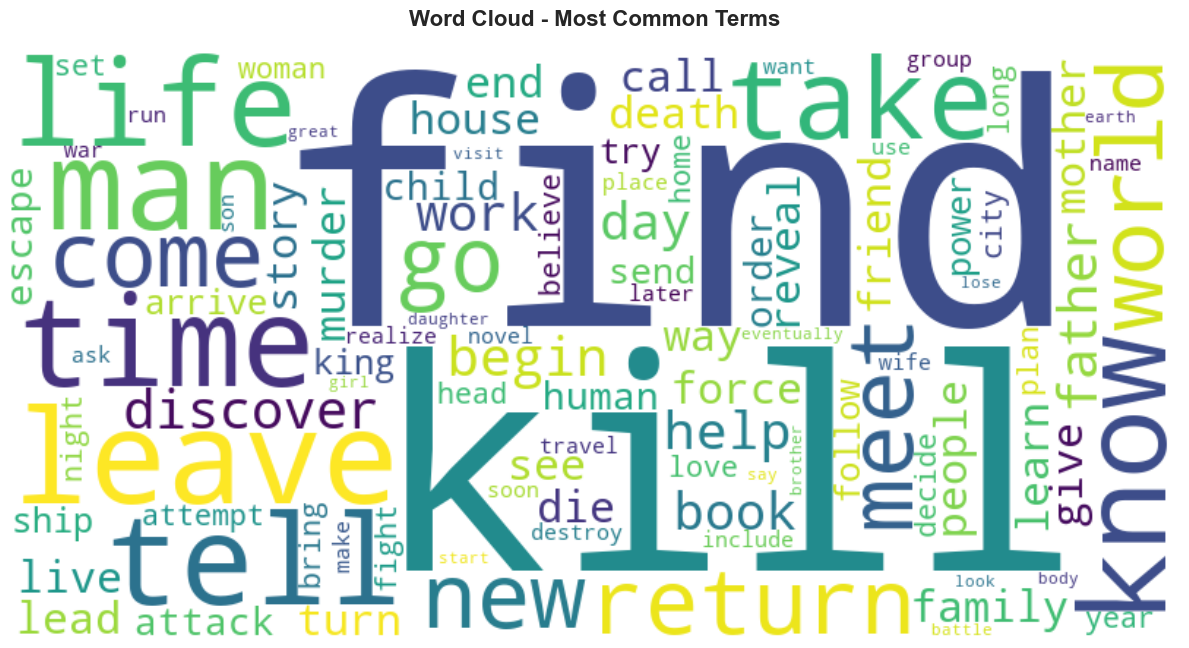

Preprocessing comparison plots completed!


In [16]:
plot_preprocessing_comparison(book_data_cleaned, column='summary', class_column='genre')

### TF-IDF Vectorization and feature analysis

Creating TF-IDF Features
TF-IDF Parameters:
   Max features: 1000
   N-gram range: (1, 2)
   Min document frequency: 0.02
   Max document frequency: 0.95

TF-IDF Features Created:
   Documents: 4653
   Features: 1000
   Sparsity: 0.937
Analyzing Feature Importance (mean method)
Top 20 Most important features:
      feature  importance
496      life    0.030159
575       new    0.029544
985     world    0.029285
526       man    0.029144
991      year    0.028591
897      time    0.026753
839     story    0.026500
468      kill    0.026420
93       book    0.025670
584     novel    0.025072
474      know    0.024373
562    murder    0.023485
490     leave    0.021717
78      begin    0.021521
309    family    0.021223
595       old    0.021200
158      come    0.021070
881      tell    0.020321
349    friend    0.020143
241  discover    0.020139
Creating TF-IDF Analysis Plots


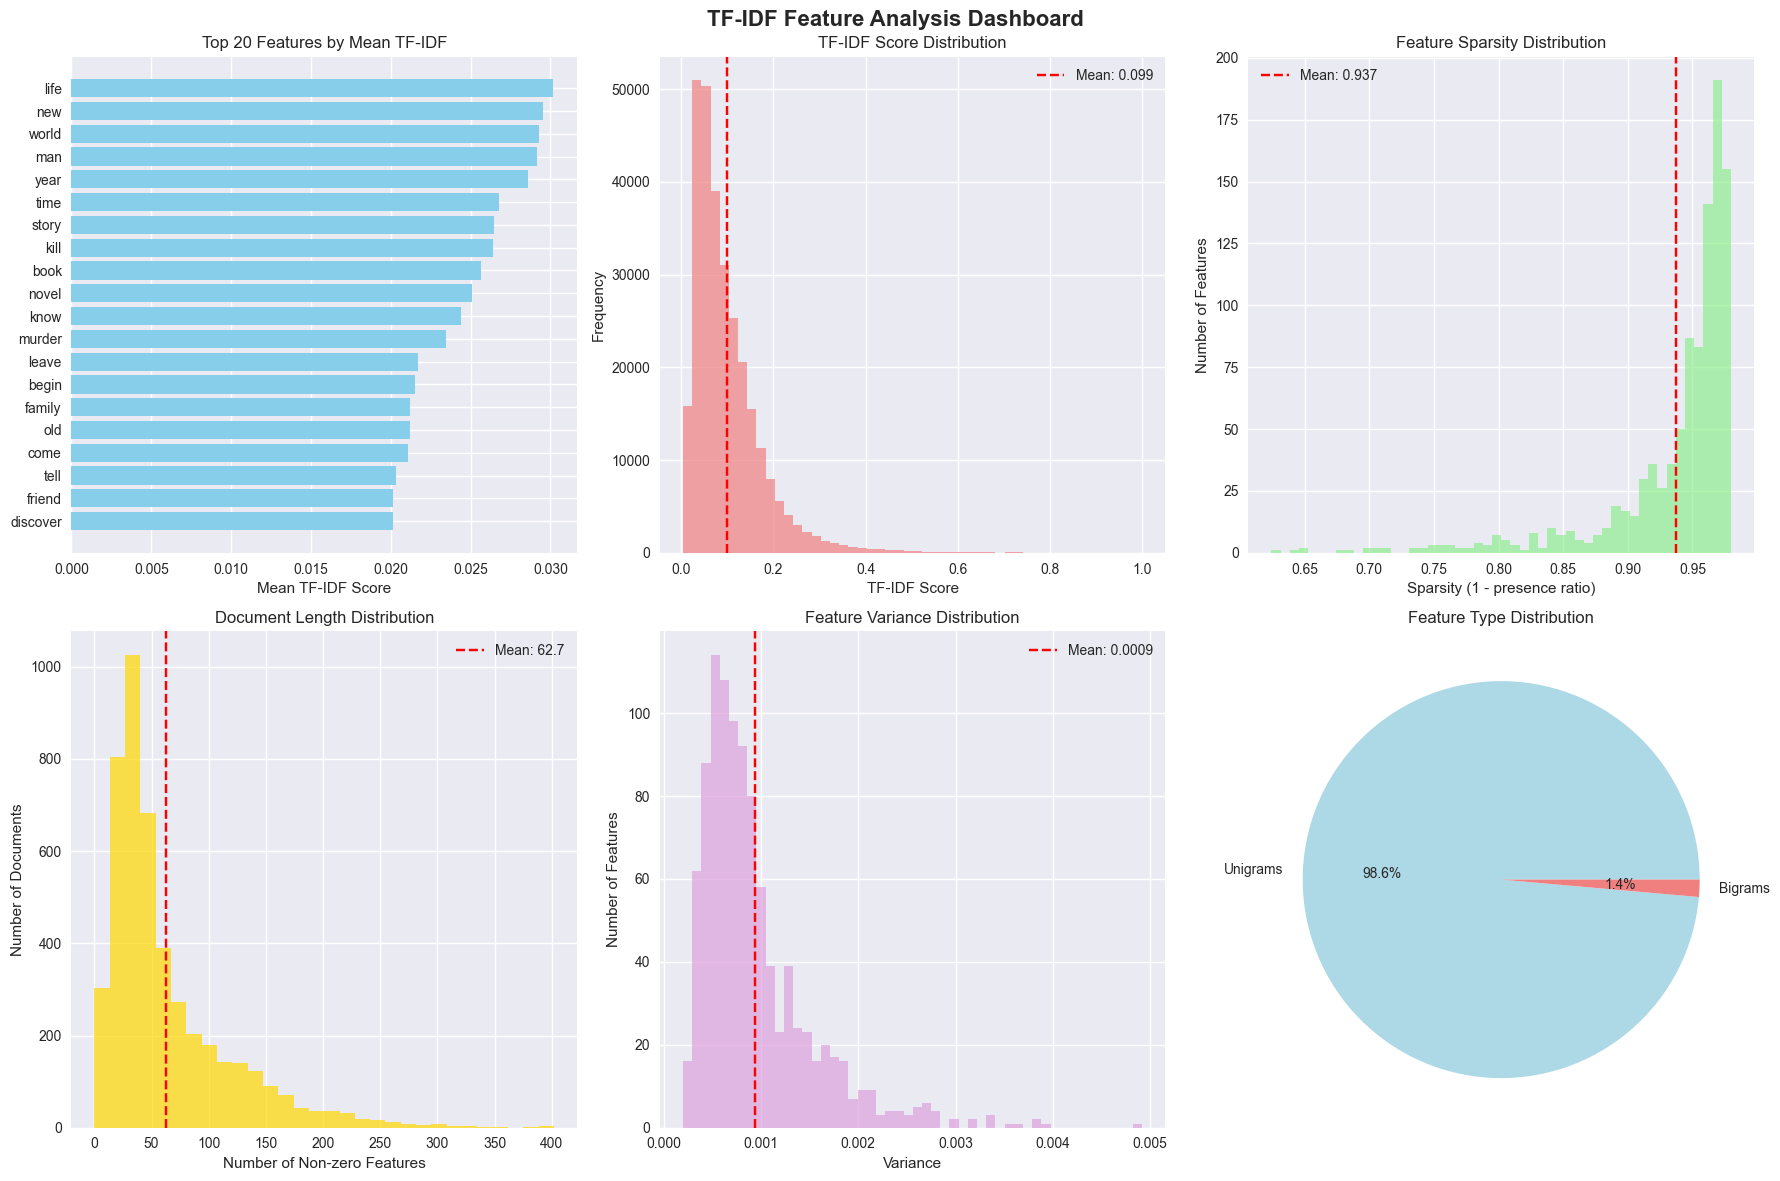

TF-IDF analysis plots completed!


In [17]:
tfidf_matrix, tfidf_vectorizer, feature_names = create_tfidf_features(
    book_data_cleaned['summary'],
    max_features=1000,
    ngram_range=(1, 2),
    min_df=0.02,
    max_df=0.95,
    verbose=True
)

feature_importance = analyze_feature_importance(
    tfidf_matrix,
    feature_names,
    method='mean',
    top_n=20
)

plot_tfidf_analysis(tfidf_matrix, feature_names, figsize=(18, 12))

### Clustering models

In [21]:
X = tfidf_matrix.toarray()
X.shape

(4653, 1000)

Chạy qua các hyperparams cluster_k, mỗi cluster chạy state lần để khảo sát nhiều sự hội tụ, mỗi state chạy qua hai model chính để đánh giá

In [31]:
n_state = 5
k_clusters = list(range(2,15))
num_models = 2
lst_models = ['Kmeans', 'GMM']
total_results = []

def calculate_gmm_wsse(data, gmm_model):
    labels = gmm_model.predict(data)
    
    centers = gmm_model.means_
    
    wsse = 0.0
    for i in range(len(data)):
        cluster_id = labels[i]
        center = centers[cluster_id]
        wsse += np.sum((data[i] - center) ** 2)
    
    return wsse

for model_name in lst_models:
    model_results = {}
    for k in k_clusters:
        k_results = []

        for state in range(1 , n_state+1):
            if model_name == 'Kmeans':
                model = KMeans(n_clusters=k, random_state= state,
                                n_init=20, max_iter=300)
            elif model_name == 'GMM':
                model = GaussianMixture(n_components=k, random_state= state,
                                        max_iter=300, n_init=3)
        
            model.fit(X)

            if model_name == 'Kmeans':
                labels = model.labels_
                inertia = model.inertia_
            else:
                labels = model.predict(X)
                inertia = calculate_gmm_wsse(X, model)

            silhouette_avg = silhouette_score(X, labels)

            k_results.append({
                'model': model_name,
                'labels': labels,
                'inertia': inertia,
                'silhouette_score': silhouette_avg,
                'n_clusters': k,
                'state': state
            })

        best_run = max(k_results, key=lambda x: x['silhouette_score'])
        model_results[k] = best_run
    total_results.append(model_results)



📊 Creating Multiple K Silhouette Analysis for K-Means


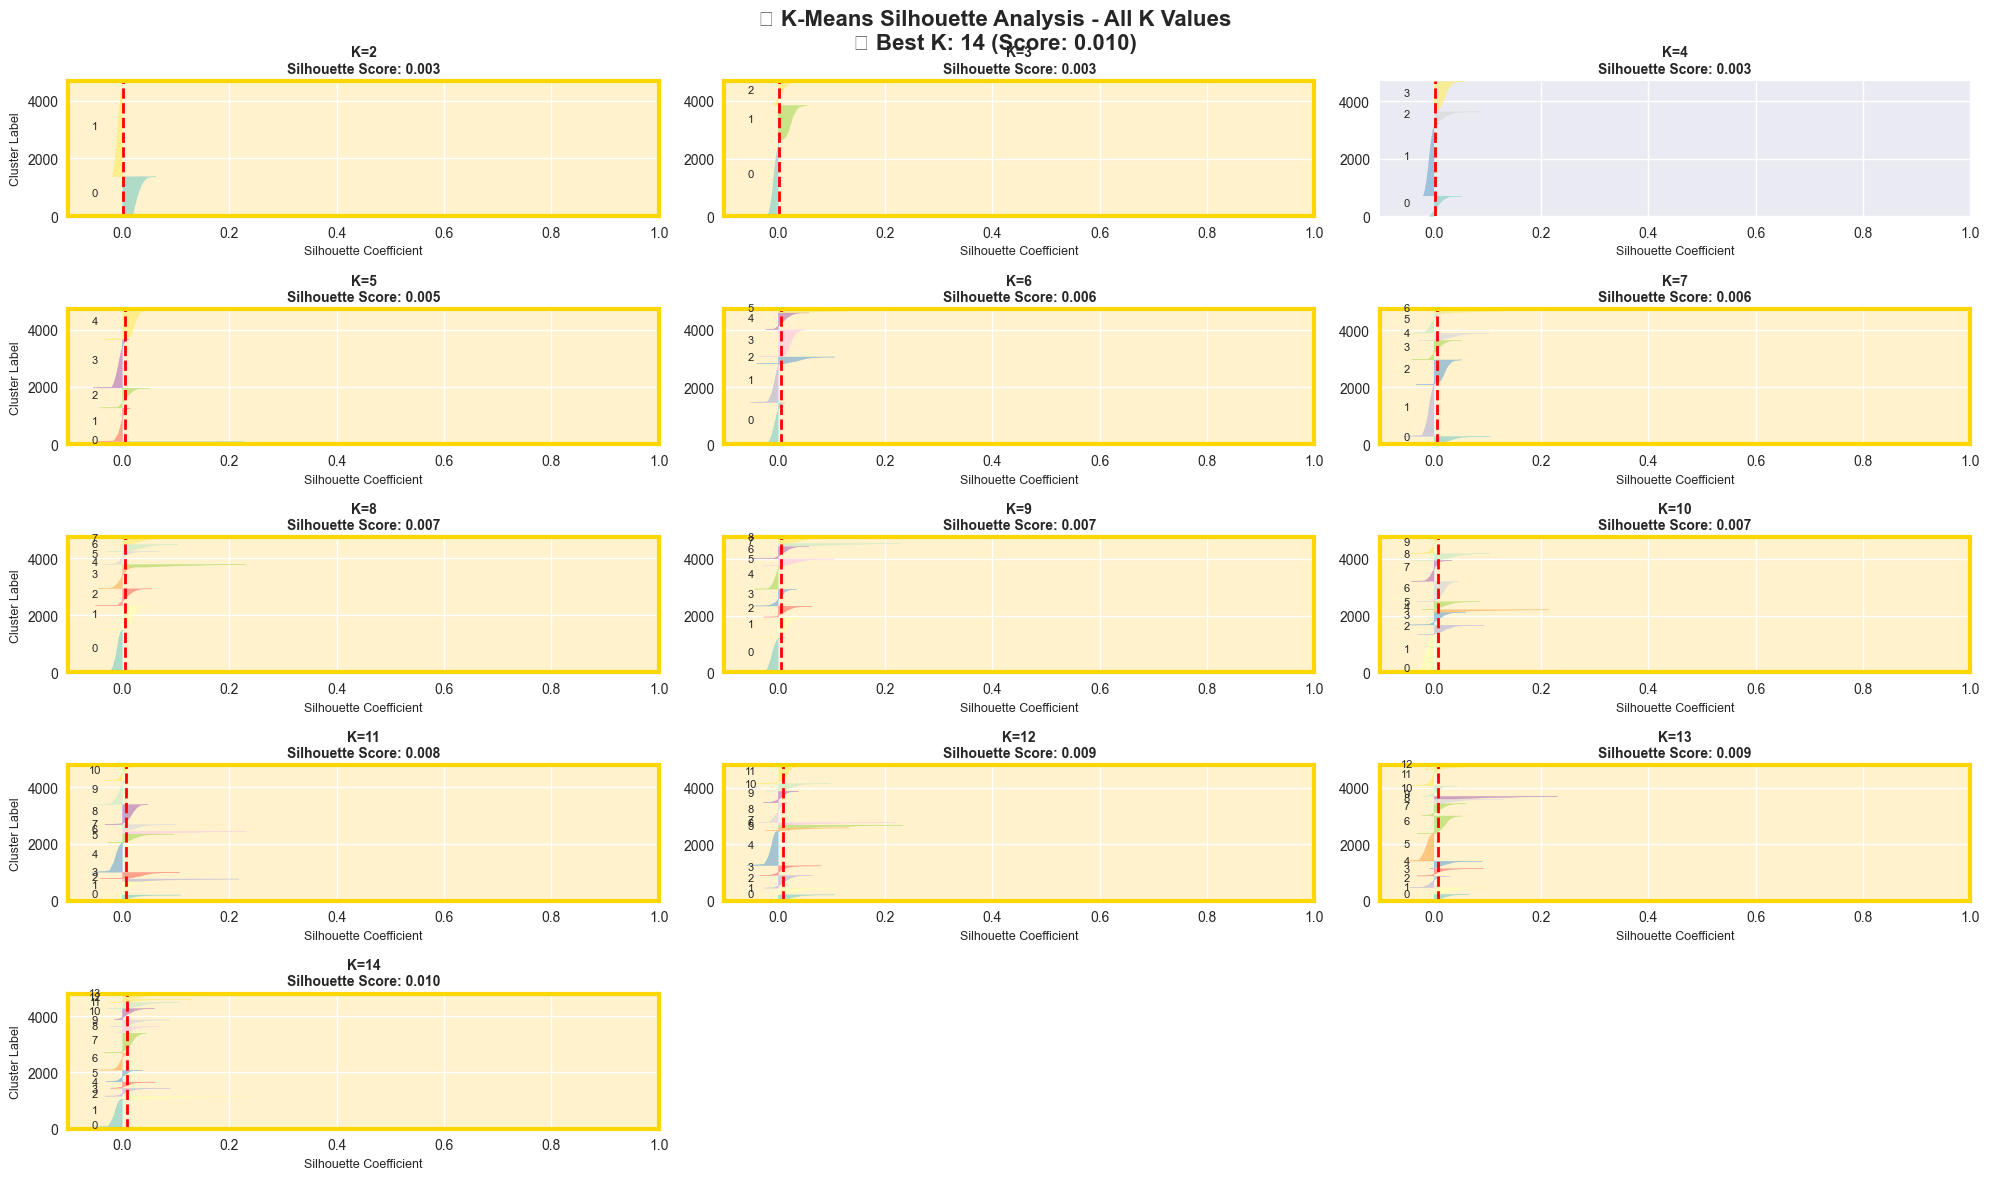

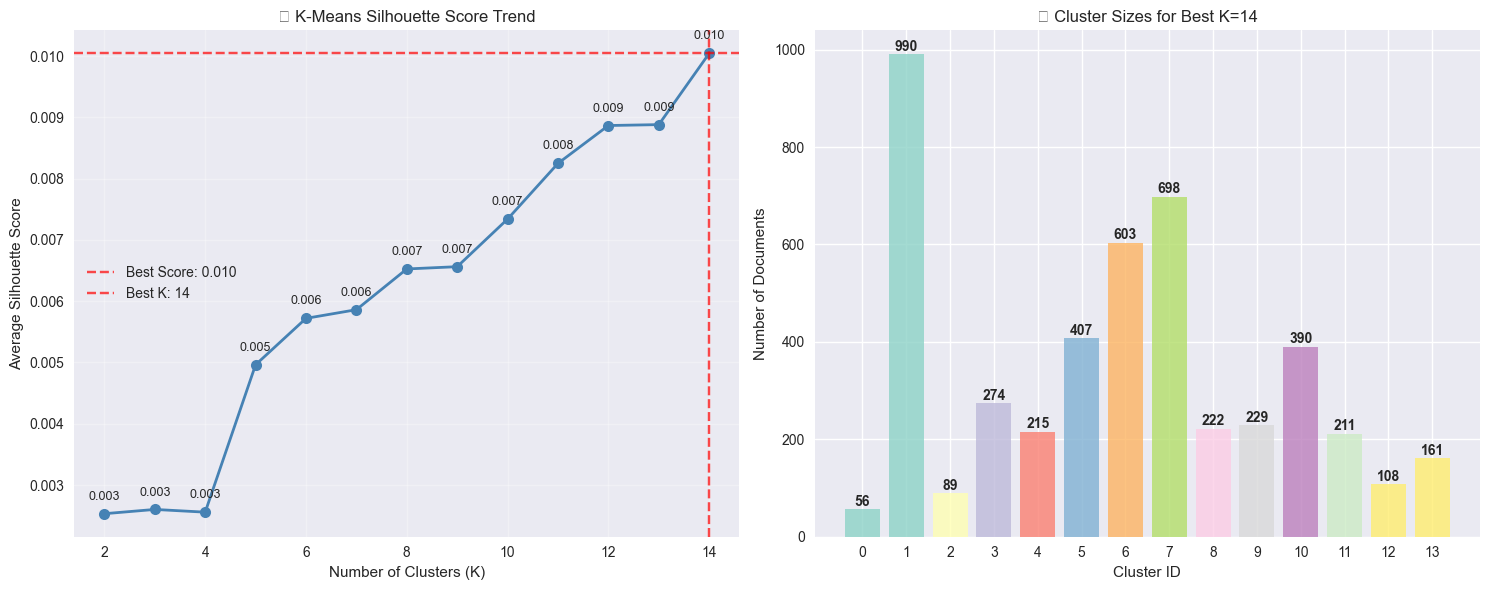


📊 Detailed Analysis for K-Means:
🏆 Best K: 14 (Silhouette Score: 0.010)
📊 K values tested: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
📈 Score range: 0.003 - 0.010

📊 All K Results:
   K=2: 0.003    
   K=3: 0.003    
   K=4: 0.003    
   K=5: 0.005    
   K=6: 0.006    
   K=7: 0.006    
   K=8: 0.007    
   K=9: 0.007    
   K=10: 0.007    
   K=11: 0.008    
   K=12: 0.009    
   K=13: 0.009    
   K=14: 0.010 🏆 BEST

💡 Interpretation Guide:
   • Higher silhouette score = better separated clusters
   • Score > 0.5: Strong cluster structure
   • Score 0.25-0.5: Moderate cluster structure
   • Score < 0.25: Weak cluster structure

✅ Multiple K silhouette analysis completed!
🎯 Recommendation: Consider K=14 for best separation

 The best k for Kmeans is 14
📊 Creating Multiple K Silhouette Analysis for GMM


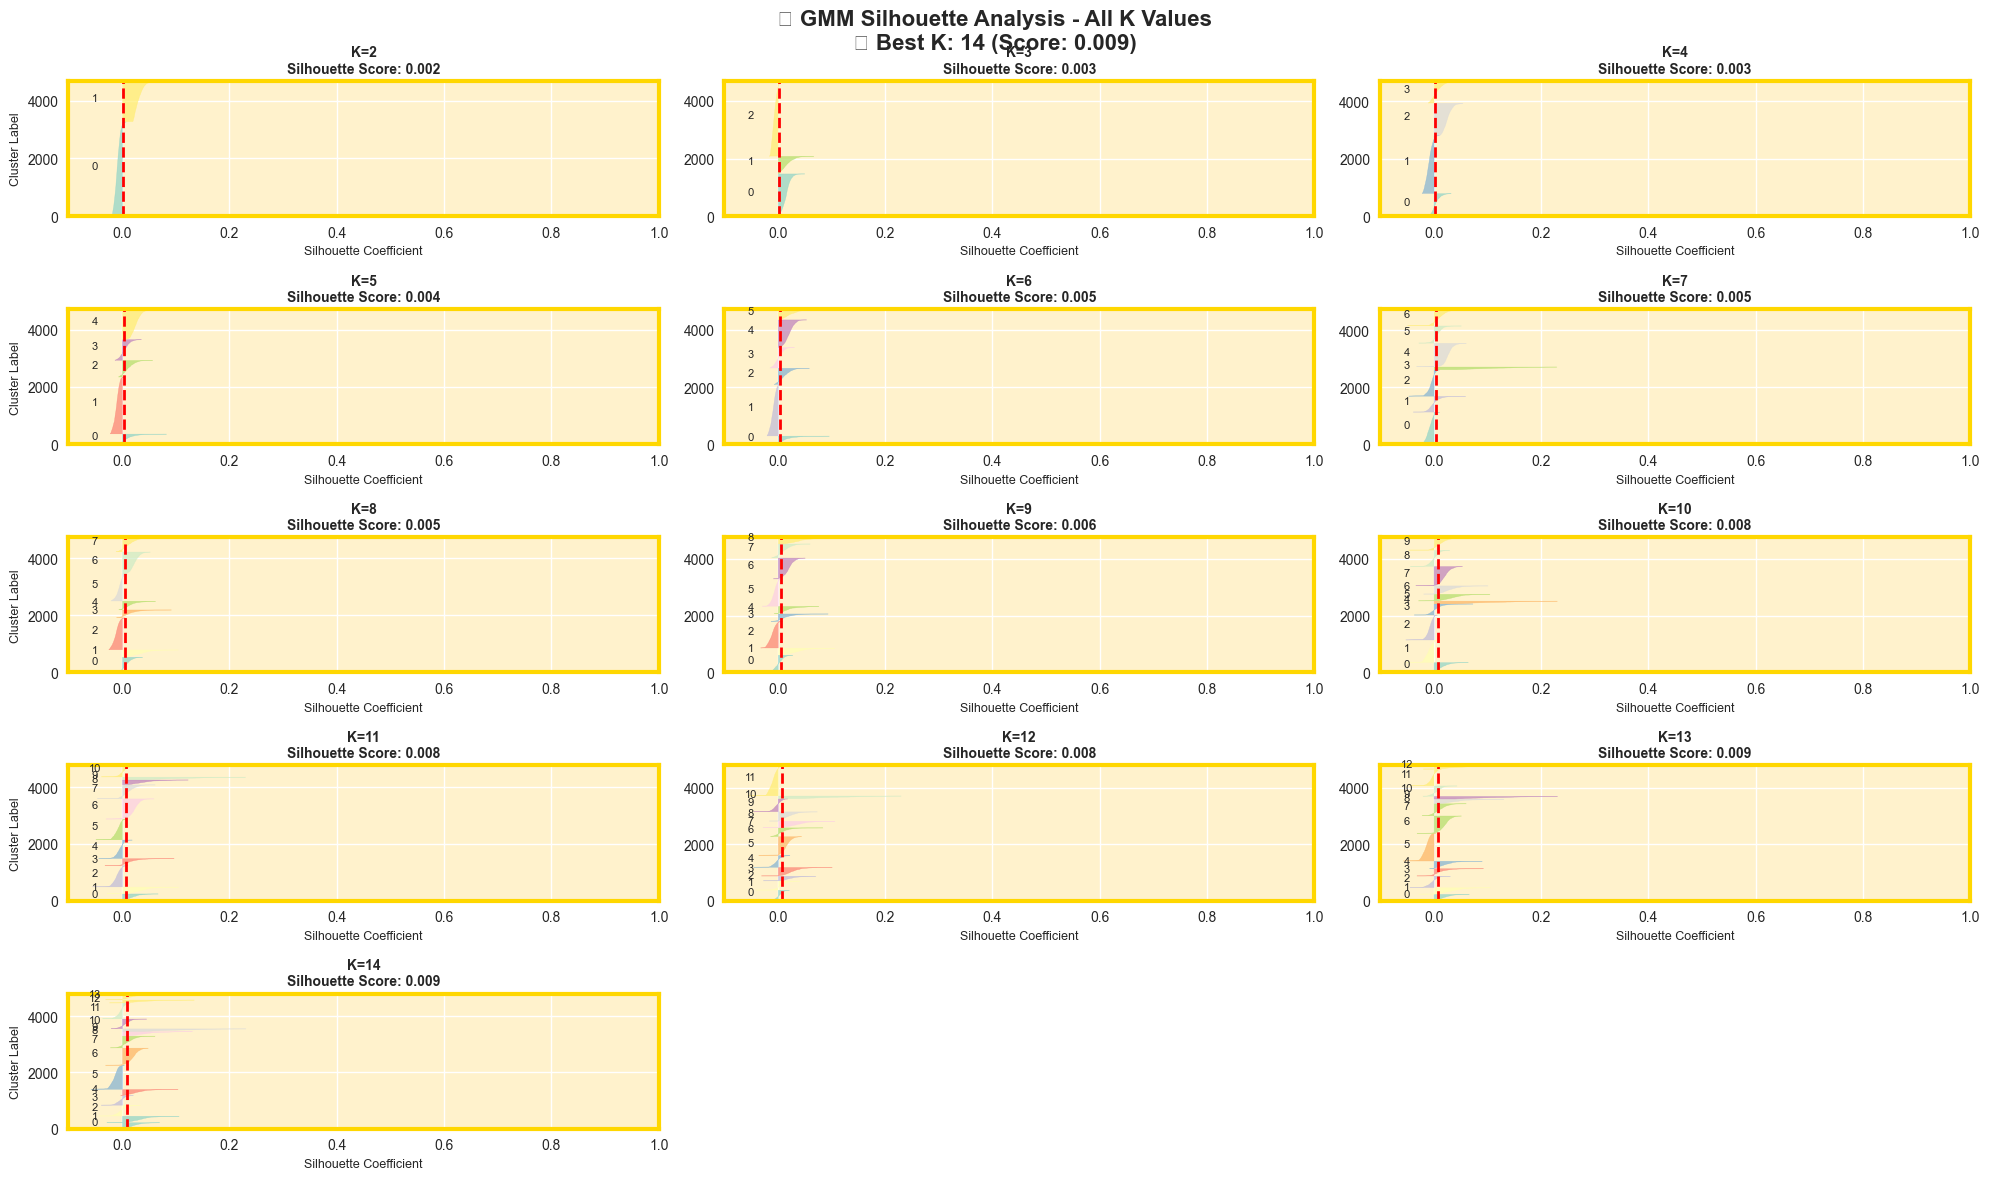

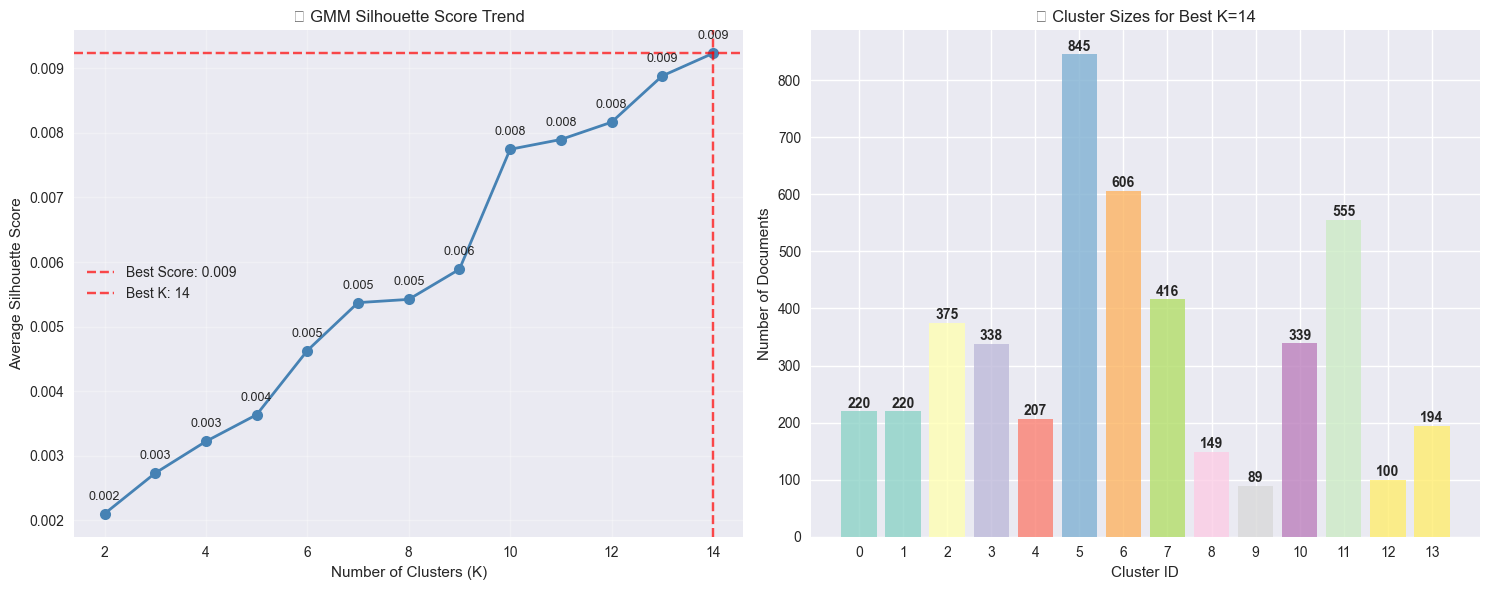


📊 Detailed Analysis for GMM:
🏆 Best K: 14 (Silhouette Score: 0.009)
📊 K values tested: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
📈 Score range: 0.002 - 0.009

📊 All K Results:
   K=2: 0.002    
   K=3: 0.003    
   K=4: 0.003    
   K=5: 0.004    
   K=6: 0.005    
   K=7: 0.005    
   K=8: 0.005    
   K=9: 0.006    
   K=10: 0.008    
   K=11: 0.008    
   K=12: 0.008    
   K=13: 0.009    
   K=14: 0.009 🏆 BEST

💡 Interpretation Guide:
   • Higher silhouette score = better separated clusters
   • Score > 0.5: Strong cluster structure
   • Score 0.25-0.5: Moderate cluster structure
   • Score < 0.25: Weak cluster structure

✅ Multiple K silhouette analysis completed!
🎯 Recommendation: Consider K=14 for best separation

 The best k for Kmeans is 14


In [32]:
best_k_kmeans, best_score_kmeans = plot_silhouette_analysis_multiple_k(
    X,
    total_results[0],
    method_name='K-Means',
    figsize=(20, 12)
)

print(f"\n The best k for Kmeans is {best_k_kmeans}")


best_k_gmm, best_score_gmm = plot_silhouette_analysis_multiple_k(
    X,
    total_results[1],
    method_name='GMM',
    figsize=(20, 12)
)

print(f"\n The best k for Kmeans is {best_k_gmm}")


In [33]:
print(f"{'Method':<10} {'k':<5} {'Silhouette':<12} {'Inertia':<12}")
print("-" * 39)
for i, dict_result_model in enumerate(total_results):
    for k_cluster, result_dict in dict_result_model.items():
        print(f"{lst_models[i]:<10} {k:<5} {result_dict['silhouette_score']:<12.3f} "
                      f"{result_dict['inertia']:<12.2f}")

Method     k     Silhouette   Inertia     
---------------------------------------
Kmeans     14    0.003        4344.31     
Kmeans     14    0.003        4320.30     
Kmeans     14    0.003        4300.13     
Kmeans     14    0.005        4281.54     
Kmeans     14    0.006        4262.92     
Kmeans     14    0.006        4245.87     
Kmeans     14    0.007        4231.87     
Kmeans     14    0.007        4217.37     
Kmeans     14    0.007        4204.60     
Kmeans     14    0.008        4192.53     
Kmeans     14    0.009        4183.25     
Kmeans     14    0.009        4172.75     
Kmeans     14    0.010        4164.29     
GMM        14    0.002        4344.60     
GMM        14    0.003        4324.65     
GMM        14    0.003        4302.06     
GMM        14    0.004        4287.47     
GMM        14    0.005        4270.07     
GMM        14    0.005        4254.23     
GMM        14    0.005        4240.69     
GMM        14    0.006        4224.67     
GMM        14 

Chọn K means với K = 10, vì inertia và silhouette cao vừa và ổn định, các đầu mút đều chạm silhouette và đuôi misclassify ít
Chỉ số silhouette thấp là vì các vector feature không có tính đặc trưng mạnh mà chỉ dựa vào word counts, các summary muốn thuộc genre nào cần nắm sâu về semantics


📊 Creating Cluster Comparison Plot


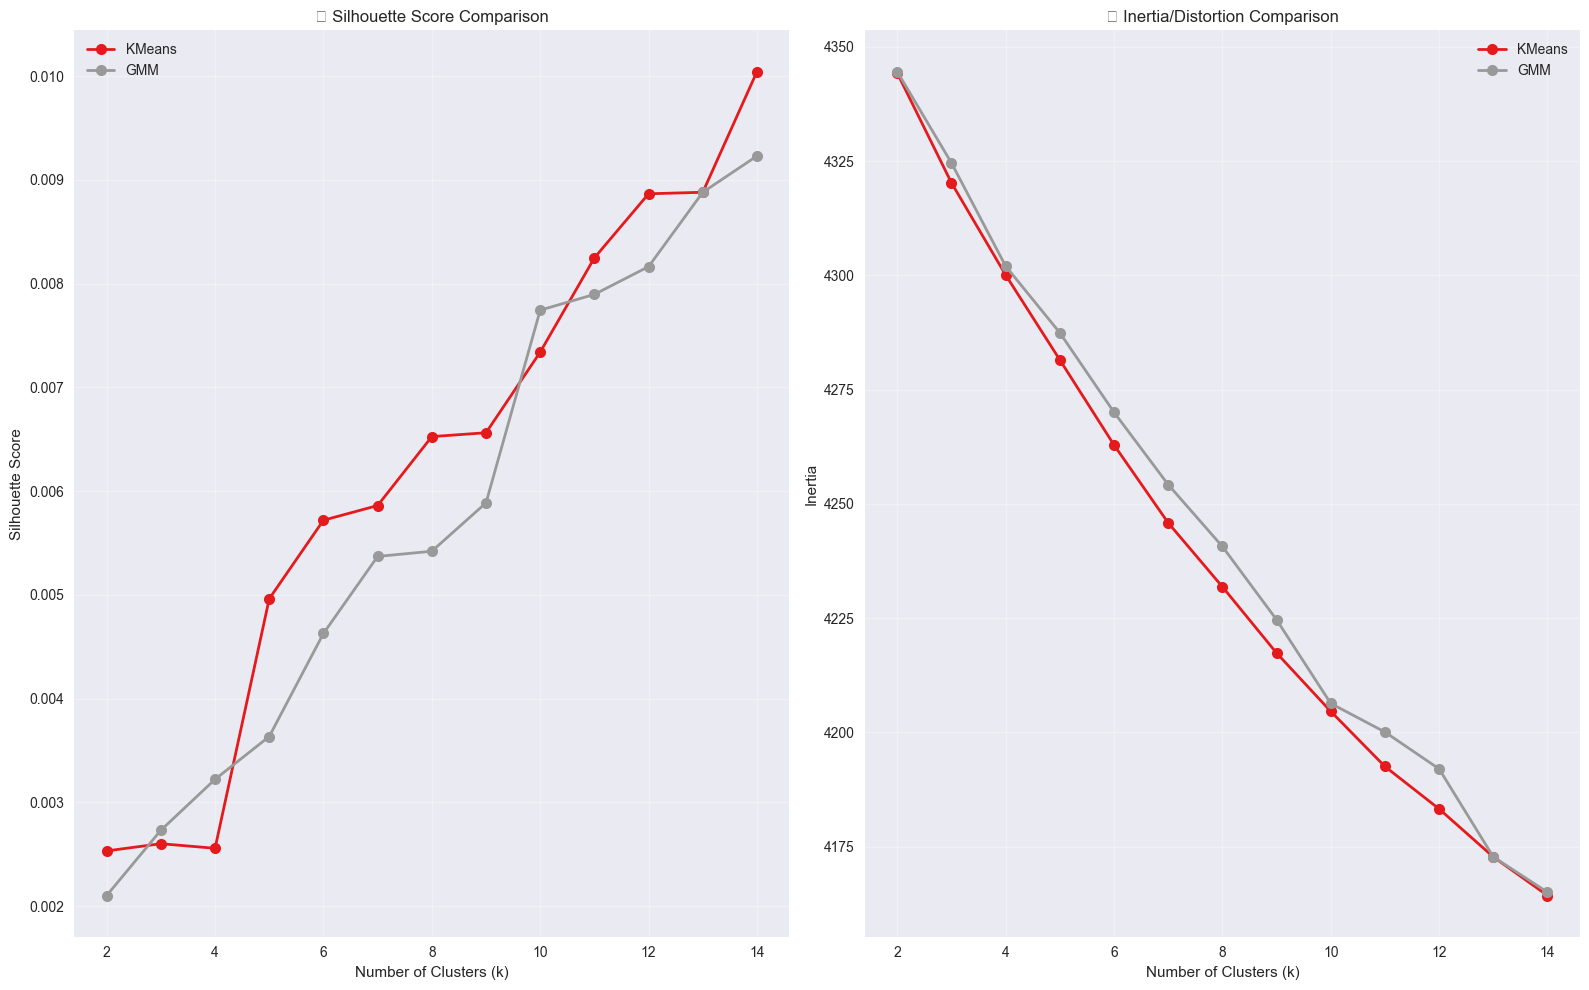

✅ Cluster comparison plot completed!


In [34]:
combined_results = {
    'KMeans': total_results[0],
    'GMM': total_results[1]
}

plot_cluster_comparison(
    combined_results,
    metrics=['silhouette', 'inertia'],
    figsize=(16, 10)
)

### Clustering analysis

In [39]:
chosen_k = 10
chosen_kmeans_result = total_results[0][chosen_k]
chosen_kmeans_labels = chosen_kmeans_result['labels']
print(f"Selected  for GMM based on silhouette analysis")
print(f"Silhouette Score: {chosen_kmeans_result['silhouette_score']}")
print(f"Number of clusters: {len(np.unique(chosen_kmeans_labels))}")
print(f"Cluster sizes: {np.bincount(chosen_kmeans_labels)}")

Selected  for GMM based on silhouette analysis
Silhouette Score: 0.007340331237100888
Number of clusters: 10
Cluster sizes: [  88 1236  328  443   80  275  702  727  232  542]


In [41]:
print("\n Cluster purity analysis:")

for cluster_id in np.unique(chosen_kmeans_labels):
    cluster_mask = chosen_kmeans_labels == cluster_id
    cluster_categories = book_data_cleaned[cluster_mask]['genre']

    # Most common category in this cluster
    most_common_category = cluster_categories.mode()[0]
    purity = (cluster_categories == most_common_category).mean()

    print(f"Cluster {cluster_id}:")
    print(f"   Size: {np.sum(cluster_mask)} books")
    print(f"   Most common category: {most_common_category}")
    print(f"   Purity: {purity:.3f}")
    print(f"   Category distribution: {cluster_categories.value_counts().to_dict()}")


 Cluster purity analysis:
Cluster 0:
   Size: 88 books
   Most common category: horror
   Purity: 0.795
   Category distribution: {'horror': 70, 'fantasy': 13, 'romance': 3, 'crime': 1, 'thriller': 1}
Cluster 1:
   Size: 1236 books
   Most common category: thriller
   Purity: 0.265
   Category distribution: {'thriller': 327, 'fantasy': 287, 'horror': 188, 'science': 143, 'history': 111, 'crime': 108, 'travel': 35, 'psychology': 16, 'romance': 11, 'sports': 10}
Cluster 2:
   Size: 328 books
   Most common category: science
   Purity: 0.671
   Category distribution: {'science': 220, 'fantasy': 37, 'history': 27, 'thriller': 26, 'horror': 15, 'crime': 2, 'travel': 1}
Cluster 3:
   Size: 443 books
   Most common category: crime
   Purity: 0.544
   Category distribution: {'crime': 241, 'thriller': 156, 'horror': 29, 'history': 7, 'fantasy': 4, 'science': 3, 'romance': 3}
Cluster 4:
   Size: 80 books
   Most common category: thriller
   Purity: 0.312
   Category distribution: {'thriller': 2

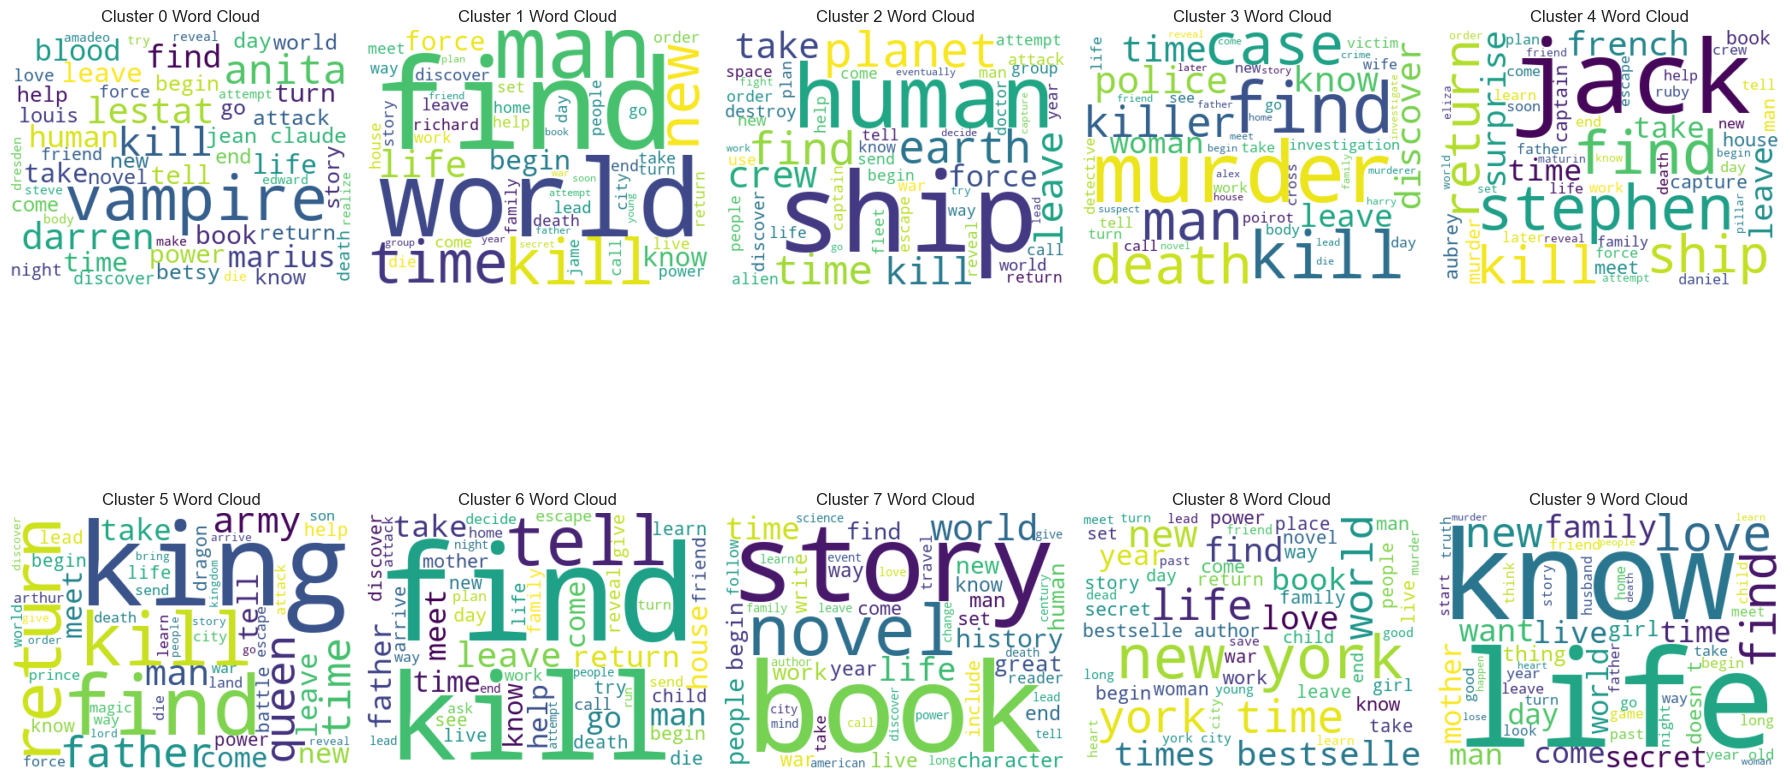

In [46]:
fig, axes = plt.subplots(2, 5, figsize=(18, 12))
axes = axes.flatten()

for cluster_id in np.unique(chosen_kmeans_labels):
    if cluster_id < len(axes):
        cluster_mask = chosen_kmeans_labels == cluster_id
        cluster_articles = book_data_cleaned[cluster_mask]['summary']

        cluster_text = ' '.join(cluster_articles)

        wordcloud = WordCloud(
            width=400,
            height=300,
            background_color='white',
            colormap='viridis',
            max_words=50
        ).generate(cluster_text)

        axes[cluster_id].imshow(wordcloud, interpolation='bilinear')
        axes[cluster_id].axis('off')
        axes[cluster_id].set_title(f'Cluster {cluster_id} Word Cloud')

for i in range(len(np.unique(chosen_kmeans_labels)), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Neural Networks (Deep Learning) — Fashion-MNIST (ANN)

Sử dụng bộ dữ liệu Fashion-MNIST (CSV) đã được đặt tại `Data/FashionMNIST/` gồm:
- `fashion-mnist_train.csv`
- `fashion-mnist_test.csv`

Mô tả: 70,000 ảnh xám 28x28 của 10 lớp thời trang (0–9). File CSV có cột `label` và 784 cột pixel.



In [ ]:
# Câu 3: Neural Networks (Deep Learning) — Fashion-MNIST (ANN)

# TODO: Thực hiện các bước sau:
# 1. Đọc `Data/FashionMNIST/fashion-mnist_train.csv` và `fashion-mnist_test.csv`
# 2. Chuẩn hóa pixel về [0,1]; one-hot labels
# 3. Chia train/val/test; xây MLP: Flatten(784) -> Dense hidden layers (ReLU, BatchNorm/Dropout) -> Softmax(10)
# 4. Huấn luyện mô hình; lưu history (loss/accuracy) và thời gian huấn luyện
# 5. Đánh giá test: Accuracy, Confusion Matrix, Classification Report
# 6. Trực quan hóa: learning curves, ví dụ dự đoán đúng/sai
# 7. Nhận xét và đề xuất cải tiến

### utils


In [ ]:
def evaluate_svm_performance(model, X_train, X_test, y_train, y_test, 
                           class_names=None, verbose=True):
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    results = {
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'n_support_vectors': len(model.support_vectors_) if hasattr(model, 'support_vectors_') else 0,
        'confusion_matrix': confusion_matrix(y_test, y_test_pred)
    }
    
    if verbose:
        print(f"📊 SVM Performance Evaluation:")
        print(f"   Training Accuracy: {train_accuracy:.4f}")
        print(f"   Test Accuracy: {test_accuracy:.4f}")
        print(f"   Overfitting Gap: {abs(train_accuracy - test_accuracy):.4f}")
        
        if hasattr(model, 'support_vectors_'):
            print(f"   Support Vectors: {len(model.support_vectors_)}")
            print(f"   SV Percentage: {len(model.support_vectors_)/len(X_train)*100:.1f}%")
        
        print(f"\n📋 Detailed Classification Report:")
        target_names = class_names if class_names else [f"Class {i}" for i in np.unique(y_test)]
        print(classification_report(y_test, y_test_pred, target_names=target_names))
    
    return results


def plot_confusion_matrix_enhanced(y_true, y_pred, class_names=None, 
                                 title="Enhanced Confusion Matrix", figsize=(10, 8)):
    """
    Plot an enhanced confusion matrix with additional statistics.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Raw confusion matrix
    im1 = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[0].figure.colorbar(im1, ax=axes[0])
    
    # Add labels
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(cm))]
    
    axes[0].set_xticks(range(len(class_names)))
    axes[0].set_yticks(range(len(class_names)))
    axes[0].set_xticklabels(class_names)
    axes[0].set_yticklabels(class_names)
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    axes[0].set_title('Raw Counts')
    
    # Add text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black",
                        fontsize=14, fontweight='bold')
    
    # Normalized confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    im2 = axes[1].imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    axes[1].figure.colorbar(im2, ax=axes[1])
    
    axes[1].set_xticks(range(len(class_names)))
    axes[1].set_yticks(range(len(class_names)))
    axes[1].set_xticklabels(class_names)
    axes[1].set_yticklabels(class_names)
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')
    axes[1].set_title('Normalized (Recall)')
    
    # Add text annotations
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            axes[1].text(j, i, format(cm_normalized[i, j], '.3f'),
                        ha="center", va="center",
                        color="white" if cm_normalized[i, j] > 0.5 else "black",
                        fontsize=12, fontweight='bold')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Read and overview data

In [ ]:
train_mnist = pd.read_csv(r'Data\FashionMNIST\fashion-mnist_train.csv')
test_mnist = pd.read_csv(r'Data\FashionMNIST\fashion-mnist_test.csv')
temp_df = pd.concat([train_mnist, test_mnist], axis=0)

In [ ]:
print(f"Dataset train shape: {temp_df.shape}")
print(f"Number of classes: {len(np.unique(temp_df.label))}")
print(f"Feature names: {temp_df.columns[:5]}...")  # Show first 5 feature names
print(f"Target size: {len(temp_df.label)}")

Dataset train shape: (70000, 785)
Number of classes: 10
Feature names: Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4'], dtype='object')...
Target size: 70000



 Class Distribution:
label
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


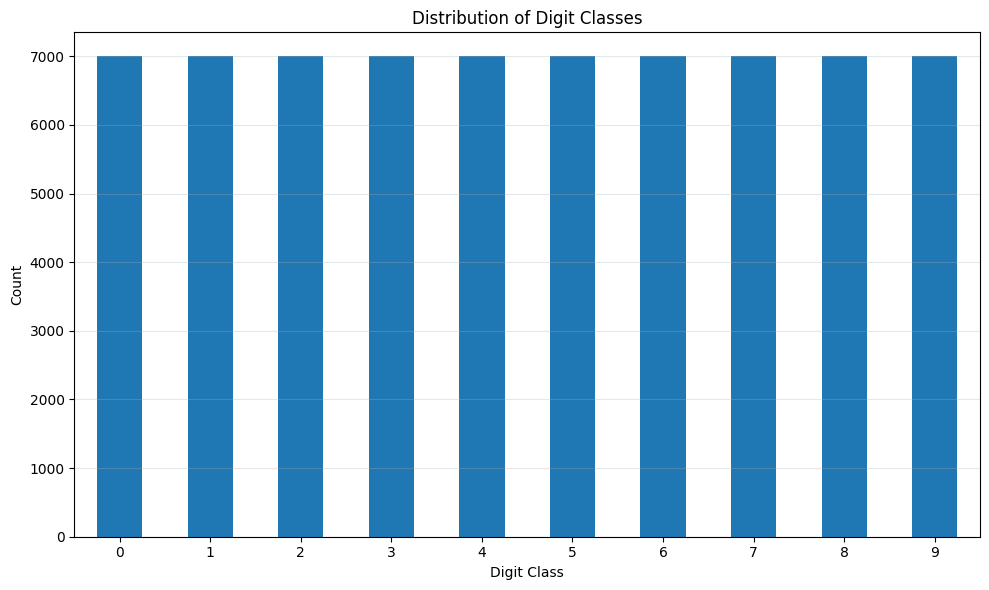

In [ ]:
# Show class distribution
print("\n Class Distribution:")
class_counts = pd.Series(temp_df.label).value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.title('Distribution of Digit Classes')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
train_mnist.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(f'train size: {train_mnist.shape}')
print(f'test size: {test_mnist.shape}')

train size: (60000, 785)
test size: (10000, 785)


In [ ]:
features = list(train_mnist.columns)[1:]

In [ ]:
train_mnist.iloc[0, 1:]

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 784, dtype: int64

Sample image


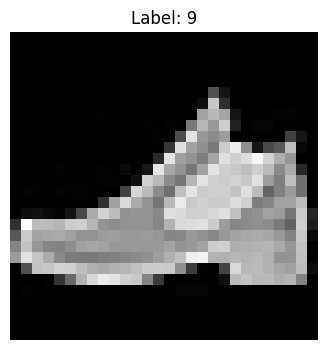

In [ ]:


print('Sample image')
image = train_mnist.iloc[1, 1:].to_numpy().astype('uint8').reshape(28,28)  
label = train_mnist.iloc[1, 0]

plt.figure(figsize=(4,4))
plt.title(f"Label: {label}")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

### Divide into train/test/val with Standardization and one-hot labels

In [ ]:
X_train = train_mnist[features]
X_test, X_val, y_test, y_val = train_test_split(test_mnist[features], test_mnist[['label']], test_size=0.3, random_state=42)
X_train_scaled = X_train/255.0
X_val_scaled = X_val/255.0
X_test_scaled = X_test/255.0

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(train_mnist[['label']])
y_test = encoder.transform(y_test[['label']])
y_val = encoder.transform(y_val[['label']])

### Build model MLP

In [ ]:
model = Sequential([
    InputLayer(shape=(784,)),
    Dense(128, activation='relu'),
    Dropout(0.1),
    BatchNormalization(),
    Dense(64, activation='relu', kernel_regularizer =L2(0.001) ),
    Dropout(0.1),
    BatchNormalization(),
    Dense(10, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=0.001), loss= categorical_crossentropy, metrics=['accuracy'])
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

Use earlystopping

In [ ]:
earlier = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Training

In [ ]:
history = model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=50, callbacks=earlier)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7525 - loss: 0.7632 - val_accuracy: 0.8160 - val_loss: 0.5590
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8132 - loss: 0.5835 - val_accuracy: 0.8247 - val_loss: 0.5230
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8248 - loss: 0.5521 - val_accuracy: 0.8480 - val_loss: 0.4840
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8260 - loss: 0.5348 - val_accuracy: 0.8550 - val_loss: 0.4538
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8316 - loss: 0.5141 - val_accuracy: 0.8443 - val_loss: 0.4894
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8330 - loss: 0.5039 - val_accuracy: 0.8363 - val_loss: 0.4649
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8362 - loss: 0.4984 - val_accuracy: 0.8443 - val_loss: 0.4777
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8448 - loss: 0.4850 - 

Learning curve

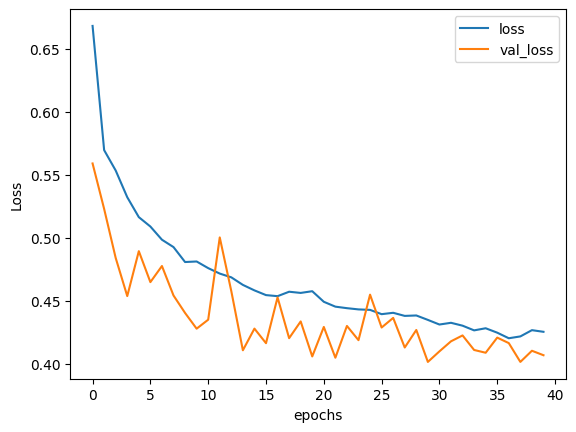

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend(['loss', 'val_loss'])
plt.show()


The learning curve is stable, it's just fine, not overfitting compared to the one which do not apply earlystoping 

### Evaluation

In [ ]:
y_pred_test = model.predict(X_test_scaled)

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
y_pred_test = np.argmax(y_pred_test, axis=1)
test_label = np.argmax(y_test, axis=1)
acc_test = accuracy_score(test_label, y_pred_test)
print(f'accuracy_score of test set : {acc_test}')

accuracy_score of test set : 0.871


In [ ]:
print(classification_report(test_label, y_pred_test))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       726
           1       0.96      0.98      0.97       714
           2       0.73      0.85      0.79       695
           3       0.87      0.91      0.89       716
           4       0.83      0.81      0.82       705
           5       0.95      0.90      0.93       693
           6       0.81      0.55      0.65       686
           7       0.90      0.93      0.91       684
           8       0.95      0.97      0.96       694
           9       0.93      0.94      0.94       687

    accuracy                           0.87      7000
   macro avg       0.87      0.87      0.87      7000
weighted avg       0.87      0.87      0.87      7000



Practical Application: Individual Digit Prediction
🎯 Analyzing Individual Predictions:


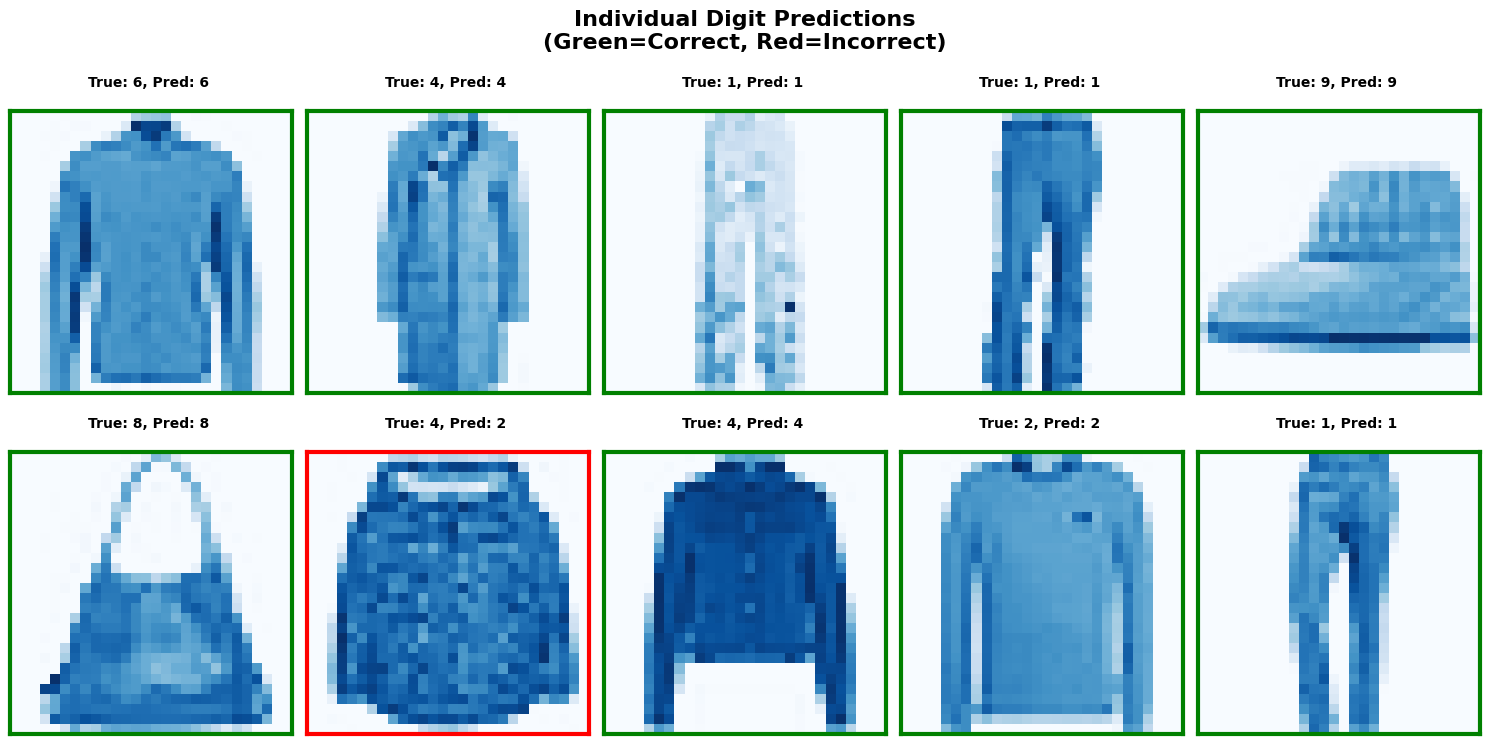

In [ ]:
print("Practical Application: Individual Digit Prediction")
print("=" * 55)

test_indices = [0, 10, 25, 50, 100, 150, 200, 300, 400, 500]

print("Analyzing Individual Predictions:")
print("=" * 40)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for i, idx in enumerate(test_indices):
    if idx >= len(X_test):
        continue

    sample_image = X_test.iloc[idx].values.reshape(28, 28)
    sample_scaled = X_test_scaled.iloc[idx:idx + 1]
    true_label = test_label[idx]

    prediction = y_pred_test[idx]

    ax = axes[i]
    ax.imshow(sample_image, cmap='Blues', interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])

    border_color = 'green' if prediction == true_label else 'red'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    ax.set_title(f'True: {true_label}, Pred: {prediction} \n',
                 fontsize=10, fontweight='bold')

plt.suptitle('Individual Digit Predictions\n(Green=Correct, Red=Incorrect)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


 Error Analysis:
Total misclassified samples: 903
Error rate: 12.90%

🔍 Most Common Misclassifications:
   6 → 0: 136 times
   6 → 2: 94 times
   4 → 2: 84 times
   2 → 4: 52 times
   6 → 4: 52 times


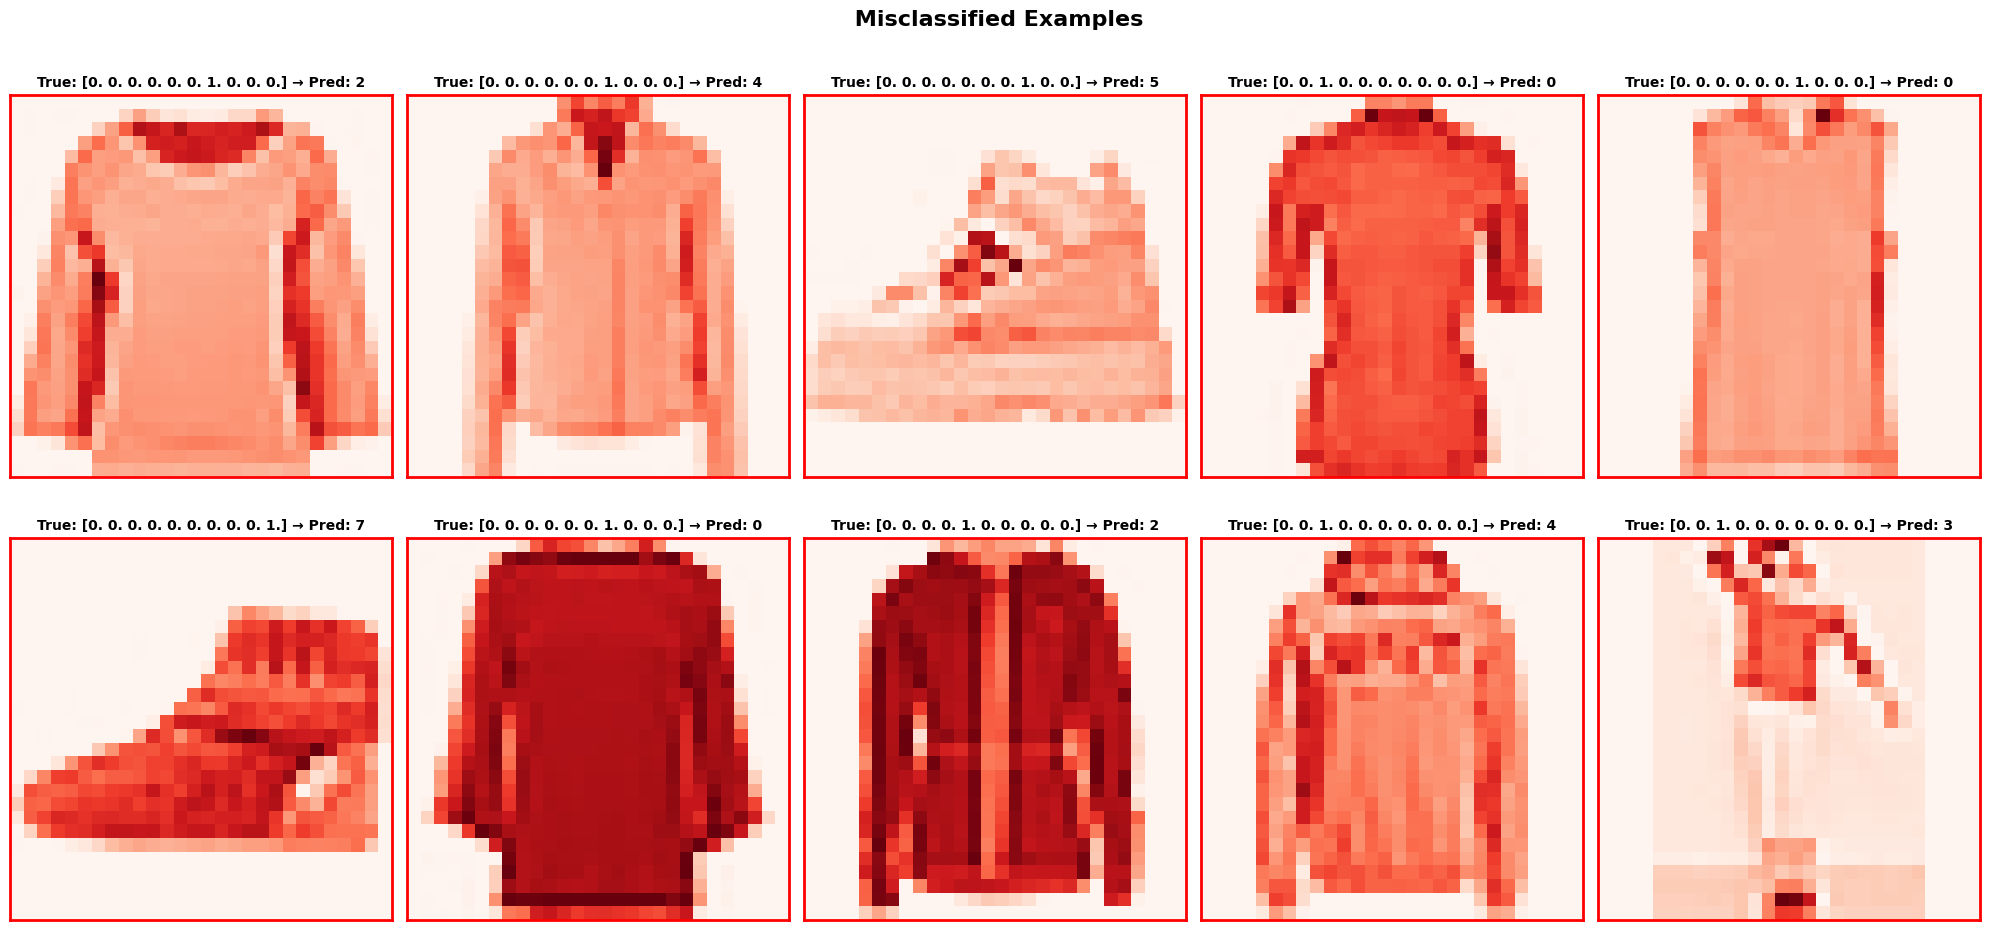

In [ ]:
# Error analysis
print("\n Error Analysis:")

misclassified_mask = y_pred_test != test_label
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified samples: {len(misclassified_indices)}")
print(f"Error rate: {len(misclassified_indices)/len(y_test)*100:.2f}%")

if len(misclassified_indices) > 0:
    # Show most common misclassifications
    error_pairs = [(test_label[i], y_pred_test[i]) for i in misclassified_indices]
    error_counts = pd.Series(error_pairs).value_counts()

    print("\n Most Common Misclassifications:")
    for (true, pred), count in error_counts.head(5).items():
        print(f"   {true} → {pred}: {count} times")

    # Visualize some misclassified examples
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.flatten()

    for i, idx in enumerate(misclassified_indices[:10]):
        sample_image = X_test.iloc[idx].values.reshape(28, 28)
        true_label = y_test[idx]
        pred_label = y_pred_test[idx]

        ax = axes[i]
        ax.imshow(sample_image, cmap='Reds', interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'True: {true_label} → Pred: {pred_label}',
                     fontsize=10, fontweight='bold')

        # Red border for errors
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

    plt.suptitle(' Misclassified Examples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Principal Component Analysis

**Cho dữ liệu Free spoken digit dataset**, lấy từ: https://www.kaggle.com/datasets/alanchn31/free-spoken-digits

Dữ liệu là các file audio record đọc các số đếm bằng tiếng Anh. Học viên tham khảo thêm cách sử dụng Jupyter Notebook **audio_to_spectrum_images.ipynb** để convert audio data sang image data.

Tham khảo: https://www.kaggle.com/code/christianlillelund/classify-mnist-audio-using-spectrograms-keras-cnn/notebook


In [ ]:
# Câu 4: Principal Component Analysis - Phân loại Audio số

# TODO: Thực hiện các bước sau:
# 1. Đọc và tiền xử lý dữ liệu audio
# 2. Chuyển đổi audio thành spectrogram hoặc MFCC features
# 3. Xây dựng model classification (không dùng PCA)
# 4. Đánh giá model
# 5. Áp dụng PCA để giảm chiều dữ liệu
# 6. Xây dựng lại model với dữ liệu đã giảm chiều
# 7. So sánh performance và thời gian thực hiện
# 8. Trực quan hóa kết quả

### Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import wave
import pylab
from pathlib import Path
from scipy import signal
from scipy.io import wavfile
import itertools
import cv2
from datetime import datetime
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier


import warnings
warnings.filterwarnings('ignore')

### Read and overivew

In [ ]:
INPUT_DIR = 'Data/recordings/recordings'
OUTPUT_DIR = 'Data/recordings/recordings'

parent_list = os.listdir(INPUT_DIR)
for i in range(10):
    print(parent_list[i])

0_george_0.wav
0_george_1.wav
0_george_10.wav
0_george_11.wav
0_george_12.wav
0_george_13.wav
0_george_14.wav
0_george_15.wav
0_george_16.wav
0_george_17.wav


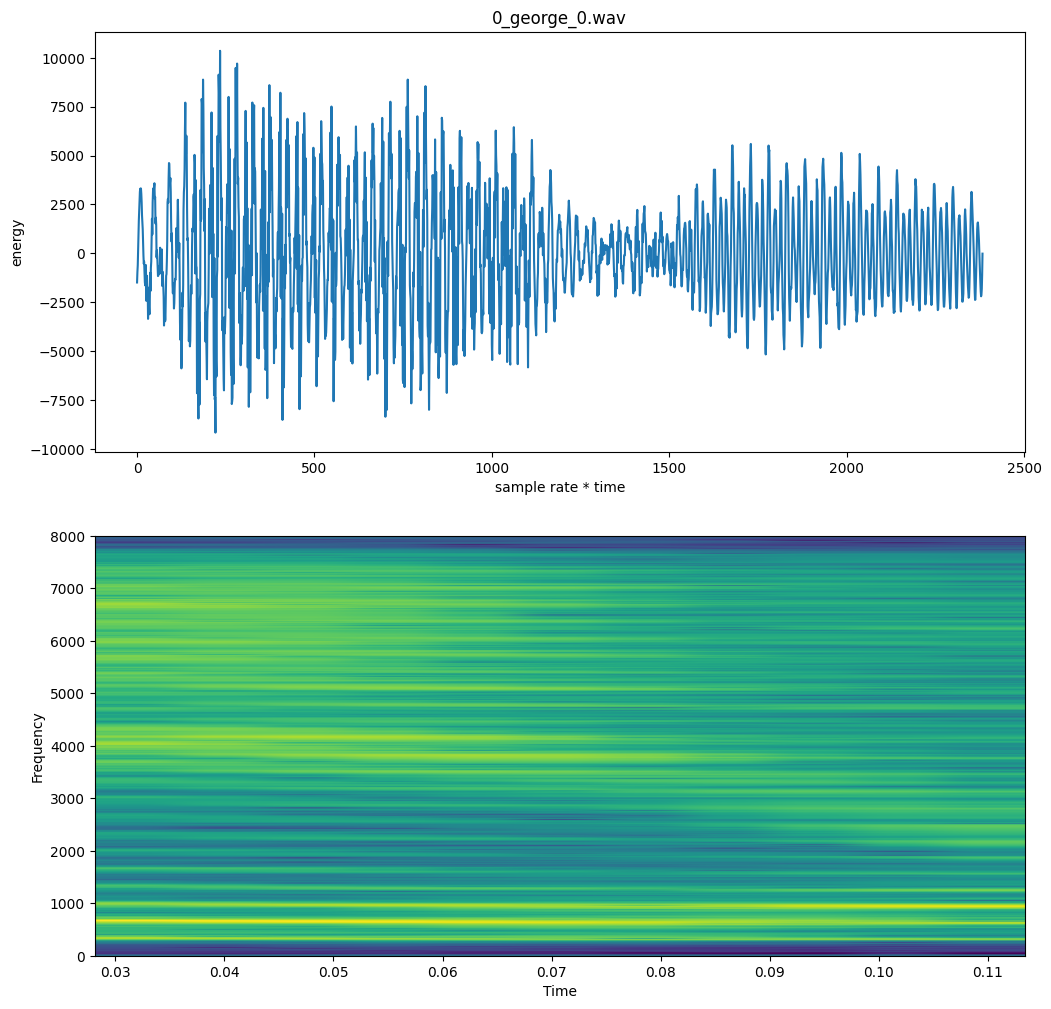

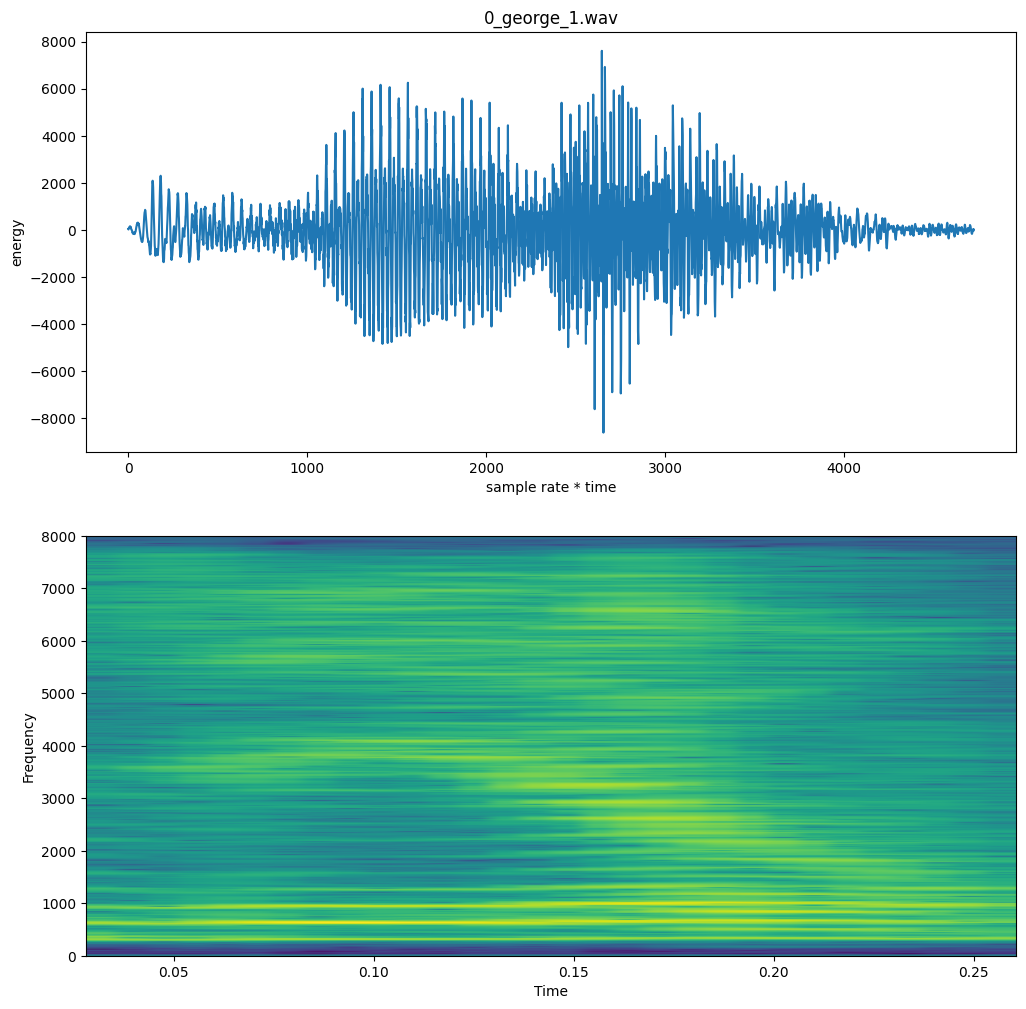

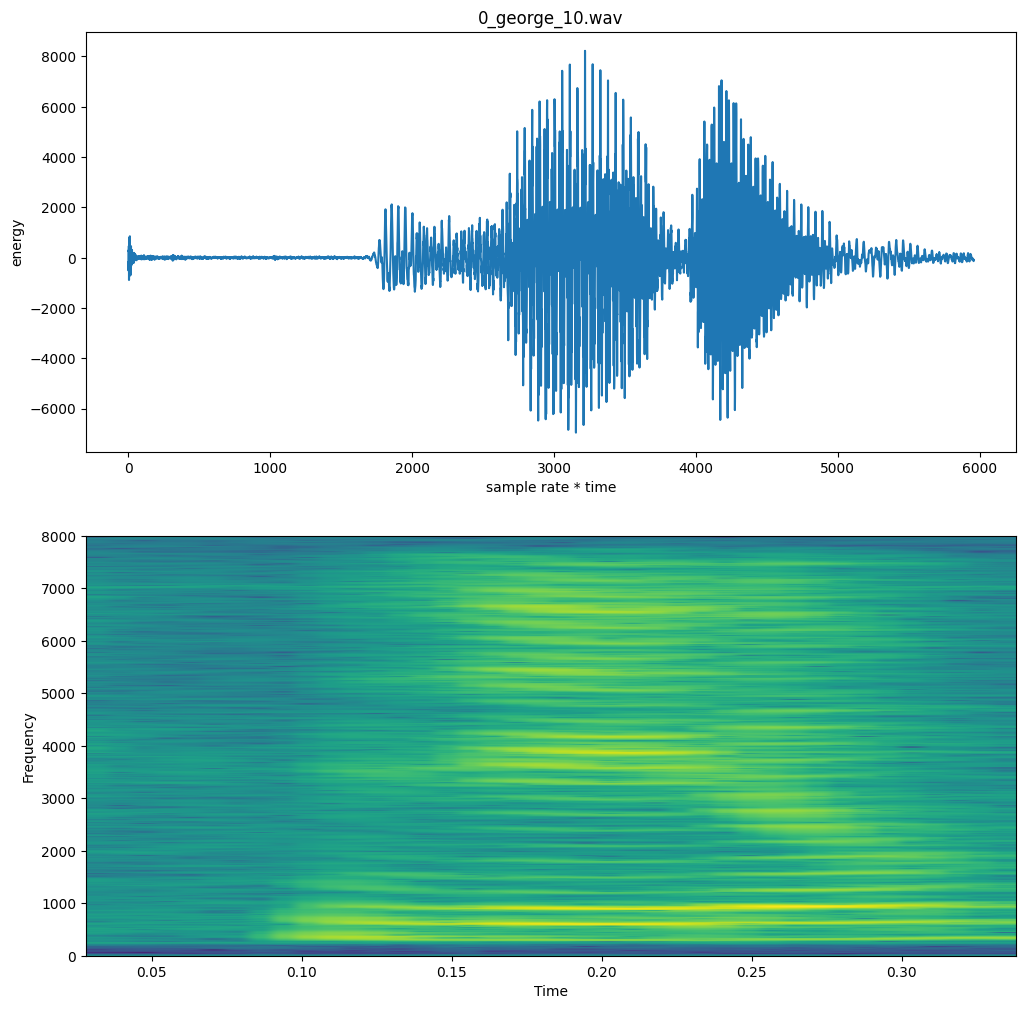

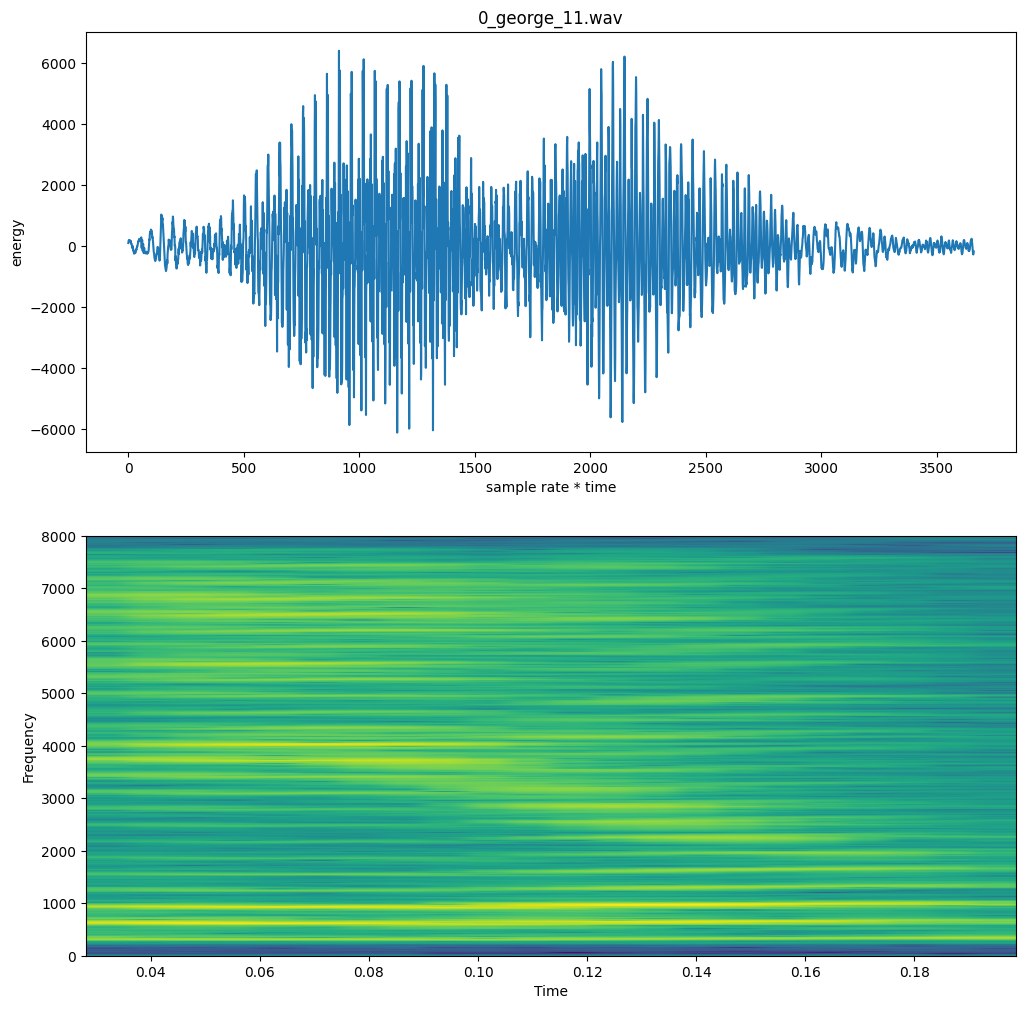

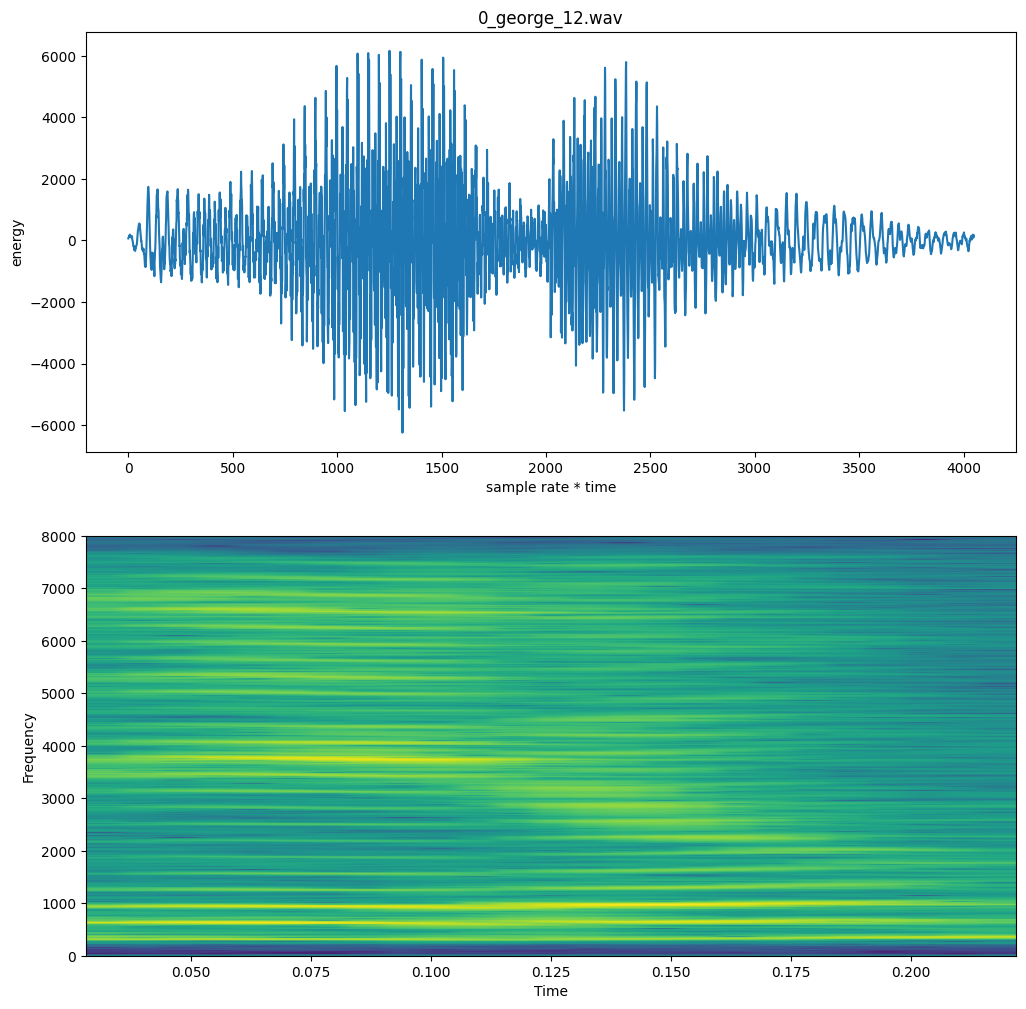

In [ ]:
for i in range(5):
    signal_wave = wave.open(os.path.join(INPUT_DIR, parent_list[i]), 'r')
    sample_rate = 16000
    sig = np.frombuffer(signal_wave.readframes(sample_rate), dtype=np.int16)

    plt.figure(figsize=(12, 12))
    plot_a = plt.subplot(211)
    plot_a.set_title(parent_list[i])
    plot_a.plot(sig)
    plot_a.set_xlabel('sample rate * time')
    plot_a.set_ylabel('energy')

    plot_b = plt.subplot(212)
    plot_b.specgram(sig, NFFT=1024, Fs=sample_rate, noverlap=900)
    plot_b.set_xlabel('Time')
    plot_b.set_ylabel('Frequency')

plt.show()



In [ ]:
def get_wav_info(wav_file):
    wav = wave.open(wav_file, 'r')
    frames = wav.readframes(-1)
    sound_info = pylab.frombuffer(frames, 'int16')
    frame_rate = wav.getframerate()
    wav.close()
    return sound_info, frame_rate


if not os.path.exists(os.path.join(OUTPUT_DIR, 'audio-images')):
    os.mkdir(os.path.join(OUTPUT_DIR, 'audio-images'))

for filename in os.listdir(INPUT_DIR):
    fig = plt.figure(figsize=(1, 1), dpi=128)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')

    if "wav" in filename:
        file_path = os.path.join(INPUT_DIR, filename)
        file_stem = Path(file_path).stem
        target_dir = f'class_{file_stem[0]}'
        dist_dir = os.path.join(os.path.join(OUTPUT_DIR, 'audio-images'), target_dir)
        file_dist_path = os.path.join(dist_dir, file_stem)
        if not os.path.exists(file_dist_path + '.png'):
            if not os.path.exists(dist_dir):
                os.mkdir(dist_dir)
            file_stem = Path(file_path).stem
            sound_info, frame_rate = get_wav_info(file_path)
            pylab.specgram(sound_info, Fs=frame_rate)
            pylab.savefig(f'{file_dist_path}.png')
            pylab.close()

path_list = os.listdir(os.path.join(OUTPUT_DIR, 'audio-images'))
print("Classes: \n")
for i in range(10):
    print(path_list[i])

In [ ]:
DATA_DIR = r'Data\recordings\recordings\audio-images'
os.listdir(DATA_DIR)

['class_0',
 'class_1',
 'class_2',
 'class_3',
 'class_4',
 'class_5',
 'class_6',
 'class_7',
 'class_8',
 'class_9']

### Processing data

In [ ]:
import glob

X = []
y = []

DATA_DIR = 'Data\\recordings\\recordings\\audio-images'

for class_dir in os.listdir(DATA_DIR):
    img_paths = glob.glob(os.path.join(DATA_DIR, class_dir, '*.png'))
    target = int(class_dir.split('_')[-1])
    for img_path in img_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).flatten()
        X.append(img)
    y.extend([[target]]*len(img_paths))

X = np.array(X)
y = np.array(y)


In [ ]:
y[299]

array([0])

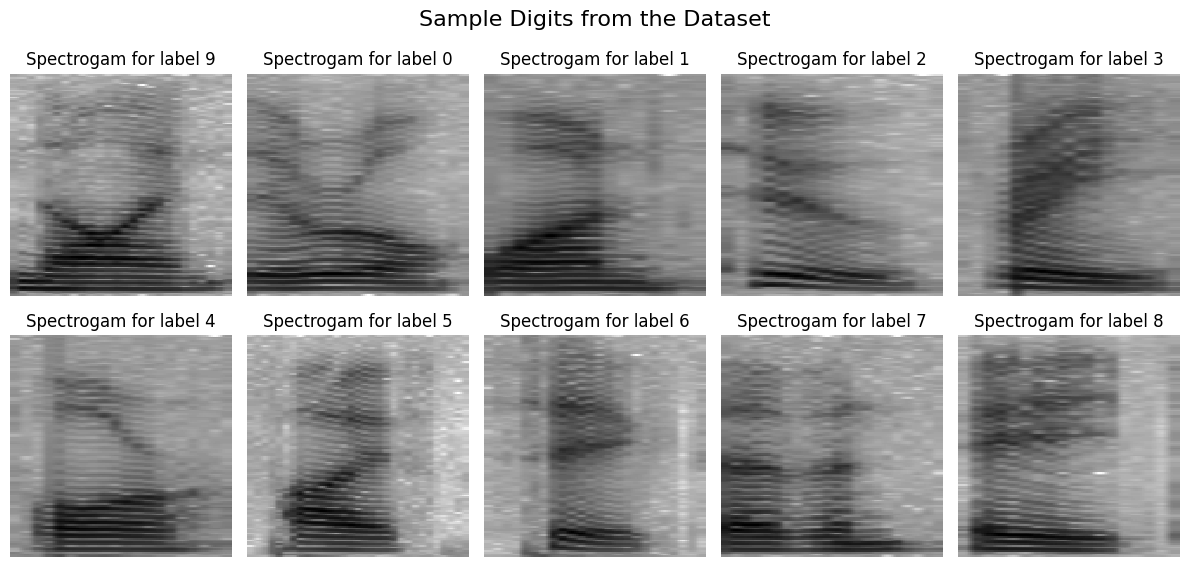

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12,6))
for i, axe in enumerate(axes.flat):
    idx = 300*i - 1
    axe.imshow(X[idx].reshape(128,128), cmap = 'gray_r', interpolation = 'nearest')
    axe.set_title(f'Spectrogam for label {y[idx][0]}')
    axe.axis('off')

plt.suptitle('Sample Digits from the Dataset', fontsize=16)
plt.tight_layout()
plt.show()



Sample feature vector shape: (16384,)
Sample target: [0]


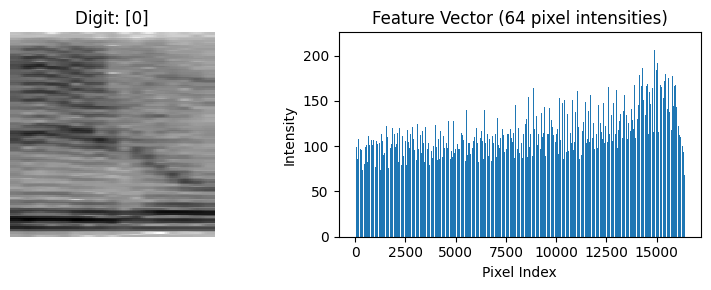

In [ ]:
print(f"Sample feature vector shape: {X[50].shape}")
print(f"Sample target: {y[50]}")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(X[0].reshape(128,128), cmap='gray_r', interpolation='nearest')
plt.title(f'Digit: {y[50]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(range(len(X[50])), X[50])
plt.title('Feature Vector (64 pixel intensities)')
plt.xlabel('Pixel Index')
plt.ylabel('Intensity')
plt.tight_layout()
plt.show()

### Build models

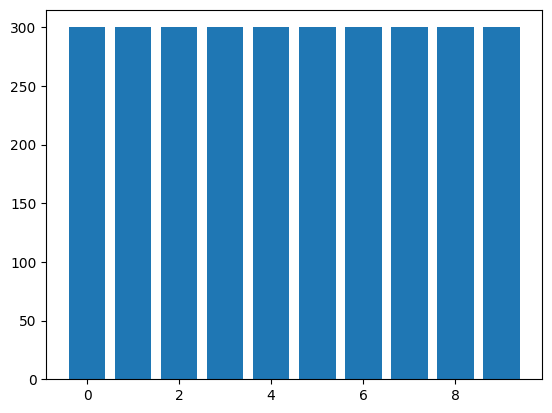

In [ ]:
plt.bar(np.unique_counts(y)[0], np.unique_counts(y)[1])
plt.show()

In [ ]:
X_scaled = X/255.0
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=42, test_size=0.2)

In [ ]:
models = [
    ('SVC', SVC(random_state=42)),
    ('LogisticRegression', LogisticRegression(random_state=42, max_iter=1000)),
    ('GaussianNB', GaussianNB()),
    ('KNeighborsClassifier', KNeighborsClassifier()),
    ('RandomForestClassifier', RandomForestClassifier(random_state=42)),
    ('DecisionTreeClassifier', DecisionTreeClassifier(random_state=42))
]

print(f"Models to compare: {[name for name, _ in models]}")

Models to compare: ['SVC', 'LogisticRegression', 'GaussianNB', 'KNeighborsClassifier', 'RandomForestClassifier', 'DecisionTreeClassifier']


In [ ]:
results = []
for name, model in models:
    print(f"\n Evaluating {name}")

    start = time.time()

    accuracy = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    end = time.time()

    results.append({
        "model": name,
        "accuracy_mean": accuracy.mean(),
        "acurracy_std": accuracy.std(),
        "training_time": end - start
    })


    print(f"   accuracy Score: {accuracy.mean():.4f} (±{accuracy.std():.4f})")
    print(f"   Training Time: {end - start:.2f} seconds")


 Evaluating SVC
   accuracy Score: 0.9637 (±0.0078)
   Training Time: 1237.49 seconds

 Evaluating LogisticRegression
   accuracy Score: 0.9642 (±0.0150)
   Training Time: 60.07 seconds

 Evaluating GaussianNB
   accuracy Score: 0.6842 (±0.0155)
   Training Time: 5.91 seconds

 Evaluating KNeighborsClassifier
   accuracy Score: 0.9300 (±0.0109)
   Training Time: 2.33 seconds

 Evaluating RandomForestClassifier
   accuracy Score: 0.8983 (±0.0129)
   Training Time: 59.69 seconds

 Evaluating DecisionTreeClassifier
   accuracy Score: 0.6021 (±0.0293)
   Training Time: 92.72 seconds


In [ ]:
results_df = pd.DataFrame(results)
print("\n Model Comparison Results:")

print(results_df.sort_values(by='accuracy_mean', ascending=False))


 Model Comparison Results:
                    model  accuracy_mean  acurracy_std  training_time
1      LogisticRegression       0.964167      0.015046      60.067328
0                     SVC       0.963750      0.007750    1237.486923
3    KNeighborsClassifier       0.930000      0.010913       2.332107
4  RandomForestClassifier       0.898333      0.012937      59.691924
2              GaussianNB       0.684167      0.015512       5.912546
5  DecisionTreeClassifier       0.602083      0.029256      92.719002



Visualizing model comparison


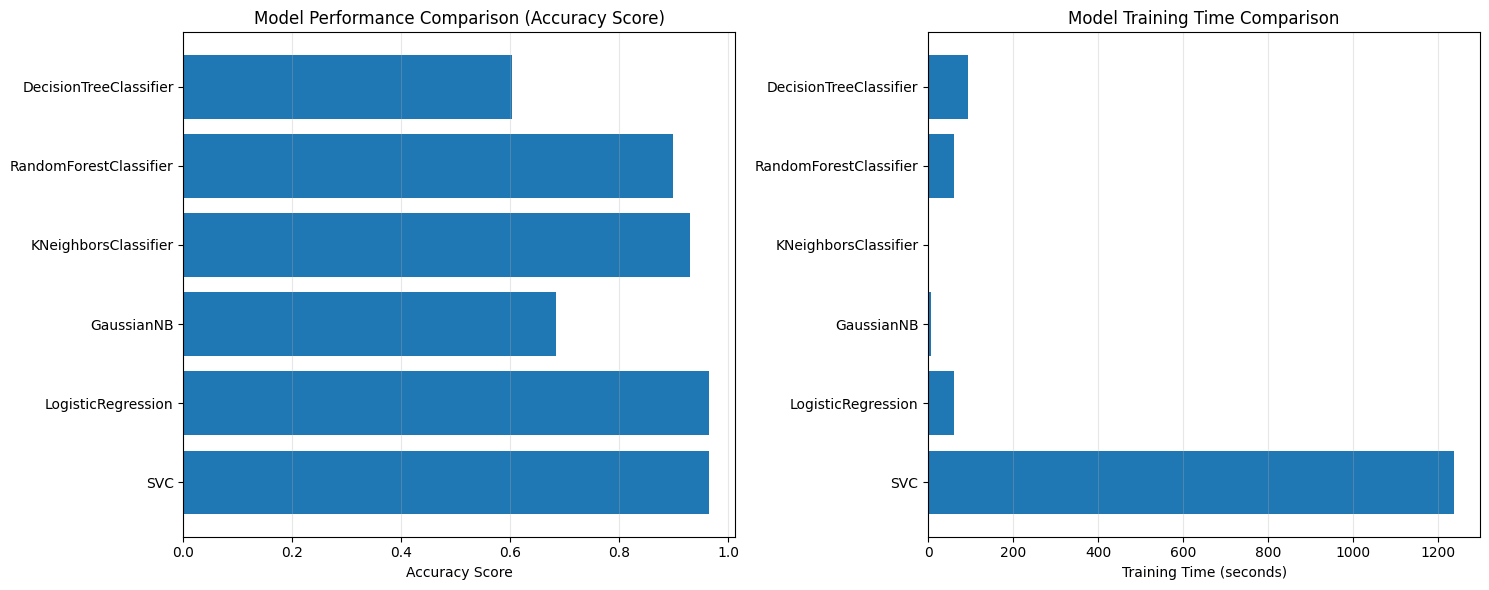

In [ ]:
print("\nVisualizing model comparison")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.barh(results_df["model"], results_df["accuracy_mean"])
ax1.set_xlabel("Accuracy Score")
ax1.set_title("Model Performance Comparison (Accuracy Score)")
ax1.grid(axis="x", alpha=0.3)


ax2.barh(results_df["model"], results_df["training_time"])
ax2.set_xlabel("Training Time (seconds)")
ax2.set_title("Model Training Time Comparison")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Chọn logisticregression vì có accuracy tốt, và cũng như các thông số khác trong confusion matrix vì class không bị mất cân bằng mà accuracy ổn 

In [ ]:
model_chosen = LogisticRegression()
model_chosen.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
print(f"Intercept (bias): {model_chosen.intercept_[0]:.4f}")
print(f"Coefficients (weights): {model_chosen.coef_[0]}")

y_train_pred = model_chosen.predict(X_train)
y_test_pred = model_chosen.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Intercept (bias): -0.0289
Coefficients (weights): [0.02278641 0.02293092 0.02289845 ... 0.02480475 0.02241943 0.02204314]
Training accuracy: 0.9933
Test accuracy: 0.9650
Precision: 0.9659
Recall: 0.9650
F1 Score: 0.9651


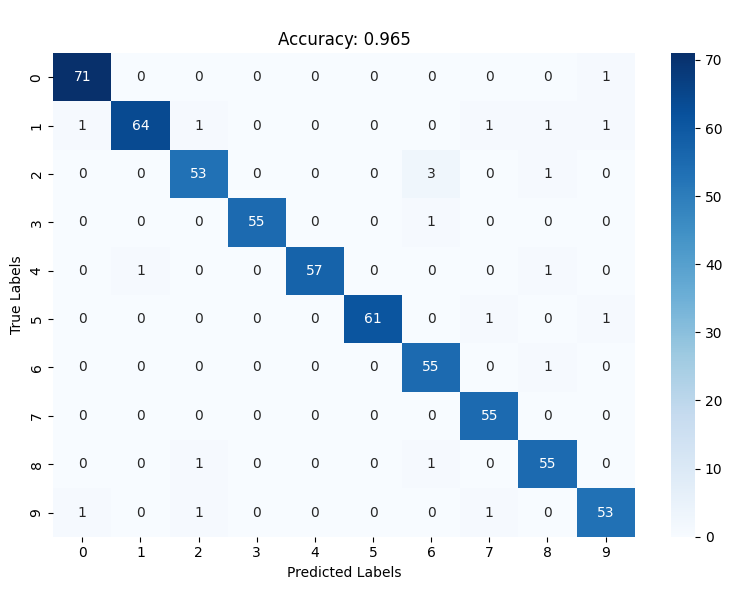

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
accuracy = np.trace(cm) / np.sum(cm)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(f"\nAccuracy: {accuracy:.3f}")
plt.ylabel("True Labels")
plt.xlabel("Predicted Labels")
plt.tight_layout()
plt.show()

### Using PCA 

In [ ]:
list_components = [5, 10, 15, 20, 25, 30, 35, 40]

model_compareds = [
    ('LogisticRegression', LogisticRegression()),
    ('SVC', SVC())
]

save_results = []

for n_component in list_components:

    pca = PCA(n_components = n_component)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    print(f"\nComponents : {pca.n_components_}")
    print(f"Explained variance : {pca.explained_variance_}")
    print(f"Total variance retained : {np.sum(pca.explained_variance_ratio_) : .4f}\n")

    for name, model in model_compareds:
        print(50*"=")
        print(f"evaluating cv accuracy mean on model {name}")

        start = time.time()
        accuracy = cross_val_score(model, X_train_pca, y_train, scoring='accuracy', cv=5)
        end = time.time()

        print(f'training time : {end - start}')
        print(f"accuracy_mean on five folds : {accuracy}")

        save_results.append({
        "model": f"{name}_{n_component}",
        "accuracy_mean": accuracy.mean(),
        "acurracy_std": accuracy.std(),
        "training_time": end - start
        })








Components : 5
Explained variance : [21.54955735 14.11522288 10.01008083  6.65476461  3.96542611]
Total variance retained :  0.5210

evaluating cv accuracy mean on model LogisticRegression
training time : 0.3062167167663574
accuracy_mean on five folds : [0.44166667 0.475      0.43958333 0.45208333 0.46666667]
evaluating cv accuracy mean on model SVC
training time : 0.46894264221191406
accuracy_mean on five folds : [0.66875    0.6625     0.60416667 0.62291667 0.66666667]

Components : 10
Explained variance : [21.54955735 14.11522288 10.01008083  6.65476461  3.96542611  3.37249406
  2.94591363  2.51021542  2.35081197  1.87945214]
Total variance retained :  0.6419

evaluating cv accuracy mean on model LogisticRegression
training time : 0.3073606491088867
accuracy_mean on five folds : [0.80625    0.82916667 0.79375    0.77708333 0.81666667]
evaluating cv accuracy mean on model SVC
training time : 0.35164761543273926
accuracy_mean on five folds : [0.9        0.91458333 0.89791667 0.8791666

In [ ]:
save_results_df = pd.DataFrame(save_results)
save_results_df

,model,accuracy_mean,acurracy_std,training_time
0,LogisticRegression_5,0.455000,0.013857,0.259387
1,SVC_5,0.645000,0.026438,0.469535
2,LogisticRegression_10,0.805417,0.018662,0.427331
3,SVC_10,0.897500,0.011289,0.371699
4,LogisticRegression_15,0.867917,0.014767,0.394176
5,SVC_15,0.935417,0.008539,0.394513
6,LogisticRegression_20,0.909583,0.007289,0.409650
7,SVC_20,0.950833,0.010913,0.447790
8,LogisticRegression_25,0.930417,0.010590,0.664417
9,SVC_25,0.952917,0.010086,0.522203



Visualizing model comparison


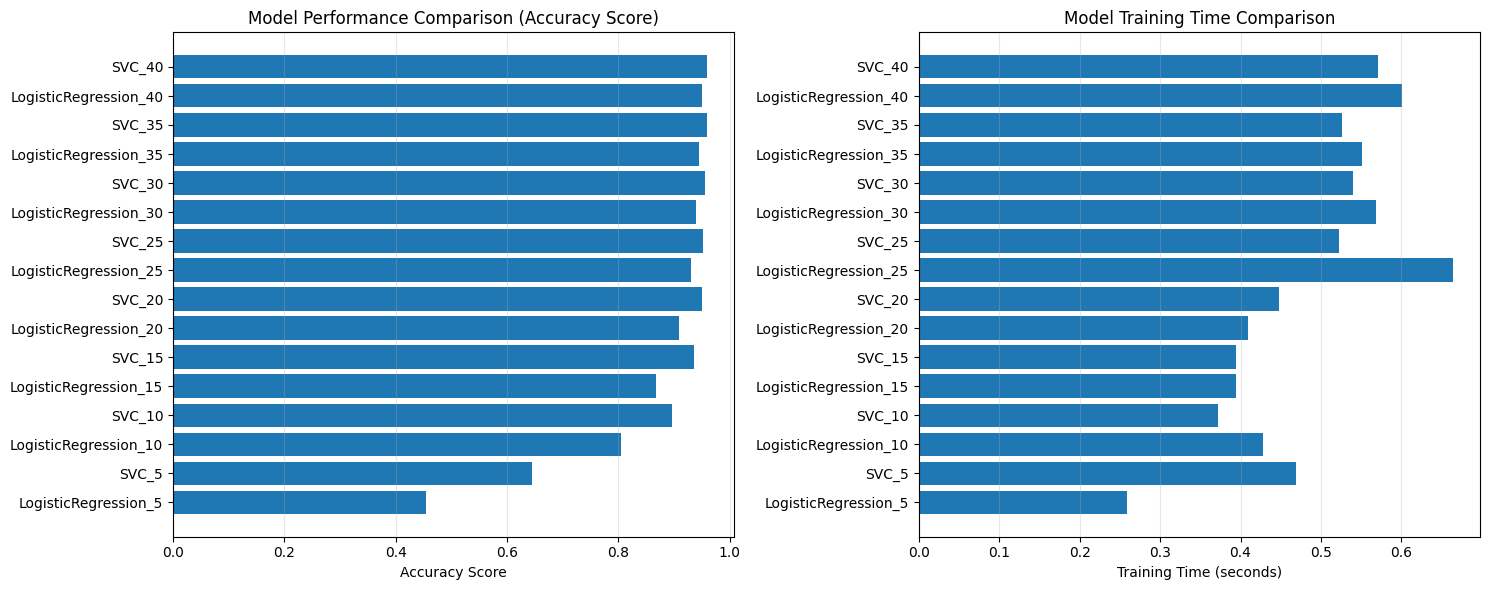

In [ ]:
print("\nVisualizing model comparison")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.barh(save_results_df["model"], save_results_df["accuracy_mean"])
ax1.set_xlabel("Accuracy Score")
ax1.set_title("Model Performance Comparison (Accuracy Score)")
ax1.grid(axis="x", alpha=0.3)


ax2.barh(save_results_df["model"], save_results_df["training_time"])
ax2.set_xlabel("Training Time (seconds)")
ax2.set_title("Model Training Time Comparison")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Training time của SVC tăng đáng kể, n_components = 35 

Use SVC without PCA

In [ ]:
print(f'data shape before PCA : {X_train.shape}')

SVC_1 = SVC()
start = time.time()
SVC_1.fit(X_train, y_train)
end = time.time()

y_pred_test_1 = SVC_1.predict(X_test)
accu = accuracy_score(y_test, y_pred_test_1)

print(f'training time : {end - start}')
print(f'accuracy : {accu}')

data shape before PCA : (2400, 16384)
training time : 203.84422612190247
accuracy : 0.9716666666666667


Use SVC with PCA

In [ ]:
pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f'data shape after PCA : {X_train_pca.shape}')

SVC_2 = SVC()
start = time.time()
SVC_2.fit(X_train_pca, y_train)
end = time.time()

y_pred_test_2 = SVC_2.predict(X_test_pca)
accu = accuracy_score(y_test, y_pred_test_2)

print(f'training time : {end - start}')
print(f'accuracy : {accu}')

data shape after PCA : (2400, 30)
training time : 0.08283567428588867
accuracy : 0.9633333333333334


In [ ]:
print(classification_report(y_test, y_pred_test_2))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        72
           1       0.98      0.93      0.96        69
           2       0.98      0.93      0.95        57
           3       0.98      0.98      0.98        56
           4       0.93      0.97      0.95        59
           5       0.95      0.92      0.94        63
           6       0.96      0.98      0.97        56
           7       0.90      0.98      0.94        55
           8       0.97      1.00      0.98        57
           9       0.96      0.98      0.97        56

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



### Sample testing 

In [ ]:
DATA_DIR = 'Data\\recordings\\recordings\\audio-images'
img_paths = []

def testing(dirs):

    img_paths = []

    for class_dir in os.listdir(DATA_DIR):
        img_paths.extend(glob.glob(os.path.join(DATA_DIR, class_dir, '*.png')))

    sample_indexs = [img_paths[300*i - 1] for i in range(10)]

    print(sample_indexs)

    for i in range (10):
        name = sample_indexs[i].split('\\')[-1].split('.')[0]
        print(f"\nTesting with audio {name}")
        x = np.array(cv2.imread(sample_indexs[i], cv2.IMREAD_GRAYSCALE).flatten()).reshape(1 , -1)
        x_pca = pca.transform(x/255.0)
        y = SVC_2.predict(x_pca)
        print(" Prediction audio from SVC_2 :", y[0])


testing(DATA_DIR)



['Data\\recordings\\recordings\\audio-images\\class_9\\9_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_0\\0_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_1\\1_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_2\\2_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_3\\3_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_4\\4_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_5\\5_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_6\\6_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_7\\7_yweweler_9.png', 'Data\\recordings\\recordings\\audio-images\\class_8\\8_yweweler_9.png']

Testing with audio 9_yweweler_9
 Prediction audio from SVC_2 : 9

Testing with audio 0_yweweler_9
 Prediction audio from SVC_2 : 0

Testing with audio 1_yweweler_9
 Prediction audio from SVC_2 : 1

Testing with audio 2_yweweler_9
 Prediction audio from SVC_2 : 2

Test

In [ ]:
print(f"Sample feature vector shape: {X[50].shape}")
print(f"Sample target: {y[50]}")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(X[0].reshape(128,128), cmap='gray_r', interpolation='nearest')
plt.title(f'Digit: {y[50]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(range(len(X[50])), X[50])
plt.title('Feature Vector (64 pixel intensities)')
plt.xlabel('Pixel Index')
plt.ylabel('Intensity')
plt.tight_layout()
plt.show()

## 5. Time Series Analysis

**Cho dữ liệu MER_T12_06.csv** về phát thải khí CO2 của nhiều nguồn khác nhau, tham khảo tại: https://www.kaggle.com/code/berhag/co2-emission-forecast-with-python-seasonal-arima/data


![Time Series Visualization](time_series_plot.png)

In [ ]:
# Câu 5: Time Series Analysis - Dự báo phát thải CO2

# TODO: Thực hiện các bước sau:
# 1. Đọc dữ liệu
# 2. Tiền xử lý dữ liệu time series
# 3. Thực hiện decomposition
# 4. Chia dữ liệu train/test (test = 3 năm cuối)
# 5. Kiểm tra tính dừng của chuỗi
# 6. Chọn và áp dụng thuật toán time series phù hợp
# 7. Dự báo 36 tháng tiếp theo
# 8. Đánh giá kết quả và trực quan hóa

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from pmdarima import auto_arima

from time import time

register_matplotlib_converters()

import warnings

warnings.filterwarnings("ignore")

### Read and overview

Có những tháng không hợp lệ, không nằm trong 12 tháng

In [3]:
data_CO2 = pd.read_csv('Data/MER_T12_06.csv')
data_CO2['YYYYMM'] = pd.to_datetime(data_CO2['YYYYMM'].astype(str), format='%Y%m', errors='coerce')
data_CO2.Value = pd.to_numeric(data_CO2.Value, errors='coerce')
data_CO2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5094 entries, 0 to 5093
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   MSN           5094 non-null   object        
 1   YYYYMM        4707 non-null   datetime64[ns]
 2   Value         4678 non-null   float64       
 3   Column_Order  5094 non-null   int64         
 4   Description   5094 non-null   object        
 5   Unit          5094 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 238.9+ KB


In [5]:
data_CO2.Description.value_counts()

Description
Coal Electric Power Sector CO2 Emissions                                                      566
Natural Gas Electric Power Sector CO2 Emissions                                               566
Distillate Fuel, Including Kerosene-Type Jet Fuel, Oil Electric Power Sector CO2 Emissions    566
Petroleum Coke Electric Power Sector CO2 Emissions                                            566
Residual Fuel Oil Electric Power Sector CO2 Emissions                                         566
Petroleum Electric Power Sector CO2 Emissions                                                 566
Geothermal Energy Electric Power Sector CO2 Emissions                                         566
Non-Biomass Waste Electric Power Sector CO2 Emissions                                         566
Total Energy Electric Power Sector CO2 Emissions                                              566
Name: count, dtype: int64

In [40]:
data_CO2.dropna(inplace=True)

In [41]:
data_CO2.duplicated().any()

False

In [42]:
data_CO2 = data_CO2.groupby('YYYYMM', as_index=False)['Value'].sum()

In [44]:
data_CO2.index = data_CO2['YYYYMM']
data_CO2_series = data_CO2['Value']
print(f" Total records: {len(data_CO2)}")
print(f" Full date range: {data_CO2.index.min()} to {data_CO2.index.max()}")
print(f" Analysis period: {data_CO2_series.index.min()} to {data_CO2_series.index.max()}")
print(f" Total observations: {len(data_CO2_series)}")

 Total records: 523
 Full date range: 1973-01-01 00:00:00 to 2016-07-01 00:00:00
 Analysis period: 1973-01-01 00:00:00 to 2016-07-01 00:00:00
 Total observations: 523


In [45]:
print(f"Shape: {data_CO2_series.shape}")
print(f"Data type: {data_CO2_series.dtype}")
print(f"Missing values: {data_CO2_series.isnull().sum()}")


print("\n Some observations:")
print(data_CO2_series.head(5))
print("\n Some observations:")
print(data_CO2_series.tail(5))

print("\n Statistics:")
print(data_CO2_series.describe())

Shape: (523,)
Data type: float64
Missing values: 0

 Some observations:
YYYYMM
1973-01-01    250.611
1973-02-01    221.403
1973-03-01    219.258
1973-04-01    204.080
1973-05-01    214.894
Name: Value, dtype: float64

 Some observations:
YYYYMM
2016-03-01    233.648
2016-04-01    229.324
2016-05-01    260.624
2016-06-01    345.936
2016-07-01    406.057
Name: Value, dtype: float64

 Statistics:
count    523.000000
mean     324.451883
std       64.315495
min      201.863000
25%      271.478500
50%      318.490000
75%      367.944000
max      501.927000
Name: Value, dtype: float64


### Visualize time series

In [46]:
data_CO2_series

YYYYMM
1973-01-01    250.611
1973-02-01    221.403
1973-03-01    219.258
1973-04-01    204.080
1973-05-01    214.894
               ...   
2016-03-01    233.648
2016-04-01    229.324
2016-05-01    260.624
2016-06-01    345.936
2016-07-01    406.057
Name: Value, Length: 523, dtype: float64

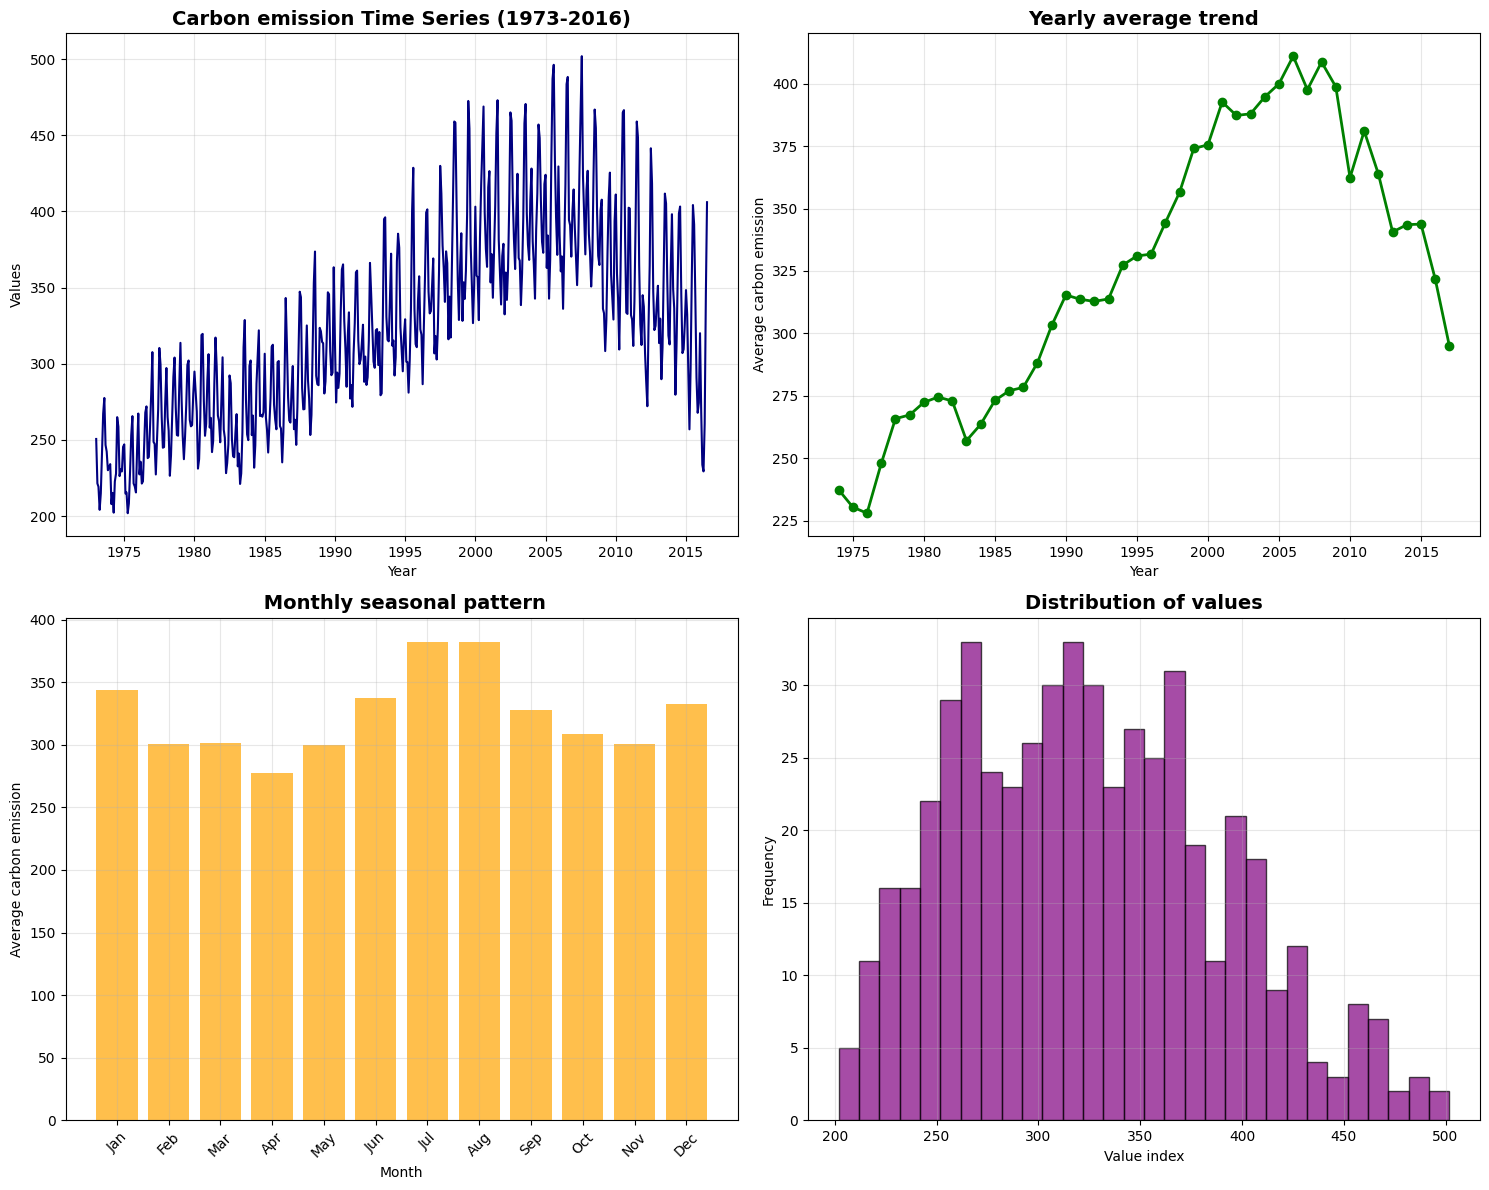

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Main time series plot
axes[0, 0].plot(data_CO2_series.index, data_CO2_series.values, linewidth=1.5, color='navy')
axes[0, 0].set_title('Carbon emission Time Series (1973-2016)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Values')
axes[0, 0].grid(True, alpha=0.3)

yearly_mean = data_CO2_series.resample('Y').mean()
axes[0, 1].plot(yearly_mean.index, yearly_mean.values, marker='o', linewidth=2, color='green')
axes[0, 1].set_title('Yearly average trend', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Average carbon emission')
axes[0, 1].grid(True, alpha=0.3)

monthly_pattern = data_CO2_series.groupby(data_CO2_series.index.month).mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].bar(range(1, 13), monthly_pattern.values, color='orange', alpha=0.7)
axes[1, 0].set_title(' Monthly seasonal pattern', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average carbon emission')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names, rotation=45)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(data_CO2_series.values, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_title('Distribution of values', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Value index')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Các giá trị đều cùng 1 đơn vị

### Decomposition Analysis

 Decomposition analysis


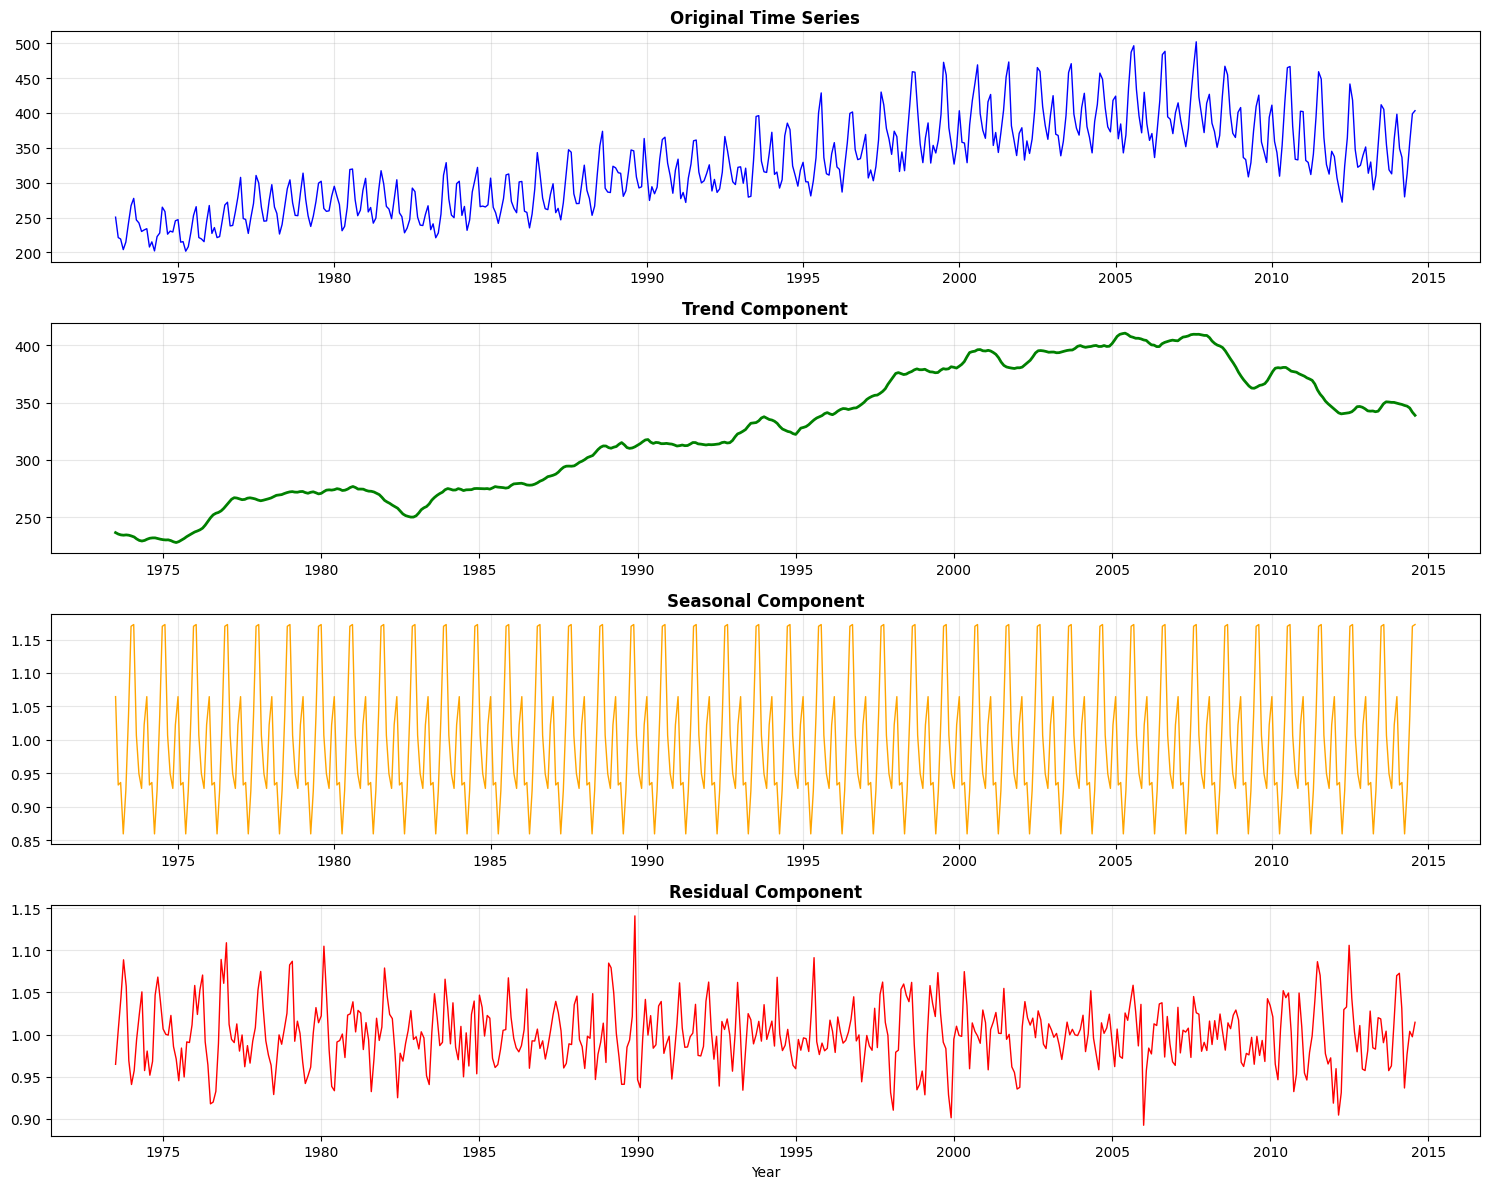

Decomposition analysis:
Trend strength: 0.8339
Seasonal strength: 0.0015
Seasonality: Weak
Trend: Strong


In [49]:
print(" Decomposition analysis")

decomposition = seasonal_decompose(data_CO2_series, model='multiplicative', period=12)

# Create visualization
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Original series
axes[0].plot(data_CO2_series.index[:500], data_CO2_series.values[:500], color='blue', linewidth=1)
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend component
axes[1].plot(decomposition.trend.index[:500], decomposition.trend.values[:500], color='green', linewidth=2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Seasonal component
axes[2].plot(decomposition.seasonal.index[:500], decomposition.seasonal.values[:500], color='orange', linewidth=1)
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Residual component
axes[3].plot(decomposition.resid.index[:500], decomposition.resid.values[:500], color='red', linewidth=1)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlabel('Year')

plt.tight_layout()
plt.show()

# Analyze the components
trend_strength = np.nanstd(decomposition.trend) / np.std(data_CO2_series)
seasonal_strength = np.std(decomposition.seasonal) / np.std(data_CO2_series)

print("Decomposition analysis:")
print(f"Trend strength: {trend_strength:.4f}")
print(f"Seasonal strength: {seasonal_strength:.4f}")
print(f"Seasonality: {'Strong' if seasonal_strength > 0.1 else 'Weak'}")
print(f"Trend: {'Strong' if trend_strength > 0.5 else 'Moderate'}")

Kiểm tra tính stationary

ADF Statistic: -6.722141
p-value: 0.000000
Critical Values:
	1%: -3.443
	5%: -2.867
	10%: -2.570
Series is stationary (reject null hypothesis)


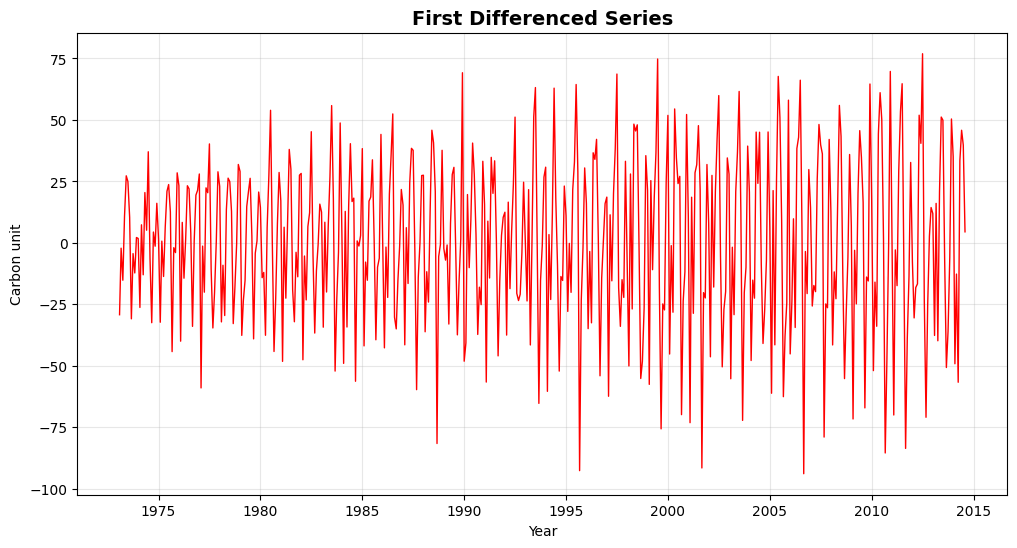

First d is stationary: True


In [50]:
data_diff = data_CO2_series.diff()
result = adfuller(data_diff.dropna())

print(f'ADF Statistic: {result[0]:.6f}')
print(f'p-value: {result[1]:.6f}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.3f}')

if result[1] <= 0.05:
    print("Series is stationary (reject null hypothesis)")
else:
    print("Series is not stationary (fail to reject null hypothesis)")
    
plt.figure(figsize=(12, 6))
plt.plot(data_diff.index[:500], data_diff.values[:500], color='red', linewidth=1)
plt.title('First Differenced Series', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Carbon unit')
plt.grid(True, alpha=0.3)
plt.show()

print(f"First d is stationary: {result[1] <= 0.05}")

### Build models

In [51]:
data_CO2_series.index[-1]

Timestamp('2016-07-01 00:00:00')

 Training period: 1973-01-01 00:00:00 to 2013-12-01 00:00:00
 Testing period: 2014-01-01 00:00:00 to 2016-07-01 00:00:00
 Train size: 492 observations
 Test size: 31 observations


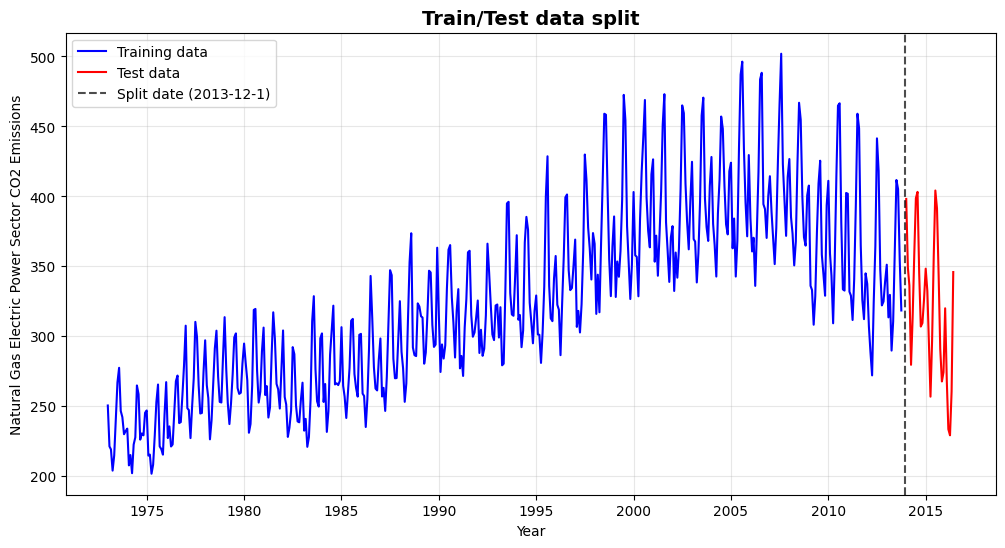

In [52]:
data_train = data_CO2_series[data_CO2_series.index <= '2013-12-1']
data_test = data_CO2_series[data_CO2_series.index > '2013-12-1']
split_date = '2013-12-1'

print(f" Training period: {data_train.index.min()} to {data_train.index.max()}")
print(f" Testing period: {data_test.index.min()} to {data_test.index.max()}")
print(f" Train size: {len(data_train)} observations")
print(f" Test size: {len(data_test)} observations")

plt.figure(figsize=(12, 6))
plt.plot(data_train.index[:490], data_train[:490].values, label='Training data', color='blue', linewidth=1.5)
plt.plot(data_test.index[:30], data_test.values[:30], label='Test data', color='red', linewidth=1.5)
plt.axvline(x=pd.to_datetime(split_date), color='black', linestyle='--', 
            label=f'Split date ({split_date})', alpha=0.7)
plt.title('Train/Test data split', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Natural Gas Electric Power Sector CO2 Emissions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
auto_model = auto_arima(
    data_train,
    start_p=0, max_p=5,      # AR terms
    start_q=0, max_q=5,      # MA terms  
    d=1,                     # Differencing (we know we need 1)
    start_P=0, max_P=2,      # Seasonal AR
    start_Q=0, max_Q=2,      # Seasonal MA
    D=1,                     # Seasonal differencing
    m=12,                    # Seasonal period (monthly data)
    seasonal=True,           # Include seasonal terms
    trace=True,              # Show the search process
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,           # Use stepwise search for efficiency
    random_state=42
)

print(f" Best Model: {auto_model}")
print(f" AIC Score: {auto_model.aic():.4f}")
print(f" Model Order: {auto_model.order}")
print(f" Seasonal Order: {auto_model.seasonal_order}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=4153.943, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=4010.332, Time=0.19 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=3857.542, Time=0.27 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=4078.074, Time=0.08 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=3859.529, Time=0.41 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=3859.525, Time=0.86 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=3973.937, Time=0.16 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=3861.304, Time=1.88 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=3908.732, Time=0.15 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=3822.831, Time=0.48 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=4046.423, Time=0.16 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=3824.740, Time=0.75 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=3824.712, Time=2.01 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=3947.158, Time=0.56 sec
 ARIMA(1,1,1)(1,1,2

In [54]:
print(auto_model.summary())
print(f' Model : Airma {auto_model.order} x Sarima {auto_model.seasonal_order}')

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  492
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1907.416
Date:                            Sun, 24 Aug 2025   AIC                           3822.831
Time:                                    20:45:12   BIC                           3839.518
Sample:                                01-01-1973   HQIC                          3829.391
                                     - 12-01-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4738      0.051      9.217      0.000       0.373       0.575
ma.L1         -0.8784      0.031   

### Evaluation

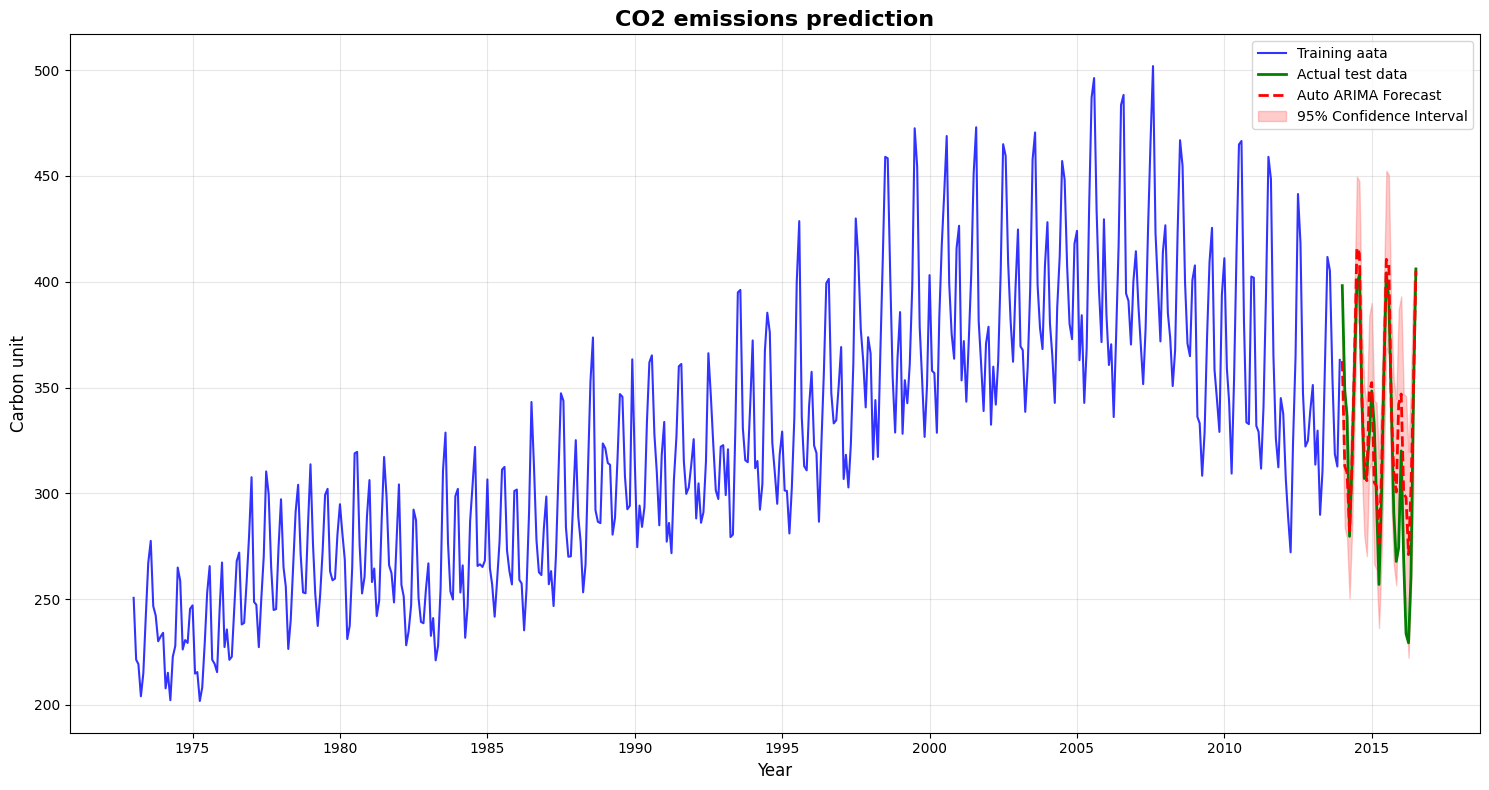

In [60]:
test_pred = auto_model.predict(n_periods = len(data_test))
test_pred_series = pd.Series(test_pred, index = data_test.index)

forecast_ci = auto_model.predict(n_periods = len(data_test), return_conf_int = True)
forecast_values = forecast_ci[0]
ci_intervals = forecast_ci[1]

plt.figure(figsize=(15, 8))

plt.plot(data_train.index, data_train.values, label='Training aata', 
         color='blue', linewidth=1.5, alpha=0.8)

plt.plot(data_test.index, data_test.values, label='Actual test data', 
         color='green', linewidth=2)

plt.plot(data_test.index, test_pred, label='Auto ARIMA Forecast', 
         color='red', linewidth=2, linestyle='--')

plt.fill_between(data_test.index[:30], 
                ci_intervals[:, 0][:30], 
                ci_intervals[:, 1][:30], 
                color='red', alpha=0.2, label='95% Confidence Interval')

plt.title('CO2 emissions prediction', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Carbon unit', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [57]:
mae = mean_absolute_error(data_test, test_pred)
mape = mean_absolute_percentage_error(data_test, test_pred)
rmse = root_mean_squared_error(data_test, test_pred)
r2 = r2_score(data_test, test_pred)


print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 19.0667
Root Mean Square Error (RMSE): 26.1854
Mean Absolute Percentage Error (MAPE): 0.07%
R-squared (R²): 0.7332


### Predicting next 36 months

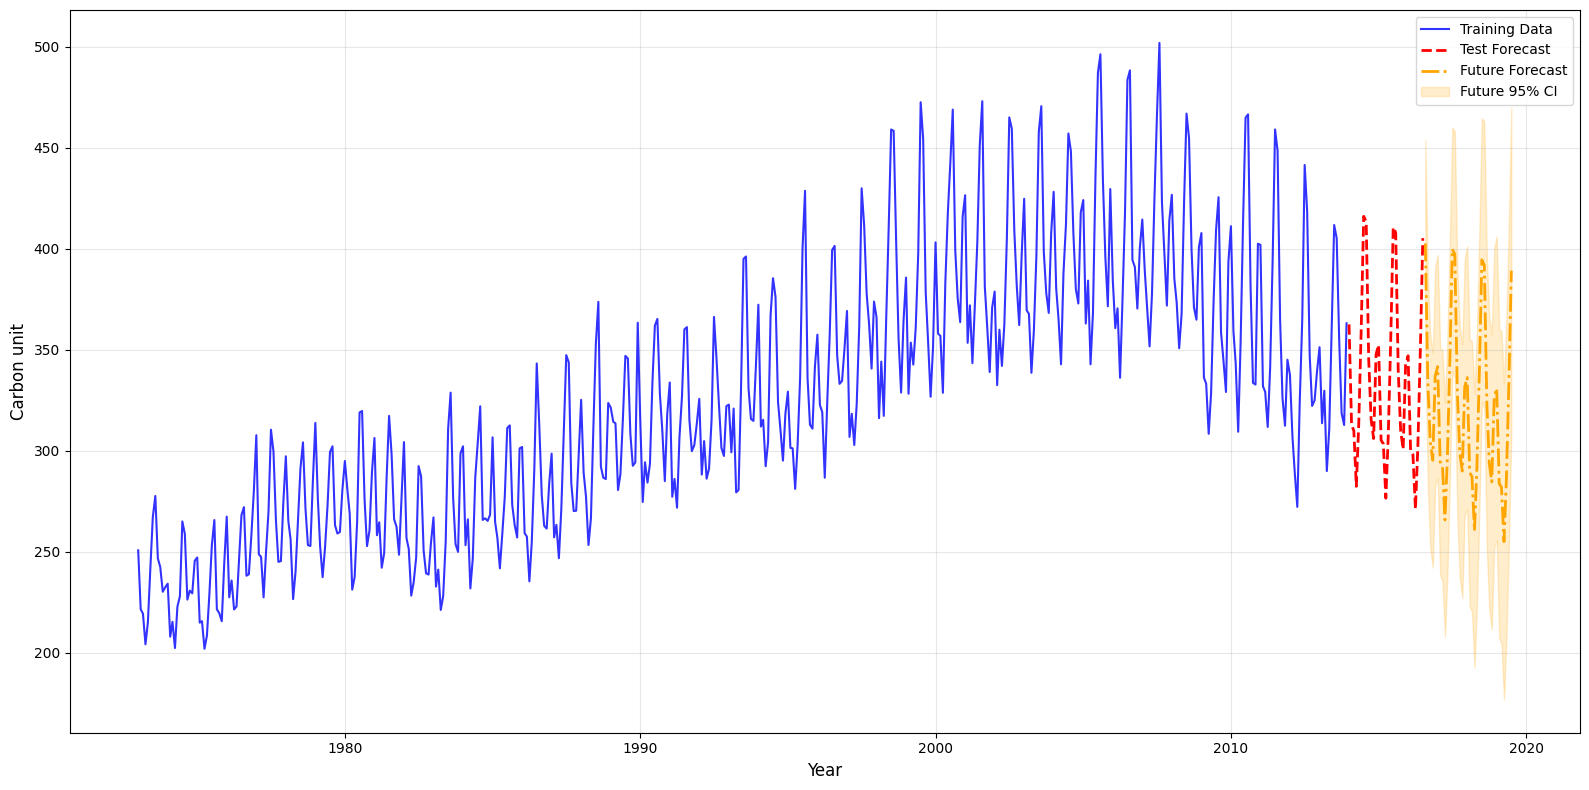

2016-08:(CI: 351.23 - 453.92)
2016-09:(CI: 282.36 - 386.30)
2016-10:(CI: 251.93 - 357.09)
2016-11:(CI: 242.04 - 348.42)
2016-12:(CI: 283.06 - 390.64)
2017-01:(CI: 286.28 - 396.87)
2017-02:(CI: 238.07 - 350.77)
2017-03:(CI: 235.39 - 349.84)
2017-04:(CI: 207.64 - 323.67)
2017-05:(CI: 238.13 - 355.64)
2017-06:(CI: 285.74 - 404.68)
2017-07:(CI: 339.66 - 460.00)
2017-08:(CI: 336.33 - 458.06)
2017-09:(CI: 267.41 - 390.50)
2017-10:(CI: 236.91 - 361.35)
2017-11:(CI: 226.97 - 352.73)
2017-12:(CI: 267.93 - 395.01)
2018-01:(CI: 271.15 - 401.25)
2018-02:(CI: 222.90 - 355.19)
2018-03:(CI: 220.17 - 354.30)
2018-04:(CI: 192.38 - 328.18)
2018-05:(CI: 222.81 - 360.20)
2018-06:(CI: 270.36 - 409.29)
2018-07:(CI: 324.23 - 464.67)
2018-08:(CI: 320.85 - 462.78)
2018-09:(CI: 251.87 - 395.27)
2018-10:(CI: 221.33 - 366.18)
2018-11:(CI: 211.32 - 357.62)
2018-12:(CI: 252.23 - 399.95)
2019-01:(CI: 255.45 - 406.19)
2019-02:(CI: 207.16 - 360.17)
2019-03:(CI: 204.39 - 359.32)
2019-04:(CI: 176.55 - 333.25)
2019-05:(C

In [63]:
test_future_pred = auto_model.predict(n_periods = len(data_test) + 36)
future_pred = test_future_pred[len(data_test):]
test_pred = test_future_pred[:len(data_test)]

future_pred_with_ci = auto_model.predict(n_periods = len(data_test) + 36, return_conf_int = True)
futures_ci = future_pred_with_ci[1][len(data_test):]

last_date = data_CO2_series.index[-1]
future_dates = pd.date_range(start = last_date + pd.DateOffset(months=1),
                              periods=36, freq='MS')


plt.figure(figsize = (16,8))

plt.plot(data_train.index, data_train.values, label='Training Data', 
         color='blue', linewidth=1.5, alpha=0.8)

plt.plot(data_test.index, test_pred, label='Test Forecast', 
         color='red', linewidth=2, linestyle='--')

# Future forecasts
plt.plot(future_dates, future_pred, label='Future Forecast', 
         color='orange', linewidth=2, linestyle='-.')

plt.fill_between(future_dates, futures_ci[:, 0], futures_ci[:, 1], color='orange', alpha=0.2, label='Future 95% CI')

plt.xlabel('Year', fontsize=12)
plt.ylabel('Carbon unit', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for i, (date, value) in enumerate(zip(future_dates, futures_ci)):
    ci_lower, ci_upper = futures_ci[i]
    print(f"{date.strftime('%Y-%m')}:"
          f"(CI: {ci_lower:.2f} - {ci_upper:.2f})")


---
## Chúc các bạn làm bài tốt ☺

**Lưu ý quan trọng:**
- Nhớ tạo thư mục `DL05_K305_HoVaTen_Cuoi_ky` trên Google Drive
- Share thư mục cho giáo viên để chấm điểm
- Gửi mail đính kèm link thư mục đúng hạn
- Mỗi câu nên làm trong file notebook riêng biệt
- Viết nhận xét chi tiết cho từng câu trong markdown cells